# Trend model (Method 1) vs. 60/40 benchmark — combined analysis

Inputs: the daily merged file [`Notebooks/output/merged_method1_vs_60_40_daily.csv`](output/merged_method1_vs_60_40_daily.csv) (aligned calendar, 2002-01-01 onward) and the upstream Method 1 backtest outputs.

Part 1 loads that file, compares normalized NAVs and daily returns, and shows a side-by-side performance table.

## Part 1 — Load merged data, NAVs, returns, performance table

In [1]:


from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

TRADING_DAYS = 252
INITIAL_AUM = 100_000_000


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data" / "stock_bond_pricing_data_uncleaned.xlsx").exists():
        return cwd
    if (cwd.parent / "data" / "stock_bond_pricing_data_uncleaned.xlsx").exists():
        return cwd.parent
    if (cwd / "Notebooks" / "output" / "merged_method1_vs_60_40_daily.csv").exists():
        return cwd
    if (cwd.parent / "Notebooks" / "output" / "merged_method1_vs_60_40_daily.csv").exists():
        return cwd.parent
    raise FileNotFoundError("Could not resolve project root.")


REPO = resolve_repo_root()
OUTPUT_DIR = REPO / "Notebooks" / "output"
MERGED_PATH = OUTPUT_DIR / "merged_method1_vs_60_40_daily.csv"

m1_path = OUTPUT_DIR / "method1_daily_backtest.csv"
bench_path = OUTPUT_DIR / "benchmark_60_40_daily_backtest.csv"
flat_path = OUTPUT_DIR / "benchmark_60_40_daily_flat.csv"

if m1_path.exists() and bench_path.exists() and flat_path.exists():
    m1_src = pd.read_csv(m1_path, header=[0, 1], index_col=0, parse_dates=True)
    bench_src = pd.read_csv(bench_path, header=[0, 1], index_col=0, parse_dates=True)
    flat_src = pd.read_csv(flat_path, index_col=0, parse_dates=True)
    rebuilt = pd.DataFrame(
        {
            "method1_strategy_return": m1_src["results"]["strategy_return"],
            "method1_nav": m1_src["results"]["nav"],
            "benchmark_strategy_return": bench_src["results"]["strategy_return"],
            "benchmark_nav": bench_src["results"]["nav"],
            "spxt_level": flat_src["spxt_level"],
            "luattruu_level": flat_src["luattruu_level"],
            "spxt_return": flat_src["spxt_return"],
            "luattruu_return": flat_src["luattruu_return"],
            "method1_gross_leverage": m1_src["results"]["gross_leverage"],
            "method1_active_signals": m1_src["results"]["active_signals"],
        }
    )
    assert rebuilt.index.equals(m1_src.index)
    rebuilt.to_csv(MERGED_PATH)
    print("Refreshed merged file:", MERGED_PATH)

if not MERGED_PATH.exists():
    raise FileNotFoundError(
        f"Missing {MERGED_PATH}. Run benchmark_60_40_backtest.ipynb and ensure "
        "method1_daily_backtest.csv exists in output/."
    )

merged = pd.read_csv(MERGED_PATH, index_col=0, parse_dates=True)
merged.index.name = "Dates"

print("Rows:", len(merged), "|", merged.index.min(), "→", merged.index.max())
display(merged.head())
display(merged.tail())

Refreshed merged file: /Users/jimmyzheng0516/Desktop/Project Labs/LTCM_sp_2026/Notebooks/output/merged_method1_vs_60_40_daily.csv
Rows: 6340 | 2002-01-01 00:00:00 → 2026-04-20 00:00:00


,method1_strategy_return,method1_nav,benchmark_strategy_return,benchmark_nav,spxt_level,luattruu_level,spxt_return,luattruu_return,method1_gross_leverage,method1_active_signals
Dates,,,,,,,,,,
2002-01-01,0.0,100000000.0,0.000000,1.000000e+08,1618.98,1161.32,0.000000,0.000000,0.0,0.0
2002-01-02,0.0,100000000.0,0.000797,1.000797e+08,1628.51,1153.38,0.005886,-0.006837,0.0,0.0
2002-01-03,0.0,100000000.0,0.006317,1.007119e+08,1643.48,1155.69,0.009192,0.002003,0.0,0.0
2002-01-04,0.0,100000000.0,0.003284,1.010426e+08,1653.69,1154.41,0.006212,-0.001108,0.0,0.0
2002-01-07,0.0,100000000.0,-0.001326,1.009087e+08,1642.95,1161.83,-0.006495,0.006428,0.0,0.0


,method1_strategy_return,method1_nav,benchmark_strategy_return,benchmark_nav,spxt_level,luattruu_level,spxt_return,luattruu_return,method1_gross_leverage,method1_active_signals
Dates,,,,,,,,,,
2026-04-14,0.001316,2.833950e+08,0.008005,5.950964e+08,15545.55,2447.11,0.011809,0.002298,0.5,2.0
2026-04-15,0.000061,2.834122e+08,0.004236,5.976175e+08,15670.77,2443.46,0.008055,-0.001492,0.5,2.0
2026-04-16,0.000876,2.836605e+08,0.000941,5.981796e+08,15711.80,2439.61,0.002618,-0.001576,0.5,2.0
2026-04-17,-0.003610,2.826366e+08,0.008774,6.034281e+08,15901.03,2449.05,0.012044,0.003869,0.5,2.0
2026-04-20,0.002877,2.834498e+08,-0.001506,6.025195e+08,15863.68,2448.46,-0.002349,-0.000241,0.5,2.0


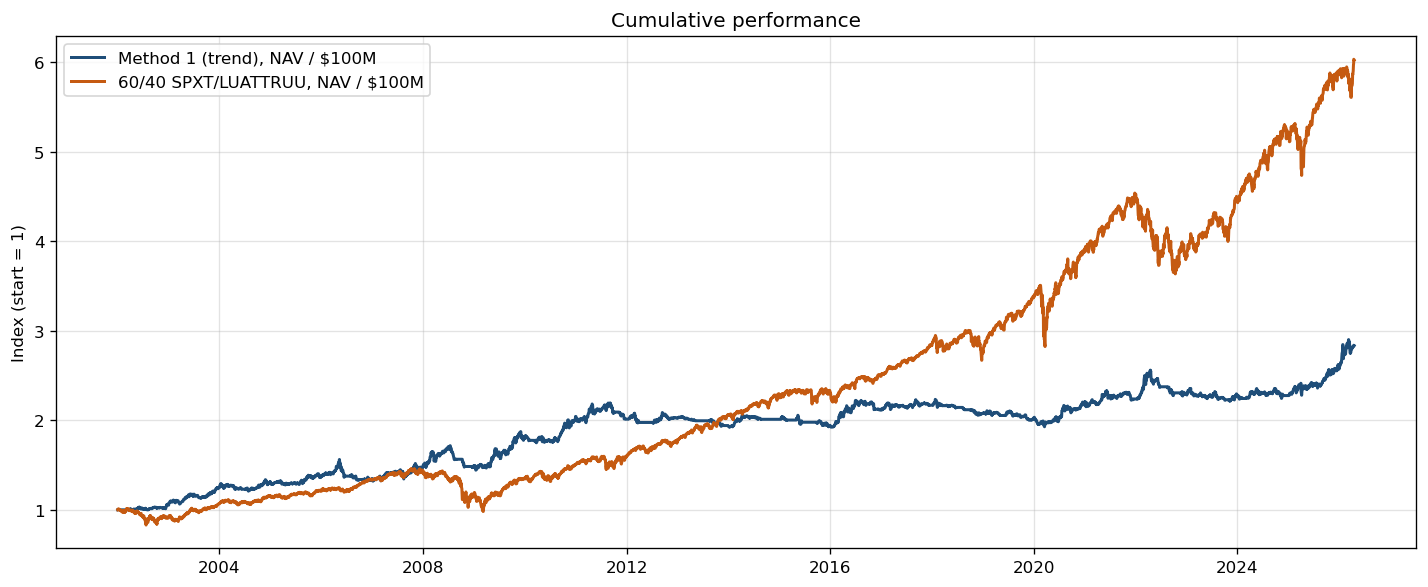

In [2]:


plt.style.use("default")
plt.rcParams.update({"figure.figsize": (12, 5), "figure.dpi": 120})

m1_nav = merged["method1_nav"]
b_nav = merged["benchmark_nav"]

m1_idx = m1_nav / INITIAL_AUM
b_idx = b_nav / INITIAL_AUM

fig, ax = plt.subplots()
ax.plot(m1_idx.index, m1_idx.values, label="Method 1 (trend), NAV / $100M", color="#1F4E79", linewidth=1.8)
ax.plot(b_idx.index, b_idx.values, label="60/40 SPXT/LUATTRUU, NAV / $100M", color="#C55A11", linewidth=1.8)
ax.set_title("Cumulative performance")
ax.set_ylabel("Index (start = 1)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

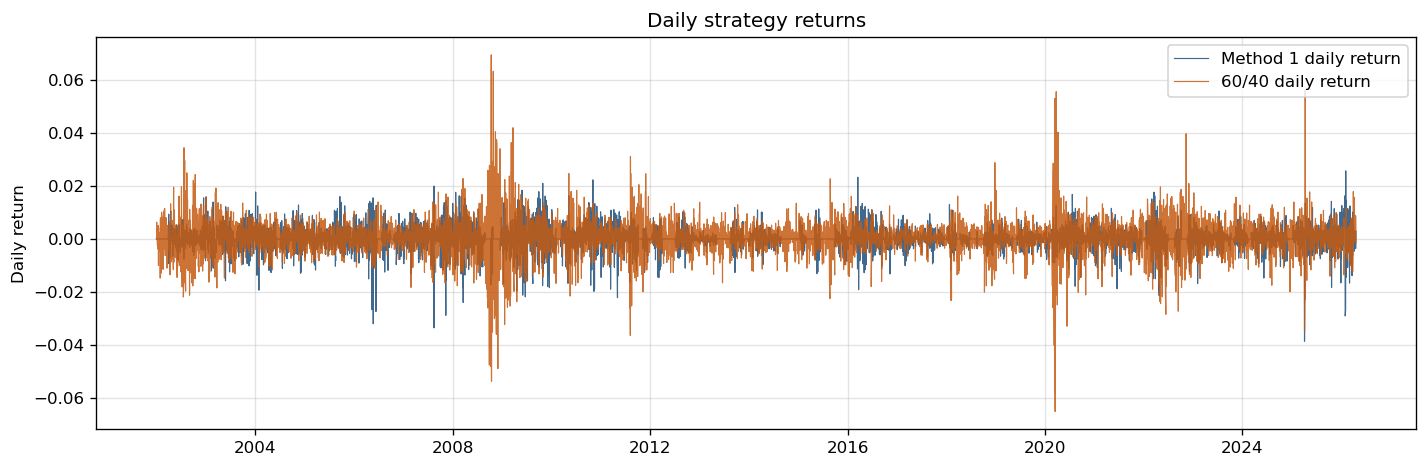

In [3]:


m1_ret = merged["method1_strategy_return"]
b_ret = merged["benchmark_strategy_return"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(m1_ret.index, m1_ret.values, label="Method 1 daily return", color="#1F4E79", linewidth=0.7, alpha=0.85)
ax.plot(b_ret.index, b_ret.values, label="60/40 daily return", color="#C55A11", linewidth=0.7, alpha=0.85)
ax.set_title("Daily strategy returns")
ax.set_ylabel("Daily return")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

In [4]:


def max_drawdown(nav_series: pd.Series):
    peak = nav_series.cummax()
    dd = nav_series / peak - 1.0
    end = dd.idxmin()
    start = nav_series.loc[:end].idxmax()
    return float(dd.min()), start, end


def annualized_return(nav_series: pd.Series) -> float:
    years = (nav_series.index[-1] - nav_series.index[0]).days / 365.25
    return float((nav_series.iloc[-1] / nav_series.iloc[0]) ** (1.0 / years) - 1.0)


def core_strategy_stats(nav: pd.Series, strat_ret: pd.Series) -> dict:
    max_dd, dd_s, dd_e = max_drawdown(nav)
    ann_r = annualized_return(nav)
    ann_vol = float(strat_ret.std() * np.sqrt(TRADING_DAYS))
    sharpe = ann_r / ann_vol if ann_vol != 0 else float("nan")
    return {
        "Ending NAV": float(nav.iloc[-1]),
        "Total return": float(nav.iloc[-1] / nav.iloc[0] - 1.0),
        "Annual rate of return": ann_r,
        "Annualized volatility": ann_vol,
        "Sharpe ratio, rf=0": float(sharpe),
        "Maximum drawdown": max_dd,
        "Maximum drawdown start": dd_s,
        "Maximum drawdown end": dd_e,
    }


s1 = core_strategy_stats(m1_nav, m1_ret)
s2 = core_strategy_stats(b_nav, b_ret)

trades_path = OUTPUT_DIR / "method1_trades.csv"
if trades_path.exists():
    trades = pd.read_csv(trades_path)
    n_trades = len(trades)
    avg_hold = float(trades["holding_days"].mean())
else:
    n_trades = float("nan")
    avg_hold = float("nan")

m1_gl = merged["method1_gross_leverage"]
m1_as = merged["method1_active_signals"]

rows: list[tuple] = [
    ("Start date", m1_nav.index[0].strftime("%Y-%m-%d"), b_nav.index[0].strftime("%Y-%m-%d")),
    ("End date", m1_nav.index[-1].strftime("%Y-%m-%d"), b_nav.index[-1].strftime("%Y-%m-%d")),
    ("Initial AUM", INITIAL_AUM, INITIAL_AUM),
    ("Ending NAV", s1["Ending NAV"], s2["Ending NAV"]),
    ("Total return", s1["Total return"], s2["Total return"]),
    ("Annual rate of return", s1["Annual rate of return"], s2["Annual rate of return"]),
    ("Annualized volatility", s1["Annualized volatility"], s2["Annualized volatility"]),
    ("Sharpe ratio, rf=0", s1["Sharpe ratio, rf=0"], s2["Sharpe ratio, rf=0"]),
    ("Maximum drawdown", s1["Maximum drawdown"], s2["Maximum drawdown"]),
    (
        "Maximum drawdown start",
        s1["Maximum drawdown start"].strftime("%Y-%m-%d"),
        s2["Maximum drawdown start"].strftime("%Y-%m-%d"),
    ),
    (
        "Maximum drawdown end",
        s1["Maximum drawdown end"].strftime("%Y-%m-%d"),
        s2["Maximum drawdown end"].strftime("%Y-%m-%d"),
    ),
    ("Total trade count", n_trades, None),
    ("Average holding period per trade", avg_hold, None),
    ("Average gross leverage", float(m1_gl.mean()), 1.0),
    ("Maximum gross leverage", float(m1_gl.max()), 1.0),
    ("Average active signals", float(m1_as.mean()), 2.0),
    ("Maximum active signals", float(m1_as.max()), 2.0),
]

summary_compare = pd.DataFrame(rows, columns=["Metric", "Method 1 (trend)", "60/40 benchmark"])

pct_metrics = {
    "Total return",
    "Annual rate of return",
    "Annualized volatility",
    "Maximum drawdown",
    "Average gross leverage",
    "Maximum gross leverage",
}
money_metrics = {"Initial AUM", "Ending NAV"}
date_metrics = {"Maximum drawdown start", "Maximum drawdown end", "Start date", "End date"}


def fmt_cell(metric: str, value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return "—"
    if metric in date_metrics:
        return str(value)
    if metric in pct_metrics:
        return f"{float(value):.2%}"
    if metric in money_metrics:
        return f"${float(value):,.0f}"
    if isinstance(value, float):
        return f"{value:.2f}"
    return str(value)


display_df = summary_compare.copy()
display_df["Method 1 (trend)"] = [
    fmt_cell(m, v) for m, v in zip(summary_compare["Metric"], summary_compare["Method 1 (trend)"])
]
display_df["60/40 benchmark"] = [
    fmt_cell(m, v) for m, v in zip(summary_compare["Metric"], summary_compare["60/40 benchmark"])
]

display(display_df)

summary_compare.to_csv(OUTPUT_DIR / "merged_method1_vs_60_40_summary_compare.csv", index=False)
print("Saved", OUTPUT_DIR / "merged_method1_vs_60_40_summary_compare.csv")

,Metric,Method 1 (trend),60/40 benchmark
0,Start date,2002-01-01,2002-01-01
1,End date,2026-04-20,2026-04-20
2,Initial AUM,"$100,000,000","$100,000,000"
3,Ending NAV,"$283,449,790","$602,519,538"
4,Total return,183.45%,502.52%
5,Annual rate of return,4.38%,7.67%
6,Annualized volatility,7.08%,10.87%
7,"Sharpe ratio, rf=0",0.62,0.71
8,Maximum drawdown,-15.93%,-32.68%
9,Maximum drawdown start,2008-07-14,2007-10-09


Saved /Users/jimmyzheng0516/Desktop/Project Labs/LTCM_sp_2026/Notebooks/output/merged_method1_vs_60_40_summary_compare.csv


month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
year,,,,,,,,,,,,,
2002,-0.6%,-0.8%,1.3%,-2.7%,-0.2%,-3.7%,-3.6%,1.4%,-5.6%,4.9%,3.2%,-2.5%,-9.1%
2003,-1.6%,-0.2%,0.5%,5.1%,4.3%,0.5%,-0.7%,1.4%,0.6%,2.7%,0.6%,3.5%,17.9%
2004,1.5%,1.3%,-0.5%,-2.2%,0.7%,1.3%,-1.6%,1.1%,0.8%,1.3%,1.9%,2.4%,8.1%
2005,-1.2%,0.9%,-1.2%,-0.4%,2.4%,0.3%,1.7%,0.1%,-0.0%,-1.3%,2.5%,0.4%,4.2%
2006,1.5%,0.2%,0.3%,0.6%,-1.7%,0.2%,0.9%,2.0%,1.9%,2.2%,1.6%,0.5%,10.7%
2007,0.8%,-0.5%,0.7%,2.9%,1.7%,-1.0%,-1.2%,1.6%,2.5%,1.3%,-1.3%,-0.3%,7.3%
2008,-2.6%,-1.5%,0.1%,2.2%,0.3%,-4.8%,-0.3%,1.4%,-4.8%,-9.9%,-1.9%,2.3%,-18.3%
2009,-6.1%,-6.6%,6.4%,5.0%,3.0%,0.1%,4.7%,2.6%,2.6%,-1.1%,4.2%,0.1%,14.7%
2010,-1.5%,2.0%,3.2%,1.4%,-4.1%,-2.4%,4.5%,-1.9%,5.3%,2.2%,-0.2%,3.2%,11.9%


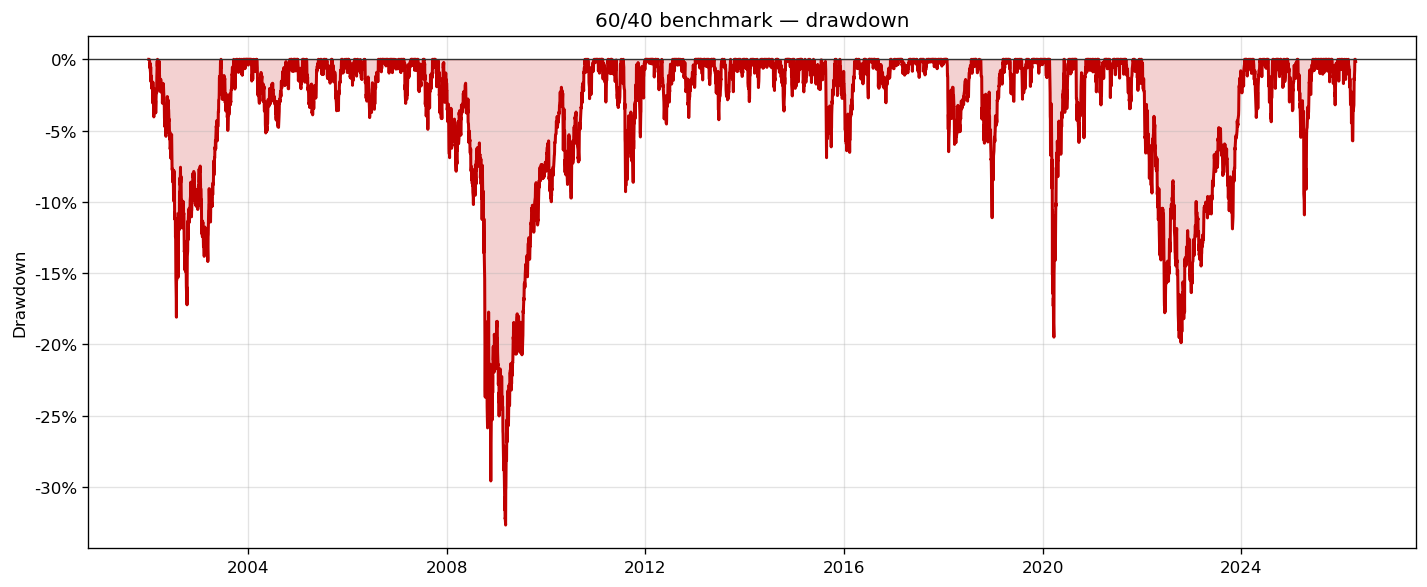

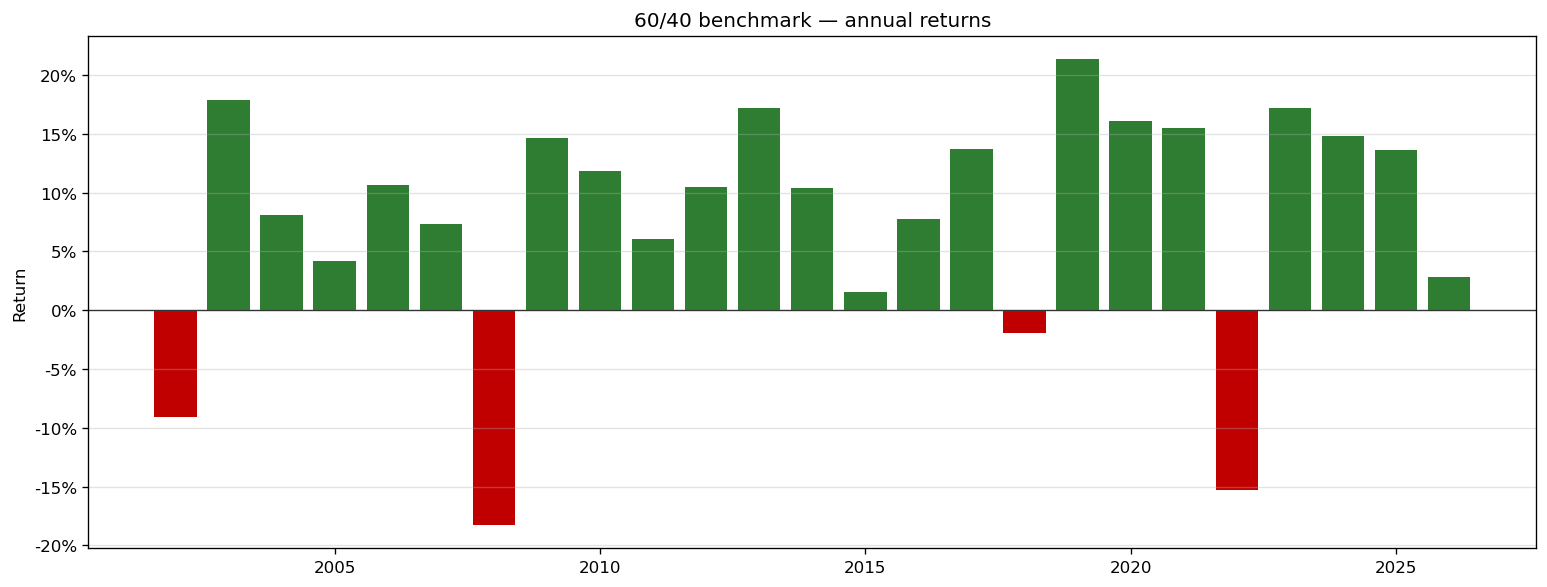

In [5]:


# 60/40 only — monthly table (styled like Method 1 backtest notebook), drawdown, annual bars
bench_ret_p1 = merged["benchmark_strategy_return"].copy()
bench_nav_p1 = merged["benchmark_nav"].copy()

MONTH_ORDER_P1 = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                  "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly_b = (1.0 + bench_ret_p1).resample("ME").prod() - 1.0
mt = monthly_b.to_frame("return")
mt["year"] = mt.index.year
mt["month"] = mt.index.strftime("%b")
pivot_b = mt.pivot(index="year", columns="month", values="return").reindex(columns=MONTH_ORDER_P1)
annual_b = (1.0 + monthly_b).groupby(monthly_b.index.year).prod() - 1.0
pivot_b["Annual"] = annual_b


def _color_returns_p1(val):
    if pd.isna(val):
        return ""
    if val > 0.06:
        return "background-color: #D9EAD3; color: #174A1A"
    if val < -0.02:
        return "background-color: #F4CCCC; color: #7F0000"
    return ""


display(pivot_b.style.format("{:.1%}", na_rep="—").map(_color_returns_p1))

# Drawdown from NAV
peak_b = bench_nav_p1.cummax()
dd_b = bench_nav_p1 / peak_b - 1.0

fig_dd, ax_dd = plt.subplots(figsize=(12, 5))
ax_dd.plot(dd_b.index, dd_b.values, color="#C00000", linewidth=1.8)
ax_dd.axhline(0, color="#333333", linewidth=0.8)
ax_dd.fill_between(dd_b.index, dd_b.values, 0, color="#C00000", alpha=0.18)
ax_dd.set_title("60/40 benchmark — drawdown")
ax_dd.set_ylabel("Drawdown")
ax_dd.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax_dd.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

fig_ab, ax_ab = plt.subplots(figsize=(13, 5))
bar_c = ["#2E7D32" if x >= 0 else "#C00000" for x in annual_b.values]
ax_ab.bar(annual_b.index, annual_b.values, color=bar_c, width=0.8)
ax_ab.axhline(0, color="#333333", linewidth=0.8)
ax_ab.set_title("60/40 benchmark — annual returns")
ax_ab.set_ylabel("Return")
ax_ab.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax_ab.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

## Part 2 — Correlation analysis

Full-sample Pearson correlation and 21d / 63d rolling correlation between Method 1 daily returns and the 60/40 benchmark on the aligned calendar from Part 1.

Full-sample Pearson correlation (daily returns): ρ = 0.1606  (n = 6340)


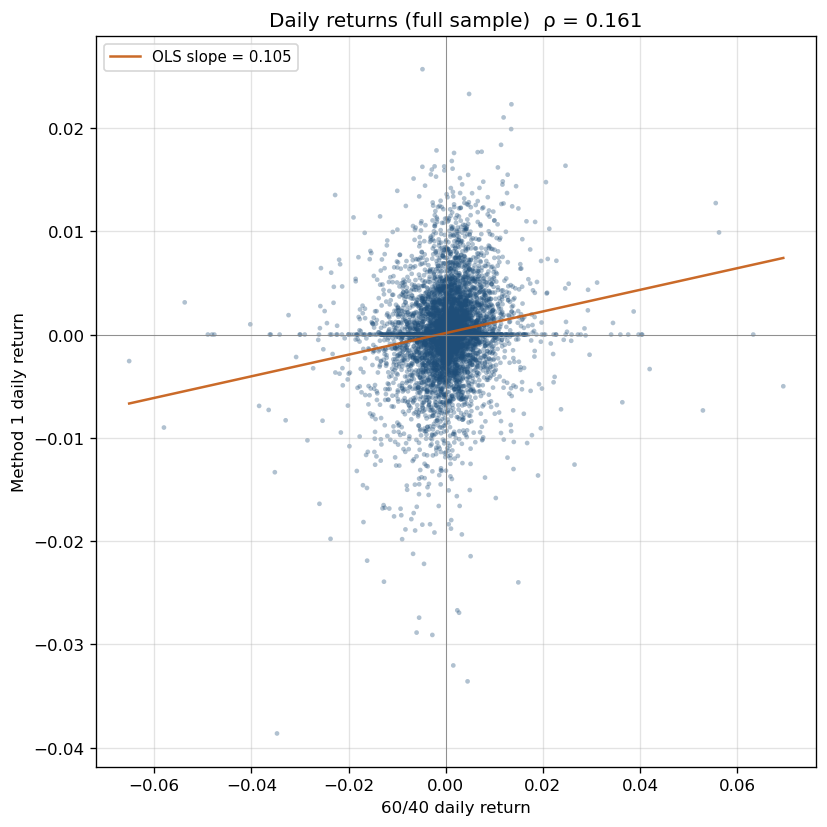

/var/folders/vf/ml0jt6z91qsdhgg6jwg8p76h0000gn/T/ipykernel_5148/3202522224.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


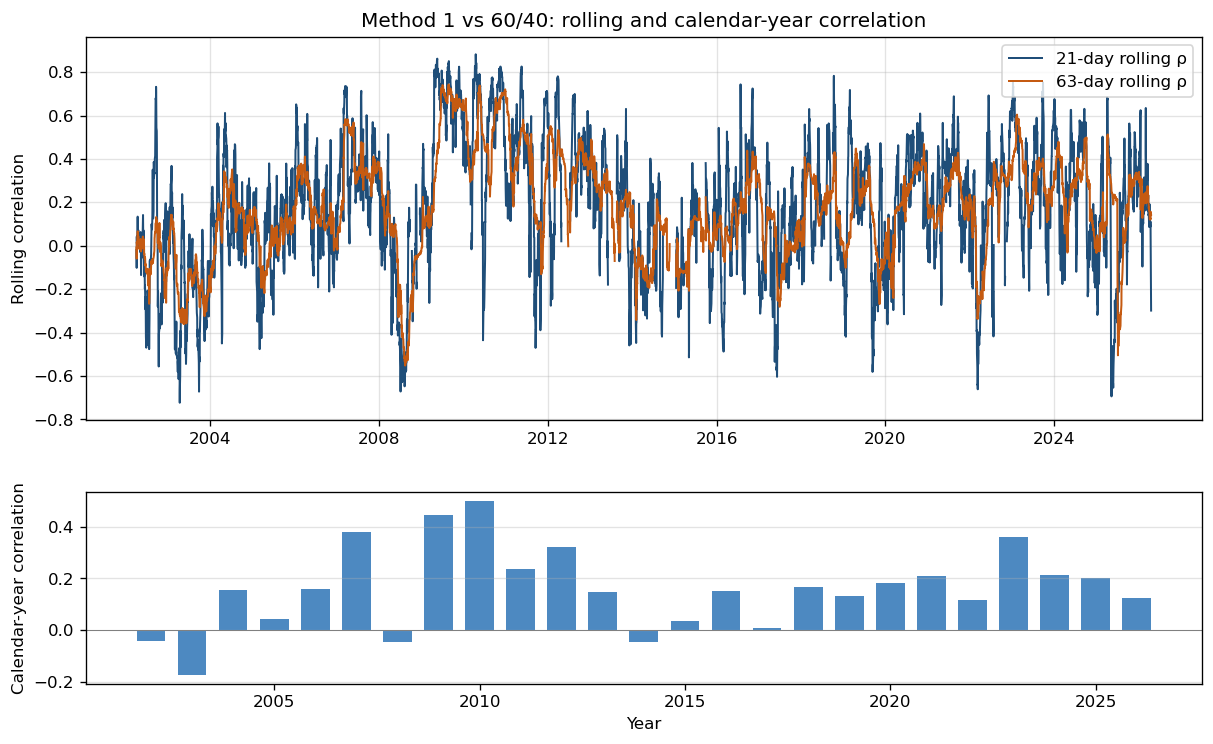

In [6]:


# Part 2 — correlation vs 60/40 (aligned daily returns; drop rows with NaN in either series)
corr_df = merged[["method1_strategy_return", "benchmark_strategy_return"]].copy()
corr_df.columns = ["method1", "bench60_40"]
corr_clean = corr_df.dropna()

m1c = corr_clean["method1"]
bc = corr_clean["bench60_40"]
n_obs = len(corr_clean)
rho_full = m1c.corr(bc)
print(f"Full-sample Pearson correlation (daily returns): ρ = {rho_full:.4f}  (n = {n_obs})")

# Scatterplot + OLS line (x = 60/40, y = Method 1)
fig_scatter, ax_s = plt.subplots(figsize=(7, 7))
ax_s.scatter(bc, m1c, s=8, alpha=0.35, color="#1F4E79", edgecolors="none")
coef = np.polyfit(bc.to_numpy(), m1c.to_numpy(), 1)
xp = np.linspace(float(bc.min()), float(bc.max()), 100)
ax_s.plot(xp, np.poly1d(coef)(xp), color="#C55A11", linewidth=1.5, alpha=0.9, label=f"OLS slope = {coef[0]:.3f}")
ax_s.set_xlabel("60/40 daily return")
ax_s.set_ylabel("Method 1 daily return")
ax_s.set_title(f"Daily returns (full sample)  ρ = {rho_full:.3f}")
ax_s.legend(loc="upper left", fontsize=9)
ax_s.grid(True, alpha=0.35)
ax_s.axhline(0, color="gray", linewidth=0.5)
ax_s.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

# Rolling correlation: ~1 month (21 trading days) and ~1 quarter (63 trading days)
ROLL_MONTH = 21  # ~1 calendar month of trading days
ROLL_QUARTER = 63  # ~3 × 21 trading days
min_p_m = max(10, ROLL_MONTH // 2)
min_p_q = max(10, ROLL_QUARTER // 2)
roll_m = m1c.rolling(ROLL_MONTH, min_periods=min_p_m).corr(bc)
roll_q = m1c.rolling(ROLL_QUARTER, min_periods=min_p_q).corr(bc)

# Calendar-year correlation (one coefficient per year, for bar chart)
annual_rho = corr_clean.groupby(corr_clean.index.year).apply(
    lambda g: g["method1"].corr(g["bench60_40"]),
)

fig_combo, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.25},
)
ax_top.plot(roll_m.index, roll_m.values, color="#1F4E79", linewidth=1.2, label=f"{ROLL_MONTH}-day rolling ρ")
ax_top.plot(roll_q.index, roll_q.values, color="#C55A11", linewidth=1.2, label=f"{ROLL_QUARTER}-day rolling ρ")
ax_top.set_ylabel("Rolling correlation")
ax_top.set_title("Method 1 vs 60/40: rolling and calendar-year correlation")
ax_top.legend(loc="upper right")
ax_top.grid(True, alpha=0.35)

years = annual_rho.index.to_numpy()
ax_bot.bar(years, annual_rho.to_numpy(), color="#2E75B6", alpha=0.85, width=0.7)
ax_bot.set_ylabel("Calendar-year correlation")
ax_bot.set_xlabel("Year")
ax_bot.grid(True, axis="y", alpha=0.35)
ax_bot.axhline(0, color="gray", linewidth=0.6)
plt.tight_layout()
plt.show()

## Part 3 — Diversification (sleeve overlay and mean-variance)

Treats Method 1 trend (`T`) and the 60/40 benchmark (`B`) as two pre-built risky portfolios and asks whether mixing them improves risk-adjusted performance over plain 60/40.

Ground rules:

- Mixes are rebalanced daily to target weights: realized day-`t` return is `w_T · r_T,t + w_B · r_B,t`.
- Risk-free rate is zero throughout (consistent with Parts 1-2 and the Method 1 backtest notebook).
- Long-only: `w_T ≥ 0`, `w_B ≥ 0`, `w_T + w_B = 1`.
- Annualization uses 252 trading days; vol = std × √252; NAV starts at $100M.
- The leading `2002-01-01` zero-return seed row is dropped so vol/Sharpe come from real trading observations.

Strategy labels used throughout: **100% 60/40**, **100% trend**, **90% 60/40 + 10% trend**, **static MV**, **dynamic MV**.

Sub-sections:

1. §3.1 — 90/10 sleeve vs the two legs.
2. §3.2 — static MV: full-sample long-only frontier and tangency.
3. §3.3 — dynamic MV: rolling long-only tangency.
4. §3.4 — all five strategies on the same calendar (summary table, NAV chart, drawdown panels, annual-return panels).

In [7]:


# Part 3 setup — shared evaluation toolkit
PART3_COLORS = {
    "TREND": "#1F4E79",
    "BENCH": "#C55A11",
    "MIX": "#548235",
    "Drawdown": "#C00000",
    "Positive": "#2E7D32",
    "Negative": "#C00000",
}

# Short labels — tables + legends (consistent everywhere in Part 3)
S_6040 = "100% 60/40"
S_TREND = "100% trend"
S_MIX = "90% 60/40 + 10% trend"
S_STATIC_MV = "static MV"
S_DYNAMIC_MV = "dynamic MV"

STRATEGY_COLORS = {
    S_6040: PART3_COLORS["BENCH"],
    S_TREND: PART3_COLORS["TREND"],
    S_MIX: PART3_COLORS["MIX"],
    S_STATIC_MV: "#7030A0",
    S_DYNAMIC_MV: "#00838F",
}
STRATEGY_ORDER = [S_6040, S_TREND, S_MIX, S_STATIC_MV, S_DYNAMIC_MV]

MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

PCT_METRICS = {"Total return", "Annual rate of return", "Annualized volatility",
               "Maximum drawdown"}
MONEY_METRICS = {"Initial AUM", "Ending NAV"}
DATE_METRICS = {"Start date", "End date", "Maximum drawdown start", "Maximum drawdown end"}


def daily_to_nav(daily_ret: pd.Series, initial_aum: float = INITIAL_AUM) -> pd.Series:
    return initial_aum * (1.0 + daily_ret.fillna(0.0)).cumprod()


def drawdown_series(nav: pd.Series) -> pd.Series:
    peak = nav.cummax()
    return nav / peak - 1.0


def build_mix(w_T: float, r_T: pd.Series, r_B: pd.Series) -> pd.Series:
    aligned = pd.concat([r_T, r_B], axis=1, join="inner").dropna()
    aligned.columns = ["T", "B"]
    return (w_T * aligned["T"] + (1.0 - w_T) * aligned["B"]).rename(f"mix_w_T_{w_T:+.4f}")


def summary_stats(name: str, daily_ret: pd.Series, w_T: float | None = None,
                  initial_aum: float = INITIAL_AUM) -> dict:
    s = daily_ret.dropna()
    nav = daily_to_nav(s, initial_aum)
    dd = drawdown_series(nav)
    dd_min = float(dd.min())
    dd_end = dd.idxmin()
    dd_start = nav.loc[:dd_end].idxmax()
    ann_r = float(annualized_return(nav))
    ann_v = float(s.std() * np.sqrt(TRADING_DAYS))
    sharpe = ann_r / ann_v if ann_v > 0 else float("nan")
    out = {
        "Strategy": name,
        "Start date": nav.index[0].strftime("%Y-%m-%d"),
        "End date": nav.index[-1].strftime("%Y-%m-%d"),
        "Initial AUM": float(initial_aum),
        "Ending NAV": float(nav.iloc[-1]),
        "Total return": float(nav.iloc[-1] / nav.iloc[0] - 1.0),
        "Annual rate of return": ann_r,
        "Annualized volatility": ann_v,
        "Sharpe ratio, rf=0": float(sharpe),
        "Maximum drawdown": dd_min,
        "Maximum drawdown start": dd_start.strftime("%Y-%m-%d"),
        "Maximum drawdown end": dd_end.strftime("%Y-%m-%d"),
    }
    if w_T is not None:
        out["Weights (w_T / w_B)"] = f"{w_T:.0%} / {1.0 - w_T:.0%}"
    return out


def fmt_metric(metric, value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return "—"
    if metric in DATE_METRICS:
        return str(value)
    if metric in PCT_METRICS:
        return f"{float(value):.2%}"
    if metric in MONEY_METRICS:
        return f"${float(value):,.0f}"
    if isinstance(value, float):
        return f"{value:.2f}"
    return str(value)


def summary_table(stats_dicts) -> pd.DataFrame:
    if isinstance(stats_dicts, dict):
        stats_dicts = [stats_dicts]
    metric_order = [
        "Start date", "End date", "Initial AUM", "Ending NAV",
        "Total return", "Annual rate of return", "Annualized volatility",
        "Sharpe ratio, rf=0", "Maximum drawdown",
        "Maximum drawdown start", "Maximum drawdown end",
    ]
    if any("Weights (w_T / w_B)" in d for d in stats_dicts):
        metric_order.append("Weights (w_T / w_B)")
    out = {"Metric": metric_order}
    for d in stats_dicts:
        col = d.get("Strategy", "Strategy")
        out[col] = [fmt_metric(m, d.get(m)) for m in metric_order]
    return pd.DataFrame(out)


def plot_nav(daily_ret_dict: dict, title: str, initial_aum: float = INITIAL_AUM,
             colors: dict | None = None):
    fig, ax = plt.subplots(figsize=(12, 6))
    for label, ret in daily_ret_dict.items():
        nav = daily_to_nav(ret.dropna(), initial_aum)
        c = (colors or {}).get(label)
        ax.plot(nav.index, (nav / initial_aum).values, label=label, linewidth=2.0, color=c)
    ax.set_title(title)
    ax.set_ylabel("NAV index, initial = 1.00")
    ax.set_xlabel("")
    ax.grid(True, alpha=0.35)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_drawdown(daily_ret_dict: dict, title: str, initial_aum: float = INITIAL_AUM,
                  colors: dict | None = None):
    fig, ax = plt.subplots(figsize=(12, 5))
    for label, ret in daily_ret_dict.items():
        nav = daily_to_nav(ret.dropna(), initial_aum)
        dd = drawdown_series(nav)
        c = (colors or {}).get(label, PART3_COLORS["Drawdown"])
        ax.plot(dd.index, dd.values, label=label, linewidth=1.6, color=c)
        ax.fill_between(dd.index, dd.values, 0.0, alpha=0.12, color=c)
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("Drawdown")
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.grid(True, alpha=0.35)
    ax.legend(loc="lower left")
    plt.tight_layout()
    plt.show()


def _color_returns(val):
    if pd.isna(val):
        return ""
    if val > 0.06:
        return "background-color: #D9EAD3; color: #174A1A"
    if val < -0.02:
        return "background-color: #F4CCCC; color: #7F0000"
    return ""


def monthly_return_heatmap(daily_ret: pd.Series):
    s = daily_ret.dropna()
    monthly_ret = (1.0 + s).resample("ME").prod() - 1.0
    df = monthly_ret.to_frame("ret")
    df["year"] = df.index.year
    df["month"] = df.index.strftime("%b")
    pivot = df.pivot(index="year", columns="month", values="ret").reindex(columns=MONTH_ORDER)
    annual = (1.0 + monthly_ret).groupby(monthly_ret.index.year).prod() - 1.0
    pivot["Annual"] = annual
    return pivot.style.format("{:.1%}", na_rep="—").map(_color_returns)


def annual_return_bars(daily_ret: pd.Series, title: str):
    s = daily_ret.dropna()
    monthly_ret = (1.0 + s).resample("ME").prod() - 1.0
    annual = (1.0 + monthly_ret).groupby(monthly_ret.index.year).prod() - 1.0
    fig, ax = plt.subplots(figsize=(13, 5))
    bar_colors = [PART3_COLORS["Positive"] if x >= 0 else PART3_COLORS["Negative"]
                  for x in annual.values]
    ax.bar(annual.index, annual.values, color=bar_colors, width=0.8)
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("Return")
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.grid(True, axis="y", alpha=0.35)
    plt.tight_layout()
    plt.show()


def plot_stacked_drawdowns(ret_dict: dict, title: str, initial_aum: float = INITIAL_AUM):
    """One column of panels: drawdown series per strategy (no overlay)."""
    names = list(ret_dict.keys())
    n = len(names)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.65 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, name in zip(axes, names):
        ret = ret_dict[name].dropna()
        nav = daily_to_nav(ret, initial_aum)
        dd = drawdown_series(nav)
        c = STRATEGY_COLORS.get(name, PART3_COLORS["Drawdown"])
        ax.fill_between(dd.index, dd.values, 0.0, alpha=0.16, color=c)
        ax.plot(dd.index, dd.values, color=c, linewidth=1.15)
        ax.axhline(0, color="#333333", linewidth=0.65)
        ax.set_title(name, loc="left", fontsize=10)
        ax.set_ylabel("Drawdown")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
        ax.grid(True, alpha=0.28)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    axes[-1].set_xlabel("Date")
    fig.suptitle(title, fontsize=12, y=1.005)
    plt.tight_layout()
    plt.show()


def plot_stacked_annual_returns(ret_dict: dict, title: str):
    """One column of panels: annual return bars per strategy (no overlay)."""
    names = list(ret_dict.keys())
    n = len(names)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n), sharex=False)
    if n == 1:
        axes = [axes]
    for ax, name in zip(axes, names):
        ret = ret_dict[name].dropna()
        monthly_ret = (1.0 + ret).resample("ME").prod() - 1.0
        annual = (1.0 + monthly_ret).groupby(monthly_ret.index.year).prod() - 1.0
        bar_colors = [PART3_COLORS["Positive"] if x >= 0 else PART3_COLORS["Negative"]
                      for x in annual.values]
        ax.bar(annual.index, annual.values, color=bar_colors, width=0.82)
        ax.axhline(0, color="#333333", linewidth=0.75)
        ax.set_title(name, loc="left", fontsize=10)
        ax.set_ylabel("Return")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
        ax.grid(True, axis="y", alpha=0.28)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    axes[-1].set_xlabel("Calendar year")
    fig.suptitle(title, fontsize=12, y=1.005)
    plt.tight_layout()
    plt.show()


def evaluate(name: str, daily_ret: pd.Series, w_T: float | None = None,
             nav_color: str | None = None) -> dict:
    """Standard 5-element evaluation block: summary table, NAV plot, drawdown plot,
    colored monthly-return heatmap, colored annual-return bar chart."""
    print(f"=== {name} ===")
    stats = summary_stats(name, daily_ret, w_T=w_T)
    display(summary_table([stats]))
    nc = nav_color if nav_color is not None else STRATEGY_COLORS.get(name, PART3_COLORS["TREND"])
    plot_nav({name: daily_ret}, f"{name}: NAV index",
             colors={name: nc})
    plot_drawdown({name: daily_ret}, f"{name}: Drawdown",
                  colors={name: PART3_COLORS["Drawdown"]})
    print(f"Monthly returns — {name}")
    display(monthly_return_heatmap(daily_ret))
    annual_return_bars(daily_ret, f"{name}: Annual returns")
    return stats


# --- Base return series for Part 3 ---
r_trend = merged["method1_strategy_return"].copy()
r_bench = merged["benchmark_strategy_return"].copy()

if r_trend.iloc[0] == 0.0 and r_bench.iloc[0] == 0.0:
    r_trend = r_trend.iloc[1:]
    r_bench = r_bench.iloc[1:]

print("Part 3 base series — rows:", len(r_trend),
      "|", r_trend.index.min().strftime("%Y-%m-%d"),
      "→", r_trend.index.max().strftime("%Y-%m-%d"))

Part 3 base series — rows: 6339 | 2002-01-02 → 2026-04-20


=== 90% 60/40 + 10% trend ===


,Metric,90% 60/40 + 10% trend
0,Start date,2002-01-02
1,End date,2026-04-20
2,Initial AUM,"$100,000,000"
3,Ending NAV,"$567,914,149"
4,Total return,467.51%
5,Annual rate of return,7.41%
6,Annualized volatility,9.92%
7,"Sharpe ratio, rf=0",0.75
8,Maximum drawdown,-29.73%
9,Maximum drawdown start,2007-10-31


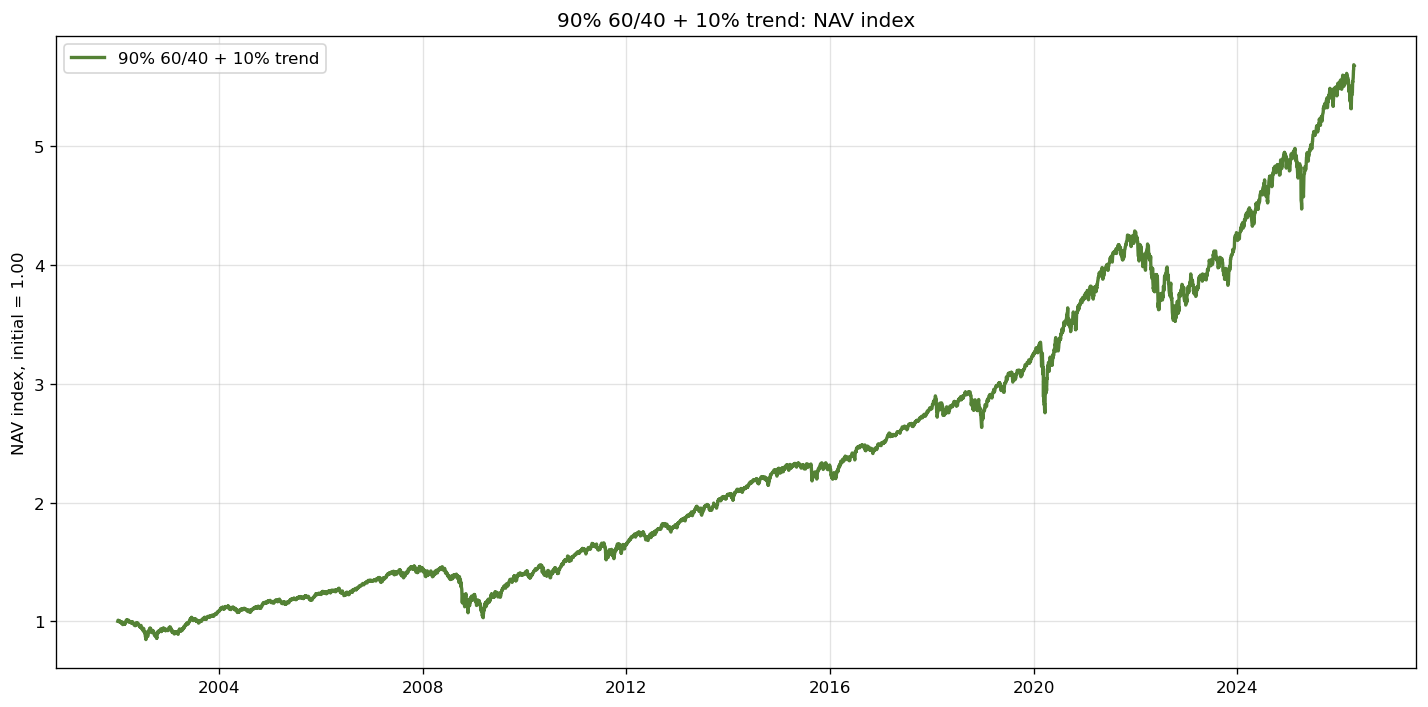

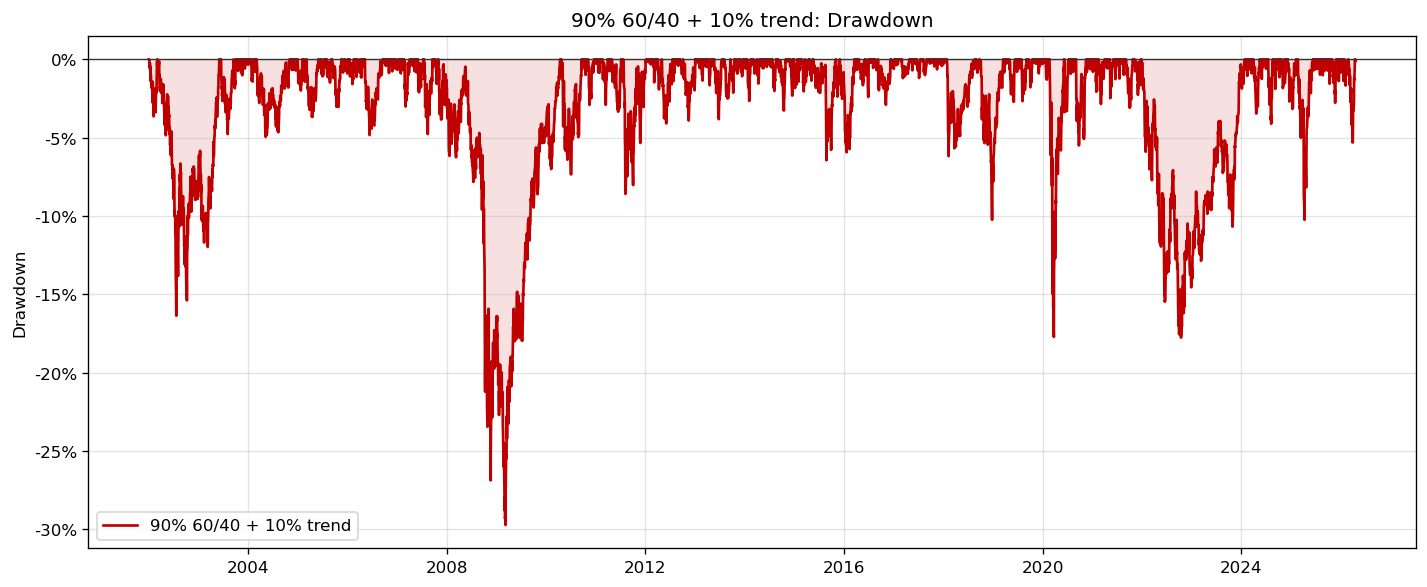

Monthly returns — 90% 60/40 + 10% trend


month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
year,,,,,,,,,,,,,
2002,-0.5%,-0.7%,1.2%,-2.4%,0.0%,-3.5%,-3.3%,1.4%,-4.9%,4.4%,2.8%,-1.9%,-7.6%
2003,-1.0%,-0.2%,0.3%,5.1%,4.1%,0.5%,-0.7%,1.3%,0.6%,2.8%,0.7%,3.5%,18.1%
2004,1.3%,1.5%,-0.5%,-2.3%,0.7%,1.1%,-1.5%,1.2%,0.8%,1.3%,2.0%,2.1%,7.8%
2005,-1.1%,1.0%,-1.2%,-0.5%,2.2%,0.3%,1.6%,0.3%,0.4%,-1.4%,2.4%,0.3%,4.3%
2006,1.6%,0.2%,0.4%,1.1%,-1.9%,-0.2%,0.8%,1.7%,1.5%,2.0%,1.6%,0.3%,9.4%
2007,0.8%,-0.3%,0.8%,2.8%,1.6%,-0.9%,-1.0%,1.1%,2.5%,1.7%,-1.4%,-0.1%,7.6%
2008,-2.0%,-0.7%,-0.3%,2.3%,0.5%,-4.0%,-0.6%,0.8%,-4.3%,-9.3%,-1.6%,2.1%,-16.3%
2009,-5.6%,-5.9%,5.7%,4.7%,3.6%,-0.0%,4.4%,2.2%,2.8%,-0.7%,4.2%,-0.2%,15.4%
2010,-1.5%,1.9%,2.9%,1.5%,-4.0%,-2.1%,4.1%,-1.8%,5.4%,2.3%,-0.2%,3.4%,12.1%


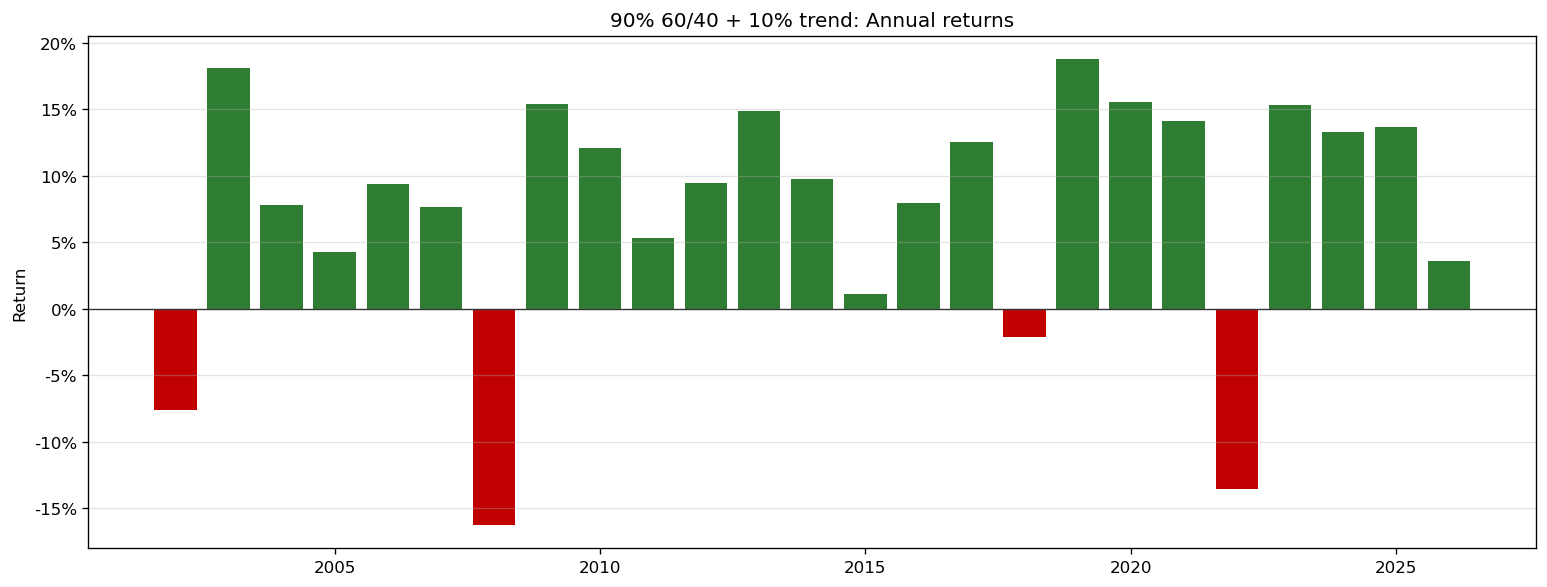

In [8]:


# Section 3.1 — 10% trend sleeve on top of 60/40
W_T_SLEEVE = 0.10

mix_10 = build_mix(W_T_SLEEVE, r_trend, r_bench)
stats_mix10 = evaluate(S_MIX, mix_10, w_T=W_T_SLEEVE)

,Metric,100% 60/40,90% 60/40 + 10% trend,100% trend
0,Start date,2002-01-02,2002-01-02,2002-01-02
1,End date,2026-04-20,2026-04-20,2026-04-20
2,Initial AUM,"$100,000,000","$100,000,000","$100,000,000"
3,Ending NAV,"$602,519,538","$567,914,149","$283,449,790"
4,Total return,502.04%,467.51%,183.45%
5,Annual rate of return,7.67%,7.41%,4.38%
6,Annualized volatility,10.87%,9.92%,7.08%
7,"Sharpe ratio, rf=0",0.71,0.75,0.62
8,Maximum drawdown,-32.68%,-29.73%,-15.93%
9,Maximum drawdown start,2007-10-09,2007-10-31,2008-07-14


Saved part3_sleeve_10_summary.csv and part3_sleeve_10_daily.csv


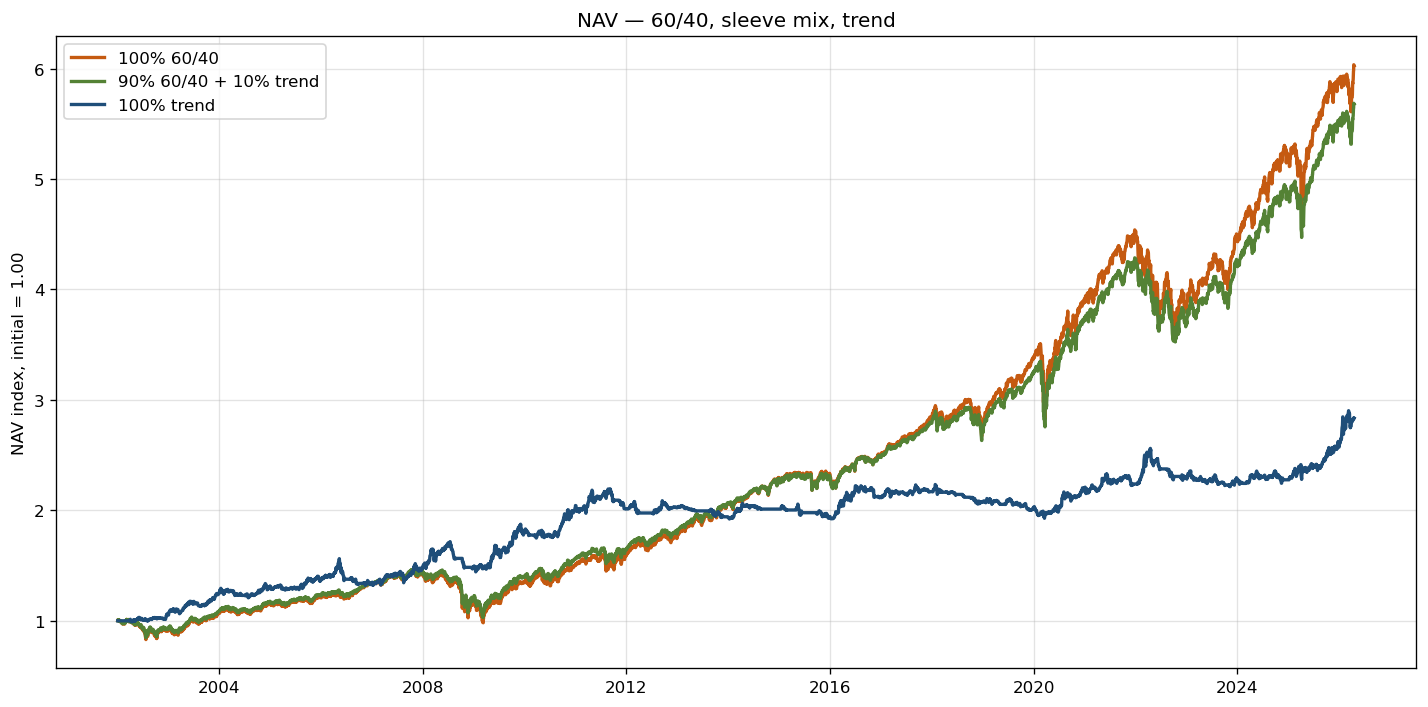

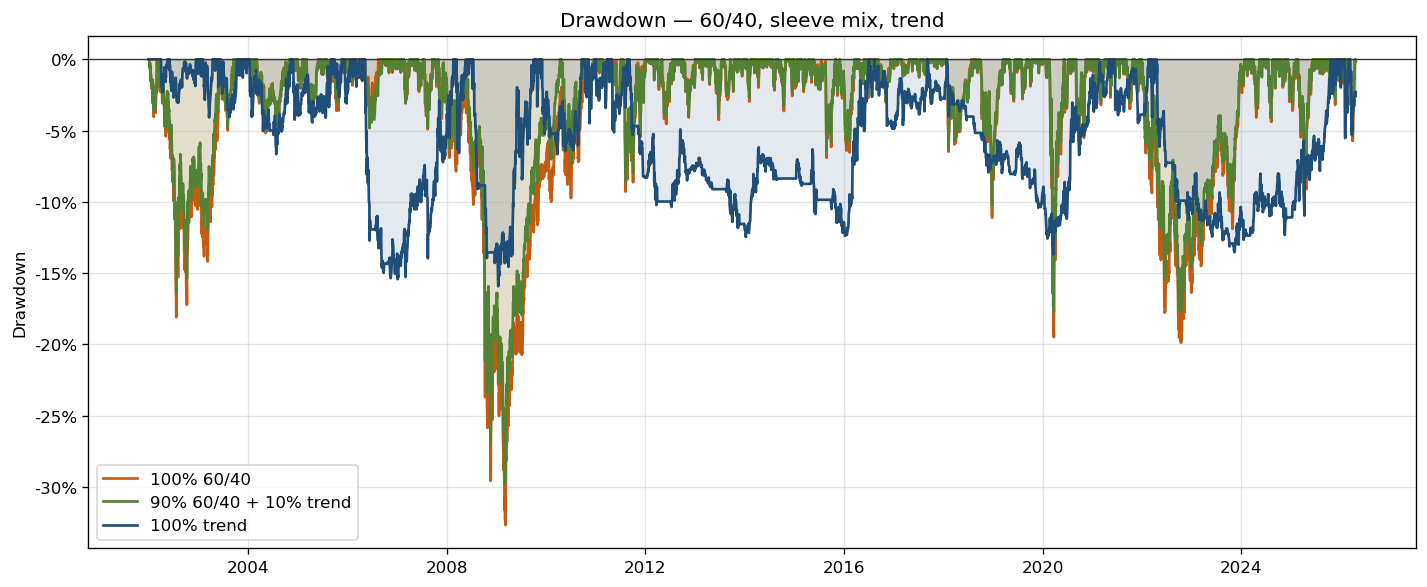

In [9]:


# Side-by-side: three building-block portfolios (same calendar as Part 3)
stats_b = summary_stats(S_6040, r_bench, w_T=0.0)
stats_t = summary_stats(S_TREND, r_trend, w_T=1.0)
side_table = summary_table([stats_b, stats_mix10, stats_t])
display(side_table)

side_table.to_csv(OUTPUT_DIR / "part3_sleeve_10_summary.csv", index=False)
sleeve_daily = pd.DataFrame({
    "trend_ret": r_trend,
    "bench_ret": r_bench,
    "mix10_ret": mix_10,
    "trend_nav": daily_to_nav(r_trend),
    "bench_nav": daily_to_nav(r_bench),
    "mix10_nav": daily_to_nav(mix_10),
})
sleeve_daily.to_csv(OUTPUT_DIR / "part3_sleeve_10_daily.csv")
print("Saved part3_sleeve_10_summary.csv and part3_sleeve_10_daily.csv")

plot_nav(
    {S_6040: r_bench, S_MIX: mix_10, S_TREND: r_trend},
    "NAV — 60/40, sleeve mix, trend",
    colors={k: STRATEGY_COLORS[k] for k in (S_6040, S_MIX, S_TREND)},
)
plot_drawdown(
    {S_6040: r_bench, S_MIX: mix_10, S_TREND: r_trend},
    "Drawdown — 60/40, sleeve mix, trend",
    colors={k: STRATEGY_COLORS[k] for k in (S_6040, S_MIX, S_TREND)},
)

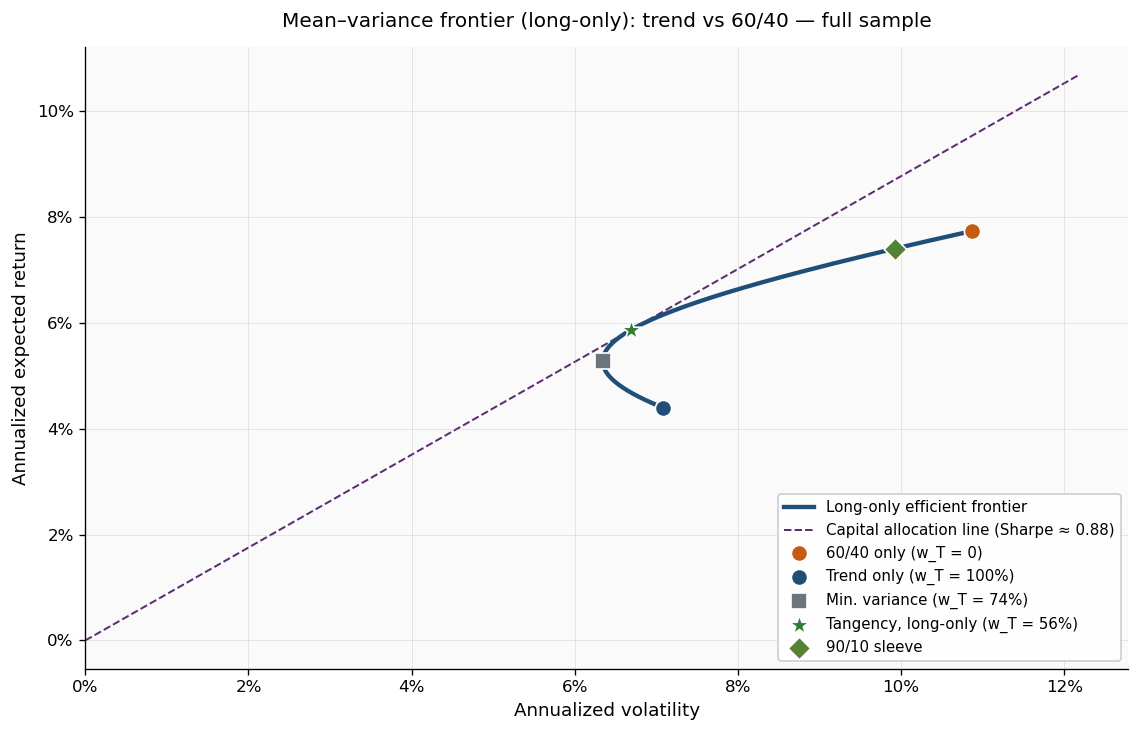

,Strategy,w_T,w_B,ann_return,ann_vol,sharpe
0,Tangency (long-only),55.9%,44.1%,5.86%,6.69%,0.88
1,Min-variance (long-only),73.7%,26.3%,5.27%,6.34%,0.83
2,90/10 sleeve,10.0%,90.0%,7.40%,9.92%,0.75
3,60/40 only,0.0%,100.0%,7.73%,10.87%,0.71
4,Trend only,100.0%,0.0%,4.39%,7.08%,0.62


Saved part3_static_mv_weights.csv


In [10]:


# Section 3.2 — static long-only MV + efficient frontier (full sample)
returns_mat = pd.concat([r_trend.rename("T"), r_bench.rename("B")], axis=1).dropna()

mu_d = returns_mat.mean()
Sigma_d = returns_mat.cov()
mu_a = TRADING_DAYS * mu_d.values
Sigma_a = TRADING_DAYS * Sigma_d.values
inv_S = np.linalg.inv(Sigma_a)

# Tangency direction (rf=0): w ∝ Σ⁻¹μ, then project to long-only simplex
w_tan_raw = inv_S @ mu_a
w_tan_raw = w_tan_raw / w_tan_raw.sum()

# Minimum-variance weights, then project
w_mv_raw = inv_S @ np.ones(2)
w_mv_raw = w_mv_raw / w_mv_raw.sum()


def project_long_only(w_vec: np.ndarray) -> np.ndarray:
    w_T = float(w_vec[0])
    if w_T < 0.0:
        return np.array([0.0, 1.0])
    if w_T > 1.0:
        return np.array([1.0, 0.0])
    return np.array([w_T, 1.0 - w_T])


w_lo = project_long_only(w_tan_raw)
w_mv = project_long_only(w_mv_raw)


def port_stats(w_T: float, mu=mu_a, Sg=Sigma_a):
    w = np.array([w_T, 1.0 - w_T])
    mu_p = float(w @ mu)
    sig_p = float(np.sqrt(w @ Sg @ w))
    return sig_p, mu_p


grid_lo = np.linspace(0.0, 1.0, 401)
front_lo = np.array([port_stats(w) for w in grid_lo])

sig_T, mu_T = port_stats(1.0)
sig_B, mu_B = port_stats(0.0)
sig_mv, mu_mv = port_stats(float(w_mv[0]))
sig_lo, mu_lo = port_stats(float(w_lo[0]))
sig_sleeve, mu_sleeve = port_stats(W_T_SLEEVE)

# CAL through origin and long-only tangency point
sh_max = mu_lo / sig_lo if sig_lo > 0 else float("nan")
sigma_axis_max = max(sig_T, sig_B, sig_lo, sig_sleeve) * 1.12

fig, ax = plt.subplots(figsize=(9.6, 6.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("#FAFAFA")

ax.plot(
    front_lo[:, 0],
    front_lo[:, 1],
    color="#1F4E79",
    linewidth=2.6,
    label="Long-only efficient frontier",
    zorder=2,
)

xx = np.linspace(0.0, float(sigma_axis_max), 120)
ax.plot(
    xx,
    sh_max * xx,
    color="#5B2C6F",
    linewidth=1.2,
    linestyle="--",
    label=f"Capital allocation line (Sharpe ≈ {sh_max:.2f})",
    zorder=1,
)

_sc = dict(edgecolors="white", linewidths=1.0, zorder=5)

ax.scatter([sig_B], [mu_B], s=95, color=PART3_COLORS["BENCH"], marker="o",
             label="60/40 only (w_T = 0)", **_sc)
ax.scatter([sig_T], [mu_T], s=95, color=PART3_COLORS["TREND"], marker="o",
             label="Trend only (w_T = 100%)", **_sc)
ax.scatter(
    [sig_mv], [mu_mv], s=88, color="#6C757D", marker="s",
    label=f"Min. variance (w_T = {float(w_mv[0]):.0%})", **_sc,
)
ax.scatter(
    [sig_lo], [mu_lo], s=160, color="#2E7D32", marker="*",
    label=f"Tangency, long-only (w_T = {float(w_lo[0]):.0%})", **_sc,
)
ax.scatter(
    [sig_sleeve], [mu_sleeve], s=92, color=PART3_COLORS["MIX"], marker="D",
    label="90/10 sleeve", **_sc,
)

ax.set_xlim(left=0.0)
ax.set_xlabel("Annualized volatility", fontsize=11)
ax.set_ylabel("Annualized expected return", fontsize=11)
ax.set_title(
    "Mean–variance frontier (long-only): trend vs 60/40 — full sample",
    fontsize=12,
    pad=12,
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(True, linestyle="-", linewidth=0.6, alpha=0.28)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower right", framealpha=0.96, fontsize=9)
fig.tight_layout()
plt.show()

rows = []
for label, wT in [
    ("Tangency (long-only)", float(w_lo[0])),
    ("Min-variance (long-only)", float(w_mv[0])),
    ("90/10 sleeve", W_T_SLEEVE),
    ("60/40 only", 0.0),
    ("Trend only", 1.0),
]:
    s_val, m_val = port_stats(wT)
    sh = m_val / s_val if s_val > 0 else float("nan")
    rows.append({
        "Strategy": label,
        "w_T": wT,
        "w_B": 1.0 - wT,
        "ann_return": m_val,
        "ann_vol": s_val,
        "sharpe": sh,
    })

static_mv_weights = pd.DataFrame(rows)
display(
    static_mv_weights.assign(
        w_T=lambda d: d["w_T"].map(lambda x: f"{x:.1%}"),
        w_B=lambda d: d["w_B"].map(lambda x: f"{x:.1%}"),
        ann_return=lambda d: d["ann_return"].map(lambda x: f"{x:.2%}"),
        ann_vol=lambda d: d["ann_vol"].map(lambda x: f"{x:.2%}"),
        sharpe=lambda d: d["sharpe"].map(lambda x: f"{x:.2f}"),
    )
)
static_mv_weights.to_csv(OUTPUT_DIR / "part3_static_mv_weights.csv", index=False)
print("Saved part3_static_mv_weights.csv")

=== static MV ===


,Metric,static MV
0,Start date,2002-01-02
1,End date,2026-04-20
2,Initial AUM,"$100,000,000"
3,Ending NAV,"$413,197,949"
4,Total return,313.05%
5,Annual rate of return,6.01%
6,Annualized volatility,6.69%
7,"Sharpe ratio, rf=0",0.90
8,Maximum drawdown,-19.41%
9,Maximum drawdown start,2008-05-16


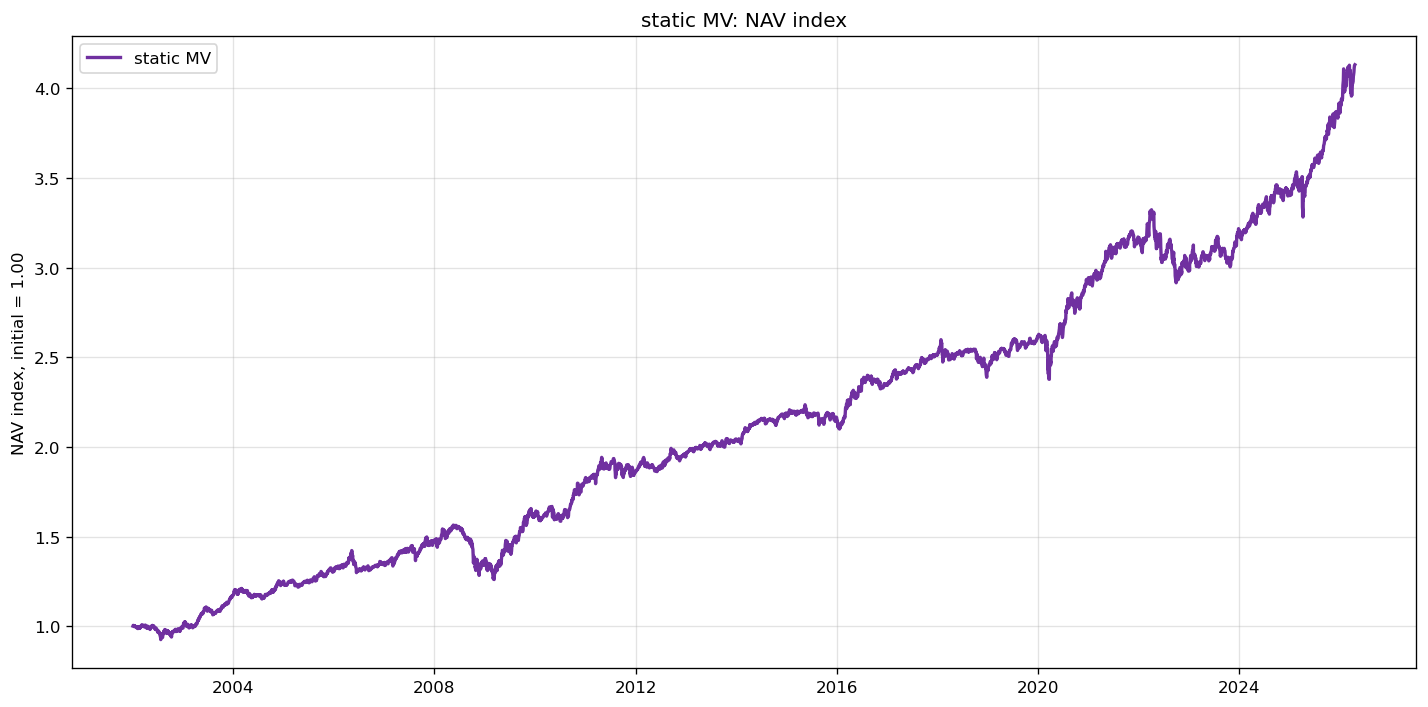

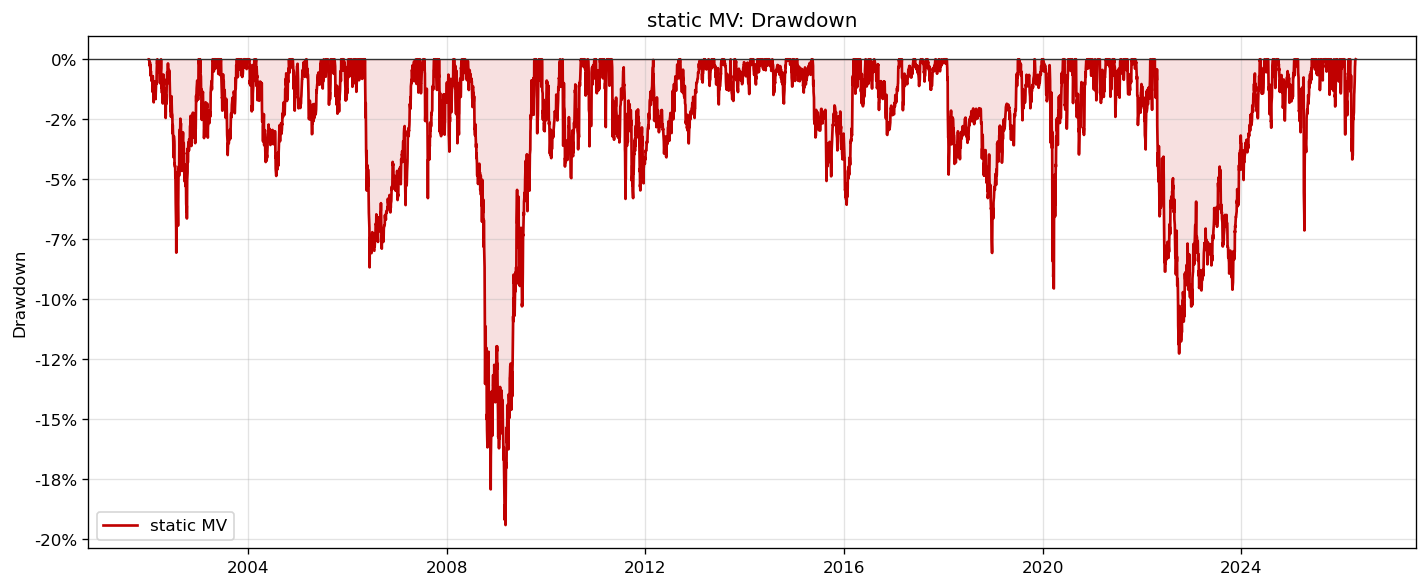

Monthly returns — static MV


month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
year,,,,,,,,,,,,,
2002,-0.2%,-0.3%,0.6%,-0.8%,1.0%,-2.5%,-1.8%,1.2%,-1.8%,2.1%,0.9%,0.8%,-1.0%
2003,1.9%,-0.4%,-0.5%,5.1%,2.9%,0.4%,-0.9%,0.5%,0.7%,3.0%,1.0%,3.8%,18.8%
2004,0.5%,2.0%,-0.5%,-2.7%,0.5%,0.2%,-1.2%,1.5%,1.0%,1.8%,2.7%,0.6%,6.4%
2005,-0.9%,1.0%,-1.4%,-0.6%,1.5%,-0.1%,1.0%,1.1%,2.6%,-1.8%,2.4%,-0.3%,4.4%
2006,2.2%,0.2%,0.5%,3.0%,-2.6%,-2.4%,0.5%,0.5%,-0.5%,1.1%,1.8%,-0.7%,3.5%
2007,0.4%,0.4%,1.2%,2.3%,1.0%,-0.4%,0.0%,-1.2%,2.9%,3.5%,-2.2%,0.8%,8.9%
2008,0.8%,3.1%,-2.3%,2.7%,1.5%,-0.4%,-2.1%,-1.9%,-2.1%,-7.0%,-0.7%,1.4%,-7.2%
2009,-3.1%,-2.7%,2.4%,3.5%,6.4%,-0.5%,2.7%,0.6%,3.9%,1.0%,4.4%,-1.4%,18.1%
2010,-1.4%,1.1%,1.3%,2.0%,-3.3%,-0.7%,2.4%,-1.2%,6.0%,2.4%,-0.2%,4.3%,13.1%


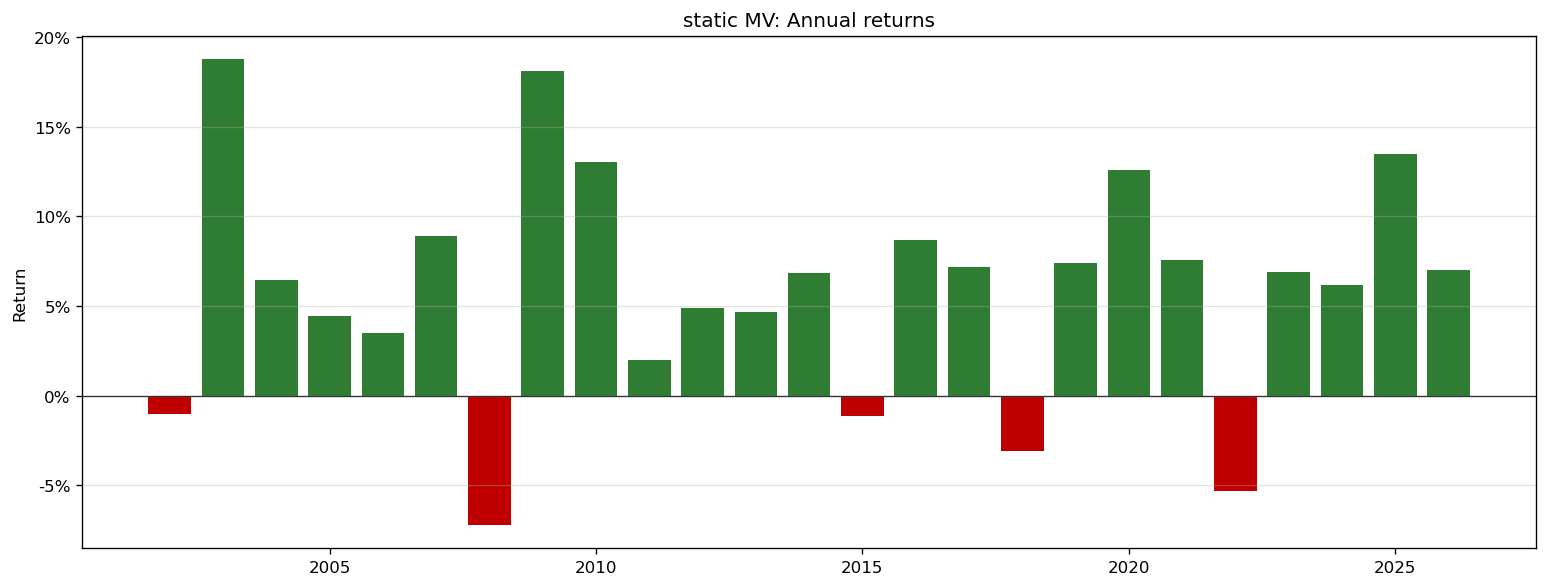

In [11]:


# Standard evaluation block — static MV (full-sample long-only tangency mix)
mix_static_lo = build_mix(float(w_lo[0]), r_trend, r_bench)
stats_static_lo = evaluate(S_STATIC_MV, mix_static_lo, w_T=float(w_lo[0]))

### Section 3.3 — Dynamic long-only mean-variance (dynamic MV)

Construction:

1. Inputs are the daily returns of 100% trend and 100% 60/40 from the upstream backtests.
2. Rolling estimation window: at each month-end (last trading day on the merged calendar), use the prior 756 trading days (~3 years of trading days) to compute sample mean and covariance, annualized the same way as §3.2 (mean ×252, covariance ×252).
3. Rebalance: from the rolling estimates, compute the long-only tangency mix (weights ≥ 0 summing to 1, same `[0,1]` projection as static MV). Weights apply the next trading day and hold until the next month-end update; the month-end itself still earns the previous month's weights.
4. Warm-up: skip MV updates until at least 504 trading days of history are available; no row is appended to `dynamic_weights` for those months.
5. Pre-MV phase: until the first rolling weight takes effect, dynamic MV holds the §3.1 sleeve mix (90% 60/40 + 10% trend, `w_T = 10%`). This keeps the same start date as every other strategy.
6. Daily weight grid: initialize `w_T_tan` and `w_T_mv` to `W_T_SLEEVE` (10%), overwrite on the trading day after each MV update, then forward-fill.

The plot below shows `w_T_tan` over time — flat at 10% until the first rolling update, then MV-driven. `w_T_mv` in the saved CSV uses the same initialization.

In [12]:


# Section 3.3 — dynamic long-only MV setup
LOOKBACK = 756  # ~3 years of trading days
MIN_OBS = 504   # ~2 years warmup before first dynamic weight

period = returns_mat.index.to_period("M")
me_df = pd.DataFrame({"d": returns_mat.index, "p": period}).groupby("p")["d"].last()
month_ends = pd.DatetimeIndex(me_df.values)
print(
    f"Calendar month-ends in merged sample: {len(month_ends)} "
    f"(first={month_ends[0].date()}, last={month_ends[-1].date()}).\n"
    f"These are candidate rebalance dates only. No MV weight is saved until "
    f"≥ {MIN_OBS} trading days exist through that month-end — early dates are skipped."
)


def solve_window_long_only(window: pd.DataFrame):
    """Long-only tangency + long-only min-variance for a 2-asset return window."""
    mu_w = TRADING_DAYS * window.mean().values
    Sg_w = TRADING_DAYS * window.cov().values
    inv_w = np.linalg.inv(Sg_w)
    w_tan_raw = inv_w @ mu_w
    w_tan_raw = w_tan_raw / w_tan_raw.sum()
    w_mv_raw = inv_w @ np.ones(2)
    w_mv_raw = w_mv_raw / w_mv_raw.sum()
    w_tan = project_long_only(w_tan_raw)
    w_mv_w = project_long_only(w_mv_raw)
    return w_tan, w_mv_w


records = []
for me in month_ends:
    end_pos = returns_mat.index.get_loc(me)
    if end_pos + 1 < MIN_OBS:
        continue
    start_pos = max(0, end_pos + 1 - LOOKBACK)
    window = returns_mat.iloc[start_pos:end_pos + 1]
    if len(window) < MIN_OBS:
        continue
    w_tan_d, w_mv_d = solve_window_long_only(window)
    records.append({
        "date": me,
        "w_T_tan": float(w_tan_d[0]),
        "w_T_mv": float(w_mv_d[0]),
        "n_obs": int(len(window)),
    })

dynamic_weights = pd.DataFrame(records).set_index("date").sort_index()
print(
    f"Emitted weights: {len(dynamic_weights)} month-end rows "
    f"(first weight date={dynamic_weights.index[0].date()}, "
    f"last={dynamic_weights.index[-1].date()}). "
    f"Skipped {len(month_ends) - len(dynamic_weights)} early month-ends during warm-up."
)
display(dynamic_weights.head())
display(dynamic_weights.tail())

Calendar month-ends in merged sample: 292 (first=2002-01-31, last=2026-04-20).
These are candidate rebalance dates only. No MV weight is saved until ≥ 504 trading days exist through that month-end — early dates are skipped.
Emitted weights: 269 month-end rows (first weight date=2003-12-31, last=2026-04-20). Skipped 23 early month-ends during warm-up.


,w_T_tan,w_T_mv,n_obs
date,,,
2003-12-31,0.872495,0.767956,521
2004-01-30,0.848044,0.747369,543
2004-02-27,0.847120,0.745787,563
2004-03-31,0.850030,0.744604,586
2004-04-30,0.861510,0.740236,608


,w_T_tan,w_T_mv,n_obs
date,,,
2025-12-31,0.250189,0.715715,756
2026-01-30,0.372599,0.668645,756
2026-02-27,0.425059,0.617521,756
2026-03-31,0.420862,0.604304,756
2026-04-20,0.418467,0.605902,756


All Part 3 strategies — shared calendar: 2002-01-02 → 2026-04-20  (6339 days)


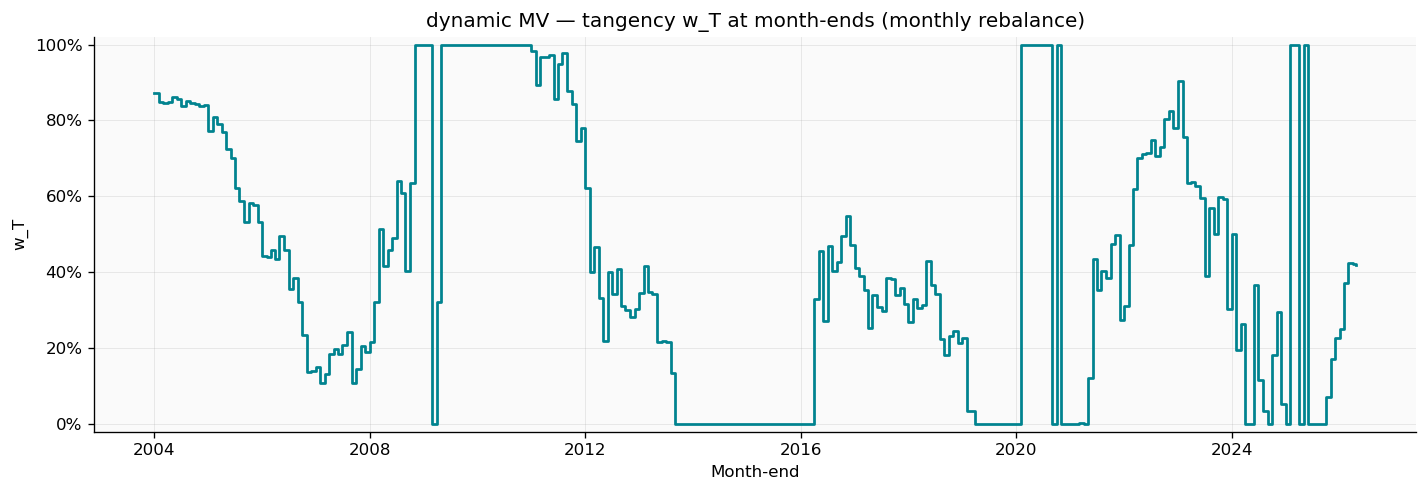

Average monthly |Δw_T| (dynamic MV tangency): 0.0877  (~1.05 per year in rebalance steps)


In [13]:


# Daily weights: before first rolling MV update, hold 90% 60/40 + 10% trend (same as §3.1 sleeve).
# After each month-end, set weights on the next trading day, then forward-fill until the next update.
# (Filling the whole grid with W_T_SLEEVE makes .ffill() a no-op and kept only ~one dynamic day per month.)
w_panel = pd.DataFrame(
    index=returns_mat.index,
    columns=["w_T_tan", "w_T_mv"],
    dtype=float,
)
w_panel[:] = np.nan

for col in w_panel.columns:
    for me, w_val in dynamic_weights[col].items():
        pos = returns_mat.index.get_loc(me)
        if pos + 1 < len(returns_mat):
            w_panel.loc[returns_mat.index[pos + 1], col] = float(w_val)

w_panel = w_panel.ffill().fillna(W_T_SLEEVE)


def apply_weight(w_T_series: pd.Series, returns: pd.DataFrame, name: str) -> pd.Series:
    df = pd.concat([w_T_series.rename("w"), returns["T"], returns["B"]], axis=1, join="inner").dropna()
    return (df["w"] * df["T"] + (1.0 - df["w"]) * df["B"]).rename(name)


dyn_tan_ret = apply_weight(w_panel["w_T_tan"], returns_mat, "dyn_tan")

oos_index = returns_mat.index
oos_b = r_bench.reindex(oos_index)
oos_t = r_trend.reindex(oos_index)
static_lo_oos = build_mix(float(w_lo[0]), oos_t, oos_b).rename("static_lo_held")

print(f"All Part 3 strategies — shared calendar: {oos_index[0].date()} → {oos_index[-1].date()}  ({len(oos_index)} days)")

# Monthly rolling MV tangency only (one estimate per month-end from μ, Σ on raw r_T, r_B).
w_me = dynamic_weights["w_T_tan"]
fig, ax = plt.subplots(figsize=(12, 4.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("#FAFAFA")
ax.step(w_me.index, w_me.values, where="post", color=STRATEGY_COLORS[S_DYNAMIC_MV], linewidth=1.65)
ax.set_title("dynamic MV — tangency w_T at month-ends (monthly rebalance)", fontsize=12)
ax.set_xlabel("Month-end")
ax.set_ylabel("w_T")
ax.set_ylim(-0.02, 1.02)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.grid(True, linestyle="-", linewidth=0.55, alpha=0.28)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

mo_diff_tan = dynamic_weights["w_T_tan"].diff().abs().mean()
print(f"Average monthly |Δw_T| (dynamic MV tangency): {mo_diff_tan:.4f}  (~{mo_diff_tan * 12:.2f} per year in rebalance steps)")

=== dynamic MV ===


,Metric,dynamic MV
0,Start date,2002-01-02
1,End date,2026-04-20
2,Initial AUM,"$100,000,000"
3,Ending NAV,"$561,254,690"
4,Total return,460.85%
5,Annual rate of return,7.36%
6,Annualized volatility,7.95%
7,"Sharpe ratio, rf=0",0.93
8,Maximum drawdown,-18.33%
9,Maximum drawdown start,2008-05-16


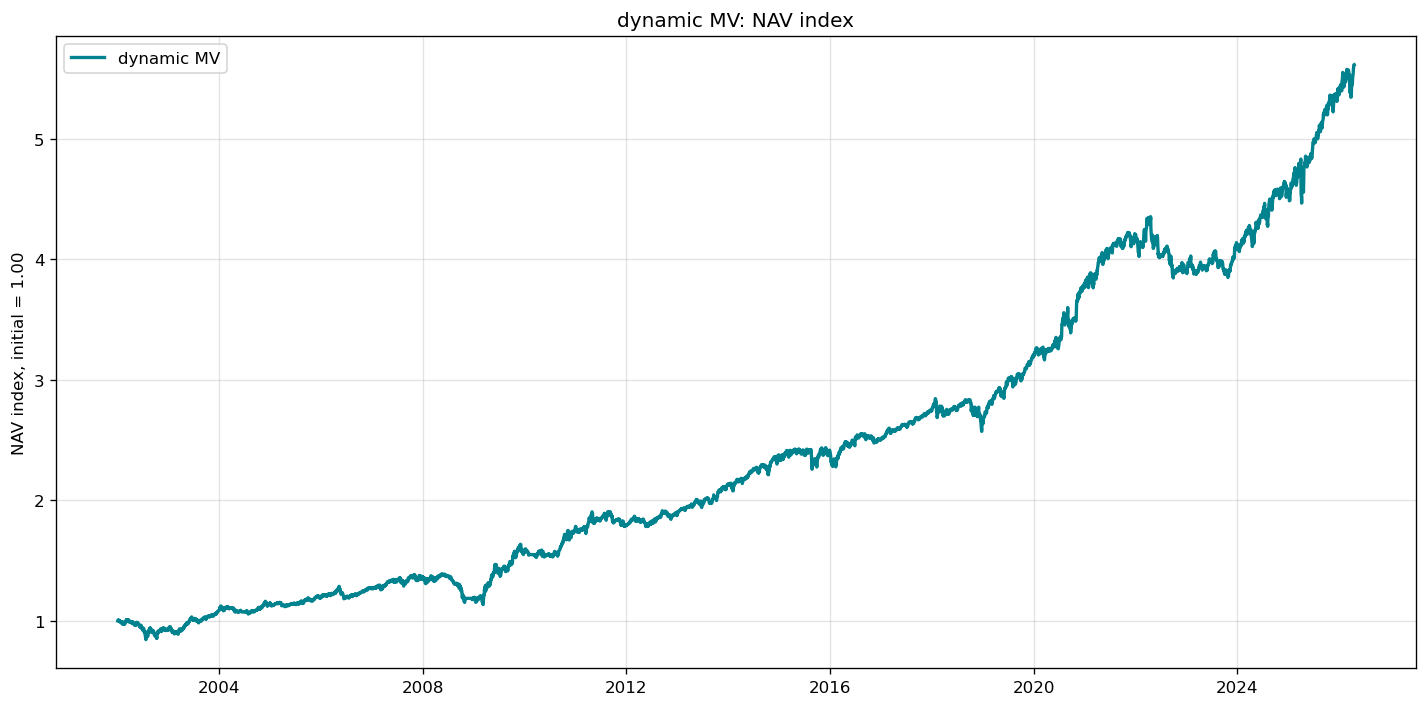

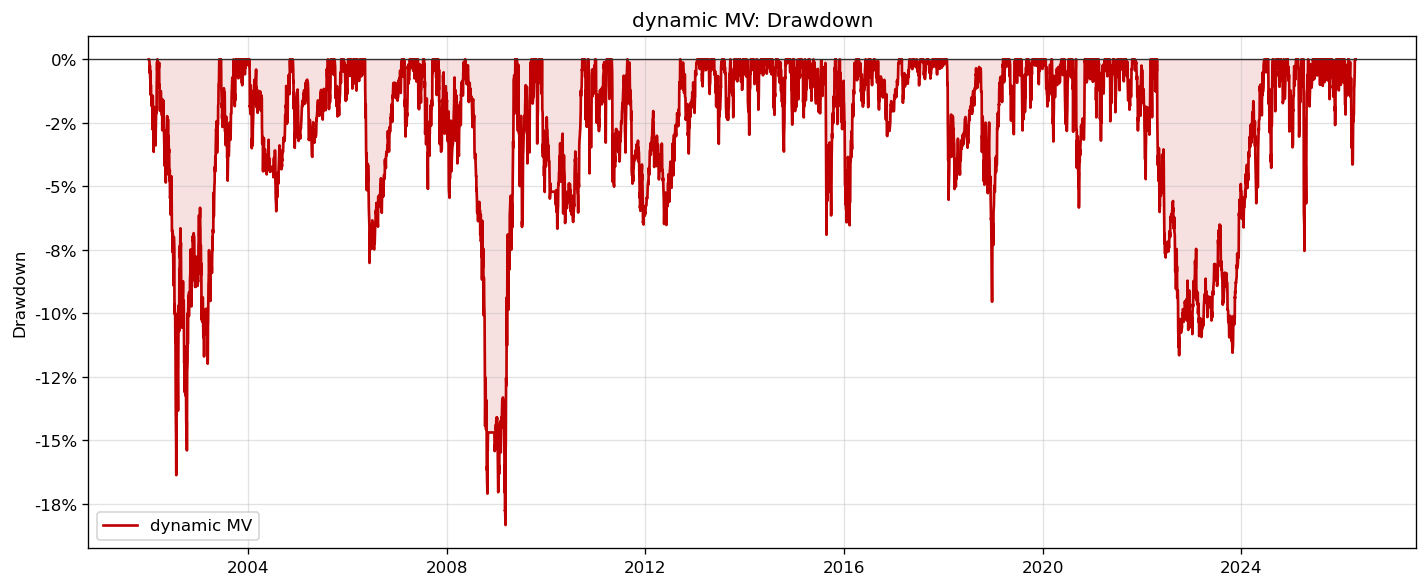

Monthly returns — dynamic MV


month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
year,,,,,,,,,,,,,
2002,-0.5%,-0.7%,1.2%,-2.4%,0.0%,-3.5%,-3.3%,1.4%,-4.9%,4.4%,2.8%,-1.9%,-7.6%
2003,-1.0%,-0.2%,0.3%,5.1%,4.1%,0.5%,-0.7%,1.3%,0.6%,2.8%,0.7%,3.5%,18.1%
2004,-0.1%,2.4%,-0.4%,-2.9%,0.3%,-0.5%,-1.1%,1.7%,1.1%,2.0%,3.1%,-0.3%,5.4%
2005,-0.8%,1.0%,-1.5%,-0.7%,1.2%,-0.3%,1.0%,1.2%,2.5%,-1.8%,2.3%,-0.3%,3.8%
2006,2.1%,0.2%,0.5%,2.5%,-2.5%,-2.0%,0.7%,0.9%,0.5%,1.7%,1.6%,0.2%,6.5%
2007,0.7%,-0.3%,0.8%,2.7%,1.5%,-0.8%,-0.7%,0.4%,2.6%,1.9%,-1.6%,0.0%,7.2%
2008,-1.3%,1.1%,-2.1%,2.6%,1.3%,-1.0%,-2.4%,-2.1%,-2.8%,-6.7%,0.0%,0.6%,-12.4%
2009,-0.7%,0.3%,6.4%,4.1%,9.2%,-1.0%,1.2%,-1.0%,4.9%,2.7%,4.6%,-2.6%,31.2%
2010,-1.4%,0.3%,-0.2%,2.5%,-2.7%,0.6%,0.8%,-0.6%,6.5%,2.6%,-0.1%,5.1%,13.8%


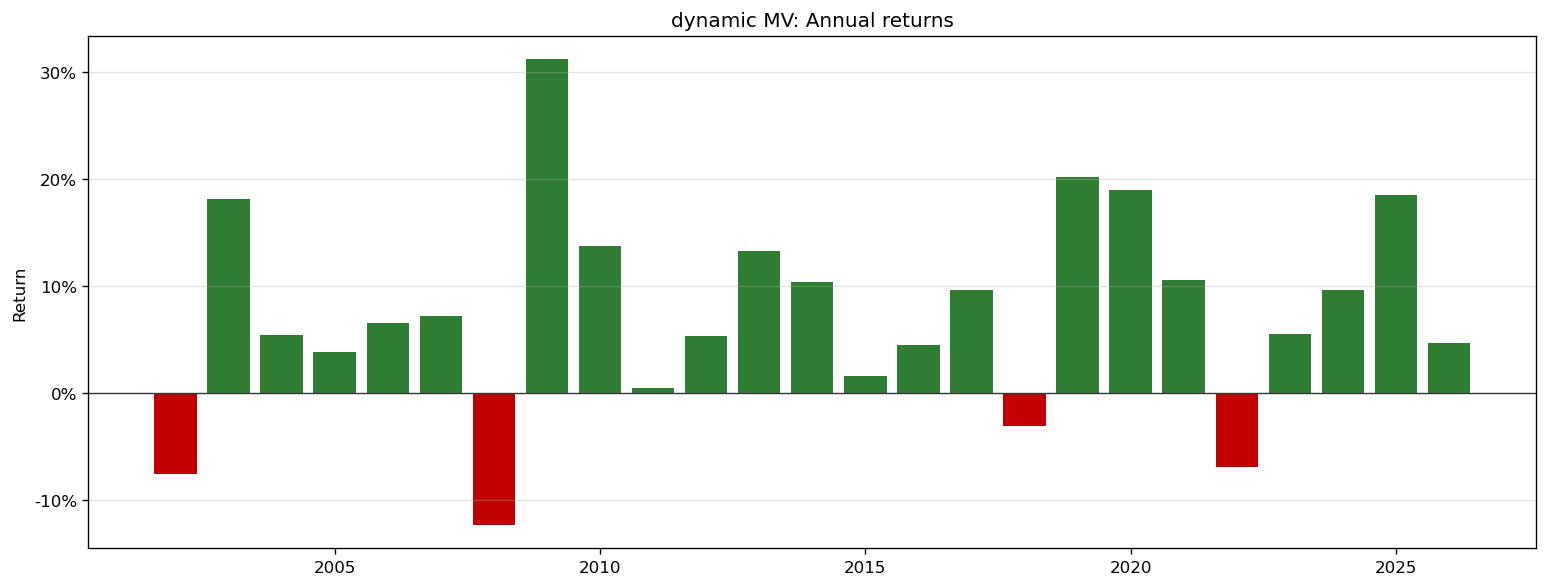

In [14]:


stats_dyn_tan = evaluate(S_DYNAMIC_MV, dyn_tan_ret)


# 

In [15]:


# Save rolling-weight panel + daily series on the shared window (tables/plots for all five → §3.4)
dynamic_weights.to_csv(OUTPUT_DIR / "part3_dynamic_weights.csv")
dynamic_daily = pd.DataFrame({
    "ret_100pct_60_40": oos_b,
    "ret_static_mv": static_lo_oos,
    "ret_dynamic_mv": dyn_tan_ret,
    "nav_100pct_60_40": daily_to_nav(oos_b),
    "nav_static_mv": daily_to_nav(static_lo_oos),
    "nav_dynamic_mv": daily_to_nav(dyn_tan_ret),
    "w_T_tan": w_panel["w_T_tan"].reindex(oos_index),
    "w_T_mv": w_panel["w_T_mv"].reindex(oos_index),
})
dynamic_daily.to_csv(OUTPUT_DIR / "part3_dynamic_daily.csv")
print("Saved part3_dynamic_weights.csv, part3_dynamic_daily.csv")

Saved part3_dynamic_weights.csv, part3_dynamic_daily.csv


,Metric,100% 60/40,100% trend,90% 60/40 + 10% trend,static MV,dynamic MV
0,Start date,2002-01-02,2002-01-02,2002-01-02,2002-01-02,2002-01-02
1,End date,2026-04-20,2026-04-20,2026-04-20,2026-04-20,2026-04-20
2,Initial AUM,"$100,000,000","$100,000,000","$100,000,000","$100,000,000","$100,000,000"
3,Ending NAV,"$602,519,538","$283,449,790","$567,914,149","$413,197,949","$561,254,690"
4,Total return,502.04%,183.45%,467.51%,313.05%,460.85%
5,Annual rate of return,7.67%,4.38%,7.41%,6.01%,7.36%
6,Annualized volatility,10.87%,7.08%,9.92%,6.69%,7.95%
7,"Sharpe ratio, rf=0",0.71,0.62,0.75,0.90,0.93
8,Maximum drawdown,-32.68%,-15.93%,-29.73%,-19.41%,-18.33%
9,Maximum drawdown start,2007-10-09,2008-07-14,2007-10-31,2008-05-16,2008-05-16


Saved part3_five_strategies_summary.csv


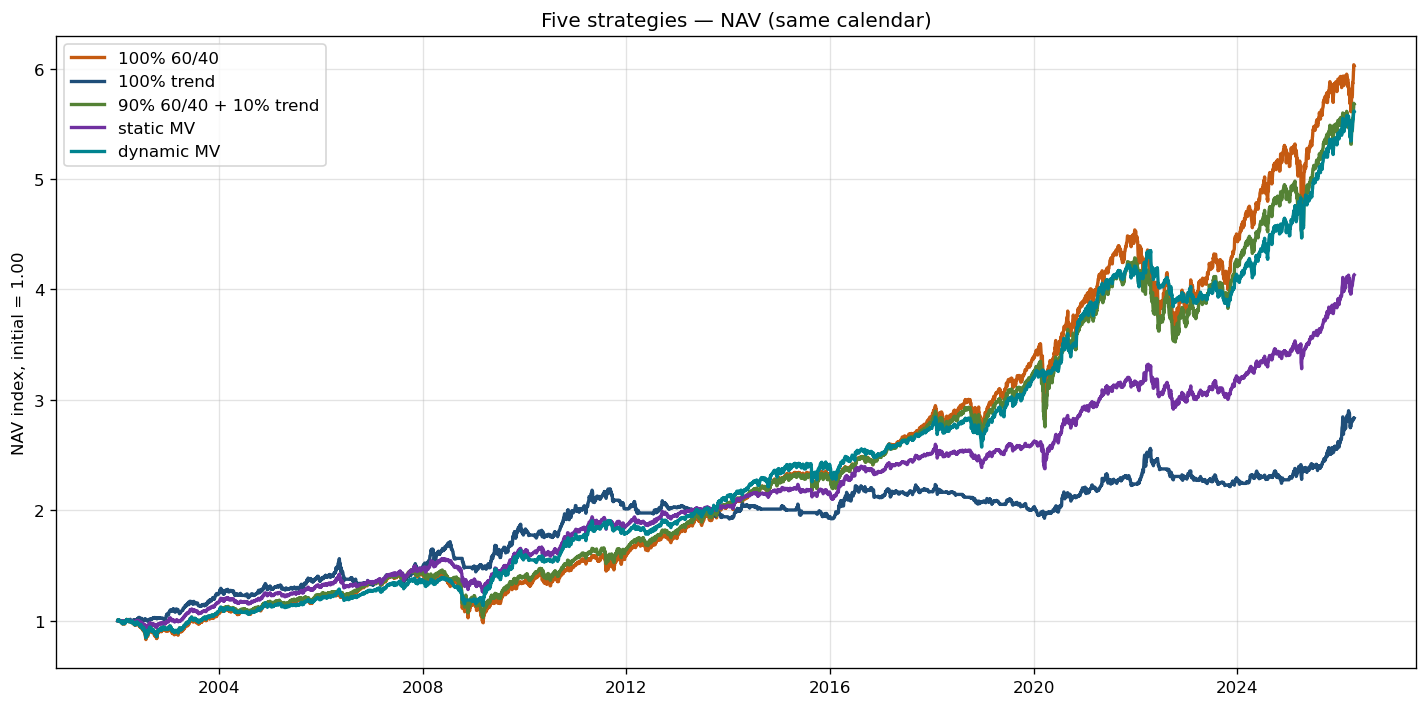

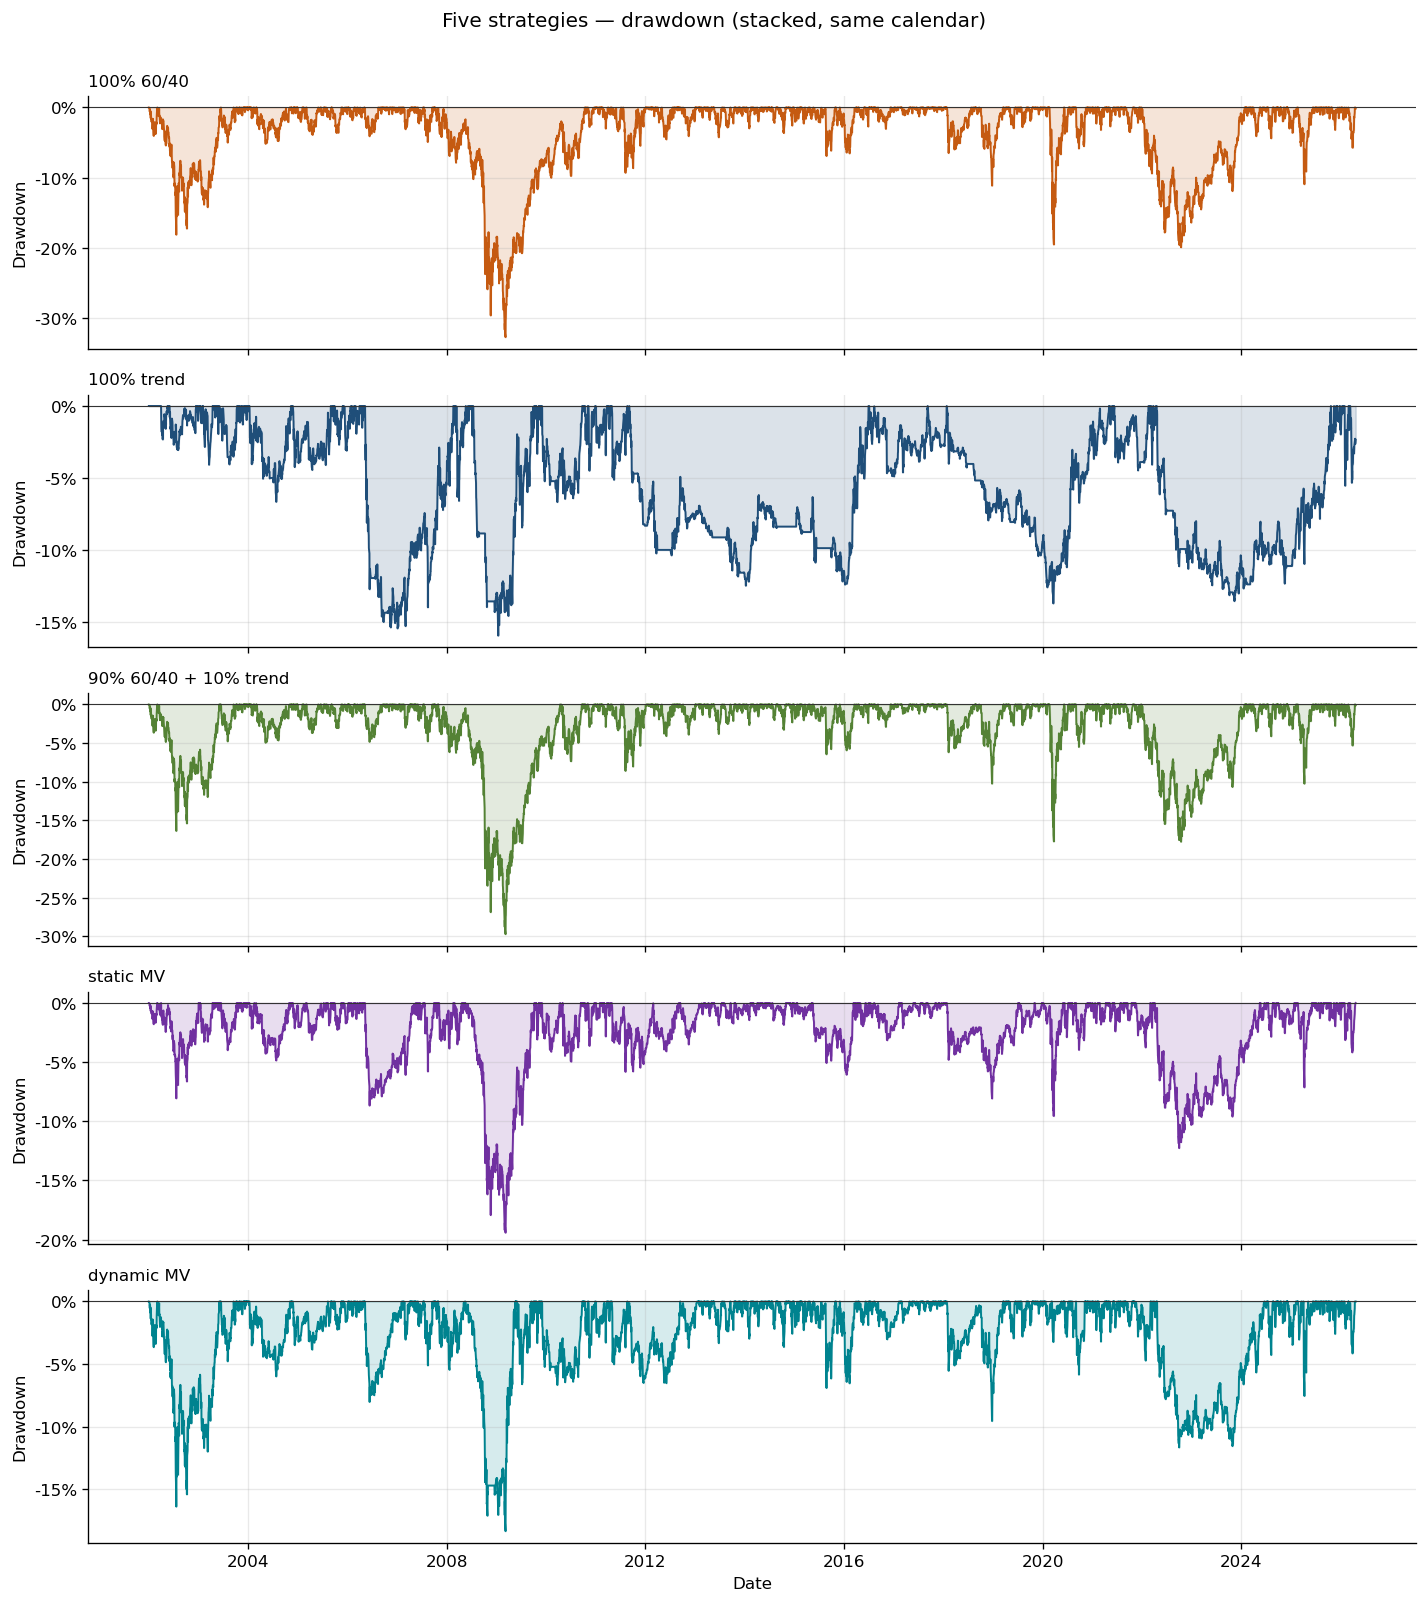

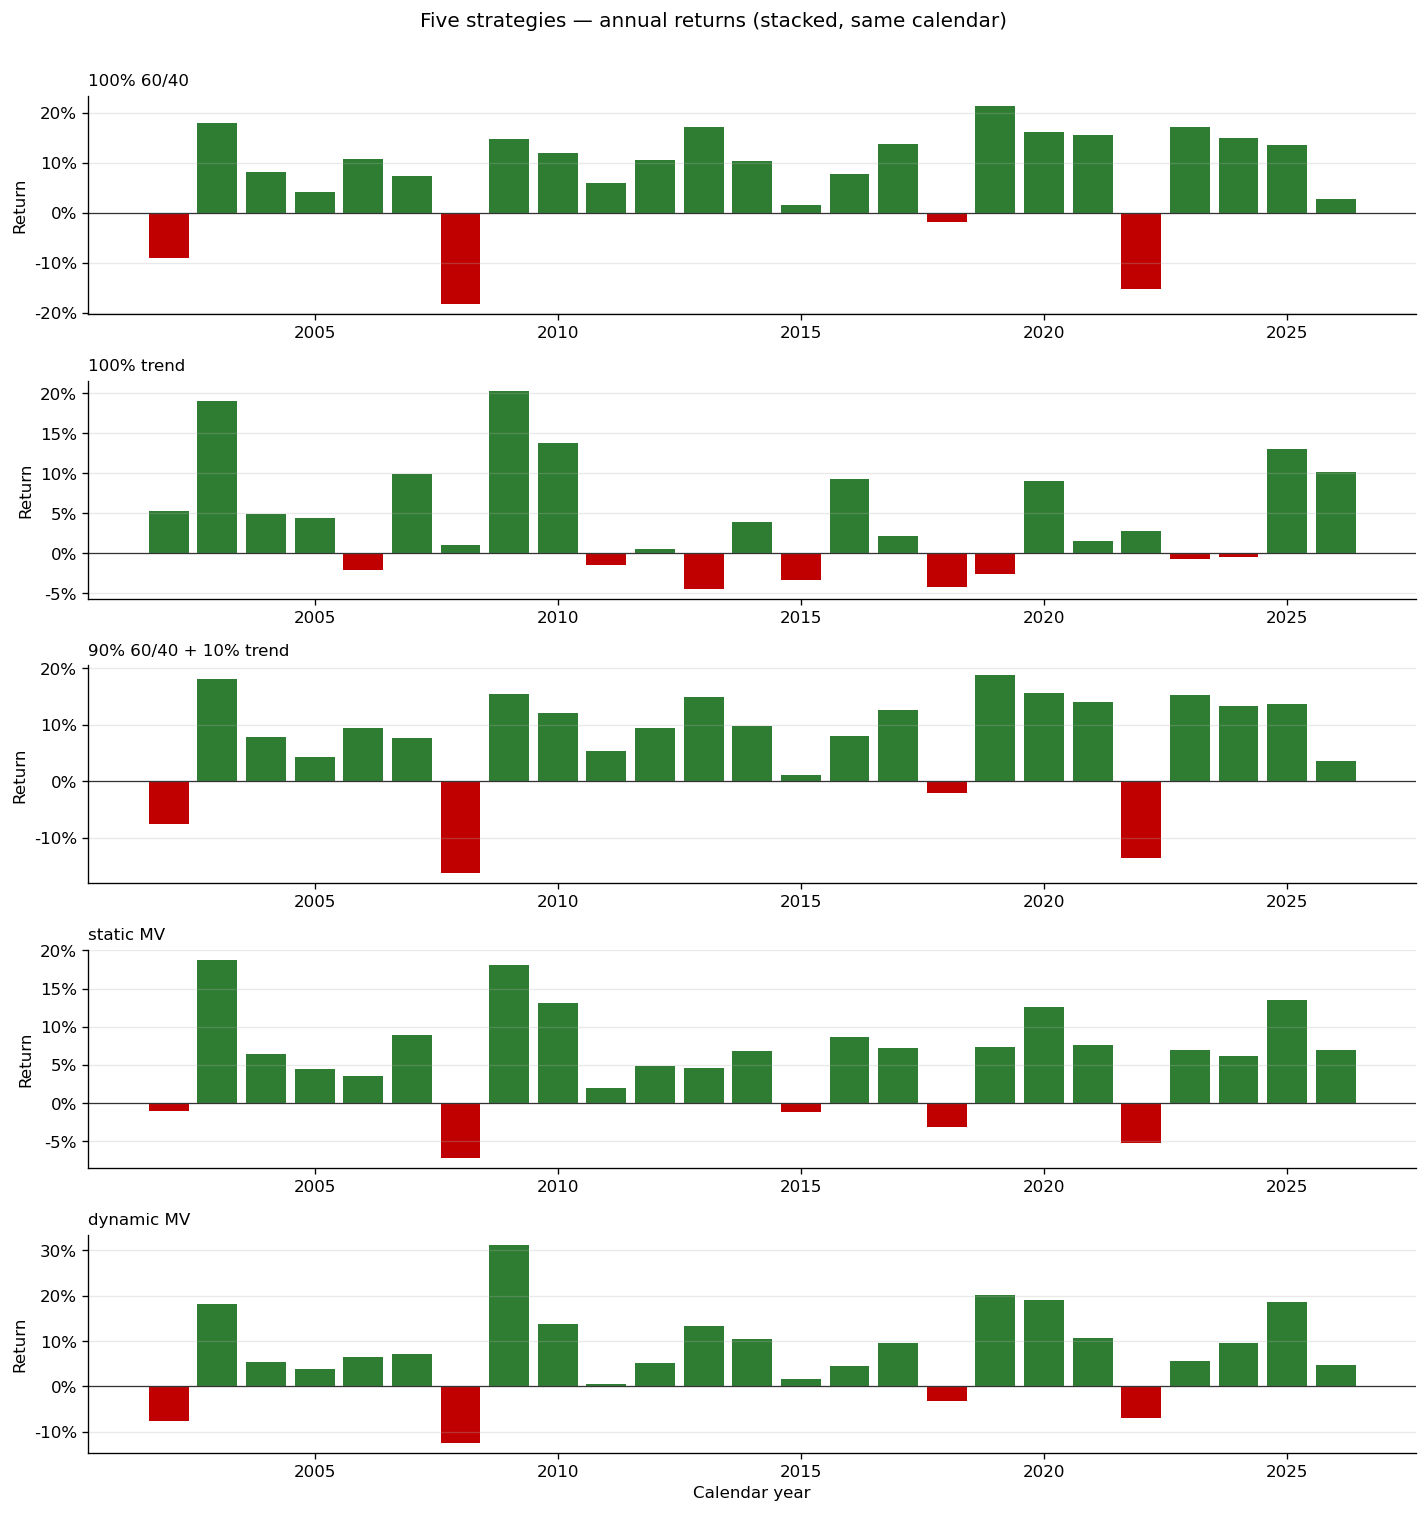

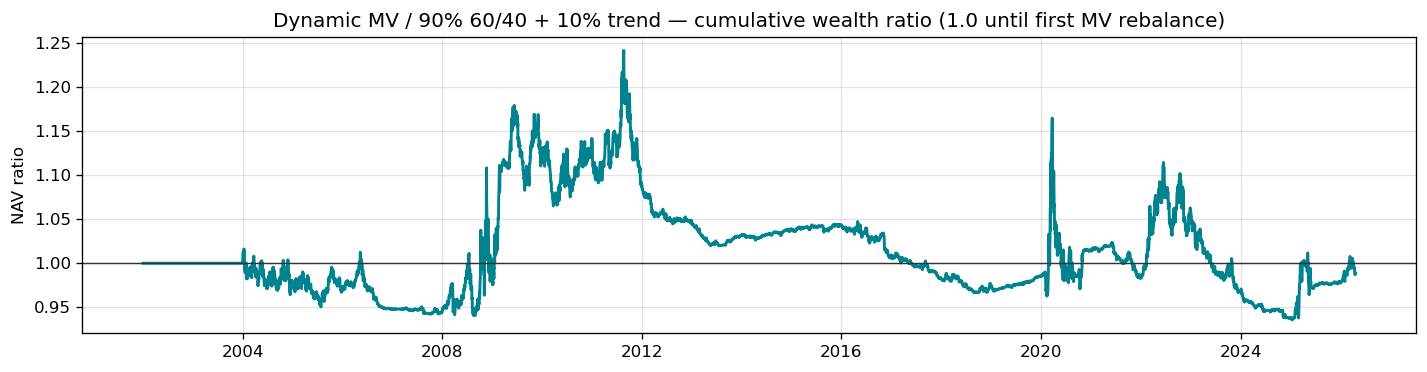

NAV ratio dynamic/sleeve at end: 0.9883 (-1.17% vs sleeve).  Range over sample: 0.9358 → 1.2411
90% 60/40 + 10% trend vs 100% 60/40 (Sharpe, this window): +0.04.  dynamic MV vs static MV: +0.03.  Avg monthly |Δw_T| for dynamic MV: 0.088.
Caveats: long-only only; no costs; static MV uses full-sample moments (in-sample). dynamic MV earns the same returns as the 90/10 sleeve until the first rolling MV weight after warm-up.


In [16]:


# Section 3.4 — five strategies on one calendar (dynamic MV = 90/10 sleeve until first rolling MV rebalance)
rets_five = {
    S_6040: r_bench.reindex(oos_index),
    S_TREND: r_trend.reindex(oos_index),
    S_MIX: mix_10.reindex(oos_index),
    S_STATIC_MV: mix_static_lo.reindex(oos_index),
    S_DYNAMIC_MV: dyn_tan_ret.reindex(oos_index),
}

stats_five = [
    summary_stats(S_6040, rets_five[S_6040], w_T=0.0),
    summary_stats(S_TREND, rets_five[S_TREND], w_T=1.0),
    summary_stats(S_MIX, rets_five[S_MIX], w_T=W_T_SLEEVE),
    summary_stats(S_STATIC_MV, rets_five[S_STATIC_MV], w_T=float(w_lo[0])),
    summary_stats(S_DYNAMIC_MV, rets_five[S_DYNAMIC_MV], w_T=None),
]

tbl_five = summary_table(stats_five)
display(tbl_five)
tbl_five.to_csv(OUTPUT_DIR / "part3_five_strategies_summary.csv", index=False)
print("Saved part3_five_strategies_summary.csv")

ret_ordered = {k: rets_five[k] for k in STRATEGY_ORDER}
cols = {k: STRATEGY_COLORS[k] for k in STRATEGY_ORDER}

plot_nav(ret_ordered, "Five strategies — NAV (same calendar)", colors=cols)
plot_stacked_drawdowns(ret_ordered, "Five strategies — drawdown (stacked, same calendar)")
plot_stacked_annual_returns(ret_ordered, "Five strategies — annual returns (stacked, same calendar)")

# Absolute NAV can look almost identical when terminal wealth differs by only ~1%; ratio makes the path visible.
nav_sleeve = daily_to_nav(rets_five[S_MIX].dropna(), INITIAL_AUM)
nav_dyn_only = daily_to_nav(rets_five[S_DYNAMIC_MV].dropna(), INITIAL_AUM)
nav_both = pd.concat([nav_dyn_only.rename("dyn"), nav_sleeve.rename("mix")], axis=1, join="inner").dropna()
ratio = nav_both["dyn"] / nav_both["mix"]
fig, ax = plt.subplots(figsize=(12, 3.2))
fig.patch.set_facecolor("white")
ax.plot(ratio.index, ratio.values, color=STRATEGY_COLORS[S_DYNAMIC_MV], linewidth=1.75)
ax.axhline(1.0, color="#333333", linewidth=0.85)
ax.set_title(
    "Dynamic MV / 90% 60/40 + 10% trend — cumulative wealth ratio (1.0 until first MV rebalance)"
)
ax.set_ylabel("NAV ratio")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()
print(
    f"NAV ratio dynamic/sleeve at end: {ratio.iloc[-1]:.4f} ({100.0 * (ratio.iloc[-1] - 1.0):+.2f}% vs sleeve).  "
    f"Range over sample: {ratio.min():.4f} → {ratio.max():.4f}"
)

# Quick deltas on the same window (labels match the table columns)
i60, imix, ist, idyn = 0, 2, 3, 4
d_sleeve = stats_five[imix]["Sharpe ratio, rf=0"] - stats_five[i60]["Sharpe ratio, rf=0"]
d_dyn = stats_five[idyn]["Sharpe ratio, rf=0"] - stats_five[ist]["Sharpe ratio, rf=0"]
print(
    f"{S_MIX} vs {S_6040} (Sharpe, this window): {d_sleeve:+.2f}.  "
    f"{S_DYNAMIC_MV} vs {S_STATIC_MV}: {d_dyn:+.2f}.  "
    f"Avg monthly |Δw_T| for {S_DYNAMIC_MV}: {mo_diff_tan:.3f}."
)
print(
    "Caveats: long-only only; no costs; static MV uses full-sample moments (in-sample). "
    "dynamic MV earns the same returns as the 90/10 sleeve until the first rolling MV weight after warm-up."
)


# 

## Part 4 — Trend model performance in large 60/40 drawdowns

How Method 1 (trend) behaves when 60/40 is in material drawdown, measured with conditional statistics rather than a contemporaneous correlation of the two drawdown series. (Underwater equity \(DD_t = NAV_t / \max_{s\le t} NAV_s - 1\) is path-dependent and strongly autocorrelated, so \(\rho(DD_{\text{trend}}, DD_{60/40})\) mostly reflects calendar overlap of recovery legs.)

Four lenses, all standalone trend vs 60/40 on the same aligned calendar as Parts 1-3:

1. Episode catalogue — discrete peak → trough → (recovery) cycles on 60/40 NAV; flag episodes ≥ 5% and ≥ 10%; trend returns and risk inside each episode.
2. Quantile windows — worst 10% / 20% of trailing 21d, 63d, and calendar-month 60/40 returns; trend stats in tail vs rest.
3. Drawdown-depth buckets — each day bucketed by the current 60/40 DD depth; conditional trend mean / vol / Sharpe.
4. Asymmetric capture and dual-\(\beta\) — trend on bench down vs up days; piecewise linear regression \(r_T = \alpha + \beta^+ r_B \mathbf 1\{r_B>0\} + \beta^- r_B \mathbf 1\{r_B<0\}\) with HC1 SEs.

Outputs: `part4_60_40_drawdown_episodes.csv`, `part4_quantile_window_returns.csv`, `part4_dd_depth_buckets.csv` in `Notebooks/output/`.


In [17]:
# Part 4.1 — Episode catalogue (60/40 peak → trough → recovery)
# Requires: merged, r_bench, r_trend, drawdown_series, daily_to_nav, OUTPUT_DIR, TRADING_DAYS

THRESH_EPISODE = 0.05  # include episodes with depth >= 5%
THRESH_LARGE = 0.10  # highlight / label "large" at >= 10%


def cum_ret_from_daily(r: pd.Series) -> float:
    s = r.dropna()
    if s.empty:
        return float("nan")
    return float((1.0 + s).prod() - 1.0)


def find_drawdown_episodes(nav: pd.Series, depth_threshold: float = THRESH_EPISODE) -> pd.DataFrame:
    """Peak/trough/recovery cycles on bench NAV; depth is negative (e.g. -0.15)."""
    dd = drawdown_series(nav)
    in_dd = False
    rows: list[dict] = []
    peak_dt = trough_dt = None
    trough_val = 0.0
    for t in dd.index:
        x = float(dd.loc[t])
        if not in_dd:
            if x < -1e-15:
                in_dd = True
                peak_dt = nav.loc[:t].idxmax()
                trough_dt = t
                trough_val = x
        else:
            if x < trough_val:
                trough_dt = t
                trough_val = x
            if x >= -1e-15:
                if -trough_val >= depth_threshold:
                    rows.append(
                        {
                            "peak": peak_dt,
                            "trough": trough_dt,
                            "recovery": t,
                            "depth_60_40": trough_val,
                        }
                    )
                in_dd = False
    if in_dd and peak_dt is not None and -trough_val >= depth_threshold:
        rows.append(
            {
                "peak": peak_dt,
                "trough": trough_dt,
                "recovery": pd.NaT,
                "depth_60_40": trough_val,
            }
        )
    return pd.DataFrame(rows)


def enrich_episodes(ep: pd.DataFrame, r_b: pd.Series, r_t: pd.Series) -> pd.DataFrame:
    out_rows = []
    for _, row in ep.iterrows():
        pk, tr, rc = row["peak"], row["trough"], row["recovery"]
        rb_pt = cum_ret_from_daily(r_b.loc[pk:tr])
        rb_pr = cum_ret_from_daily(r_b.loc[pk:rc]) if pd.notna(rc) else float("nan")
        rt_pt = cum_ret_from_daily(r_t.loc[pk:tr])
        rt_pr = cum_ret_from_daily(r_t.loc[pk:rc]) if pd.notna(rc) else float("nan")

        sub_nav_t = daily_to_nav(r_t.loc[pk:tr])
        dd_t_sub = drawdown_series(sub_nav_t)
        trend_max_dd_pt = float(dd_t_sub.min()) if len(dd_t_sub) else float("nan")
        hit_pt = float((r_t.loc[pk:tr].dropna() > 0.0).mean()) if len(r_t.loc[pk:tr].dropna()) else float("nan")

        n_pt = int(r_b.loc[pk:tr].shape[0])
        n_pr = int(r_b.loc[pk:rc].shape[0]) if pd.notna(rc) else np.nan

        out_rows.append(
            {
                "peak_date": pk,
                "trough_date": tr,
                "recovery_date": rc,
                "depth_60_40": row["depth_60_40"],
                "large_ge_10pct": bool(row["depth_60_40"] <= -THRESH_LARGE),
                "len_peak_to_trough_days": n_pt,
                "len_peak_to_recovery_days": n_pr,
                "bench_ret_peak_to_trough": rb_pt,
                "bench_ret_peak_to_recovery": rb_pr,
                "trend_ret_peak_to_trough": rt_pt,
                "trend_ret_peak_to_recovery": rt_pr,
                "trend_max_dd_peak_to_trough": trend_max_dd_pt,
                "trend_hit_rate_peak_to_trough": hit_pt,
            }
        )
    return pd.DataFrame(out_rows)


bench_nav_p4 = daily_to_nav(r_bench.dropna())
episodes_raw = find_drawdown_episodes(bench_nav_p4, depth_threshold=THRESH_EPISODE)
episodes_tbl = enrich_episodes(episodes_raw, r_bench, r_trend)
episodes_tbl = episodes_tbl.sort_values("depth_60_40", ascending=True).reset_index(drop=True)

ep_path = OUTPUT_DIR / "part4_60_40_drawdown_episodes.csv"
episodes_tbl.to_csv(ep_path, index=False)
print("Saved", ep_path)

# Styled display: highlight episodes with depth >= 10%
_disp = episodes_tbl.copy()
for c in ("peak_date", "trough_date", "recovery_date"):
    _disp[c] = _disp[c].apply(lambda x: x.strftime("%Y-%m-%d") if pd.notna(x) else "—")


def _hl_large_ge10(row):
    styles = [""] * len(row)
    if row.get("large_ge_10pct", False):
        styles = ["background-color: #FFF2CC"] * len(row)
    return styles


display(_disp.style.apply(_hl_large_ge10, axis=1).format(na_rep="—"))


Saved /Users/jimmyzheng0516/Desktop/Project Labs/LTCM_sp_2026/Notebooks/output/part4_60_40_drawdown_episodes.csv


,peak_date,trough_date,recovery_date,depth_60_40,large_ge_10pct,len_peak_to_trough_days,len_peak_to_recovery_days,bench_ret_peak_to_trough,bench_ret_peak_to_recovery,trend_ret_peak_to_trough,trend_ret_peak_to_recovery,trend_max_dd_peak_to_trough,trend_hit_rate_peak_to_trough
0,2007-10-09,2009-03-09,2010-10-18,-0.326833,True,370,790,-0.323601,0.007289,0.048834,0.384516,-0.159334,0.437838
1,2021-12-27,2022-10-14,2024-01-25,-0.198909,True,210,544,-0.192006,0.008815,0.030458,0.003881,-0.111226,0.414286
2,2020-02-19,2020-03-23,2020-06-05,-0.194961,True,24,78,-0.192866,0.003121,-0.006820,0.027707,-0.032358,0.583333
3,2002-03-06,2002-07-23,2003-06-16,-0.180953,True,100,334,-0.174371,0.013108,0.005567,0.169912,-0.026879,0.420000
4,2018-09-21,2018-12-24,2019-03-15,-0.111162,True,67,126,-0.111133,0.000389,-0.021410,-0.020398,-0.029251,0.402985
5,2025-02-19,2025-04-08,2025-06-10,-0.109181,True,35,80,-0.107490,0.003369,-0.041138,0.007745,-0.055526,0.514286
6,2011-07-22,2011-08-08,2012-01-03,-0.092897,False,12,118,-0.091621,0.006383,-0.019596,-0.064066,-0.028703,0.416667
7,2015-05-21,2015-08-25,2015-10-28,-0.069056,False,69,115,-0.066561,0.003668,-0.019415,-0.021170,-0.032005,0.086957
8,2015-12-01,2016-02-11,2016-03-29,-0.065316,False,53,86,-0.057922,0.009992,0.021970,0.058998,-0.024984,0.490566
9,2018-01-26,2018-02-08,2018-07-25,-0.064834,False,10,129,-0.059053,0.007188,-0.035112,-0.040185,-0.034855,0.100000


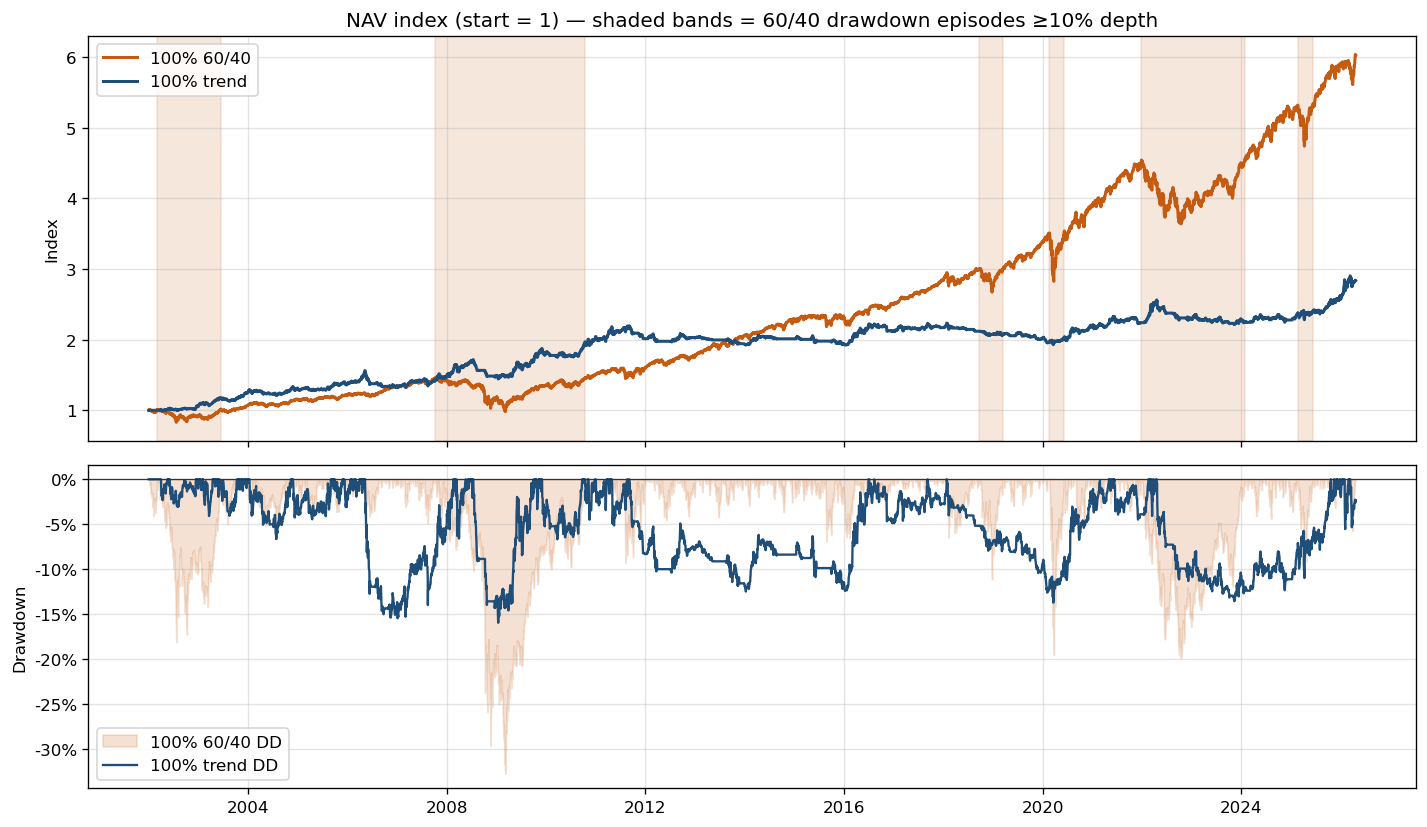

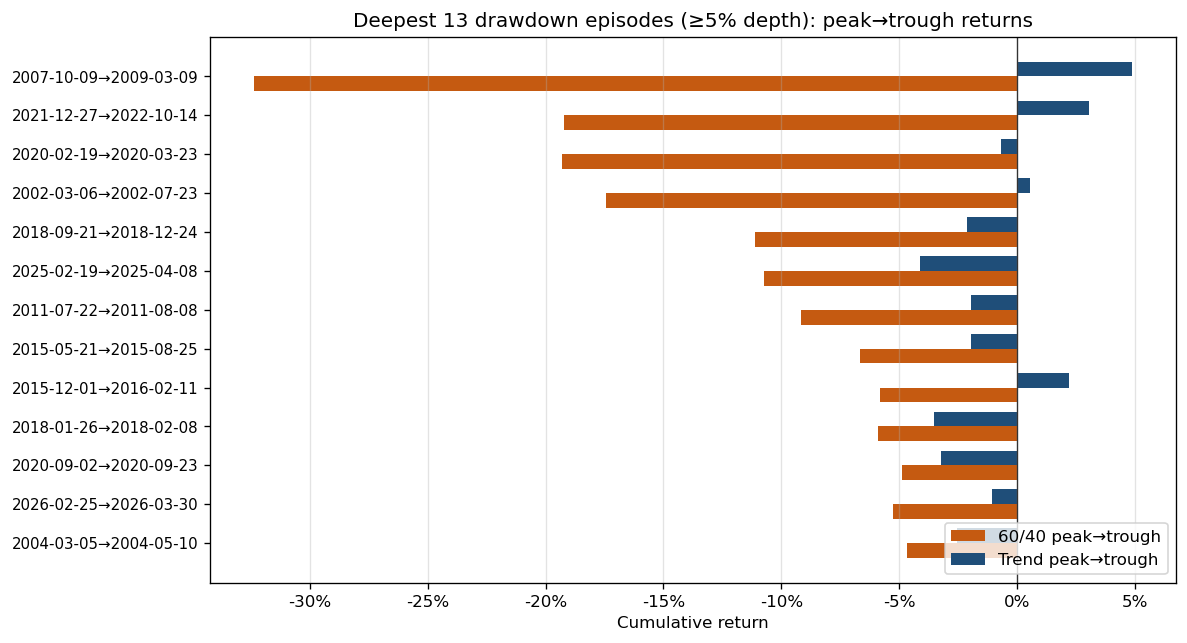

In [18]:
# Part 4.2 — NAV + drawdown with shaded large (>=10%) episodes; paired peak→trough bars

nav_b_idx = daily_to_nav(r_bench.dropna()) / INITIAL_AUM
nav_t_idx = daily_to_nav(r_trend.dropna()) / INITIAL_AUM
aligned_nav = pd.concat([nav_b_idx.rename("bench"), nav_t_idx.rename("trend")], axis=1, join="inner")

dd_b_full = drawdown_series(daily_to_nav(r_bench.dropna()))
dd_t_full = drawdown_series(daily_to_nav(r_trend.dropna()))
aligned_dd = pd.concat([dd_b_full.rename("bench_dd"), dd_t_full.rename("trend_dd")], axis=1, join="inner")

large_eps = episodes_tbl[episodes_tbl["large_ge_10pct"]].copy()

fig, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [1.25, 1]},
)
fig.patch.set_facecolor("white")

for _, er in large_eps.iterrows():
    pk, rc = er["peak_date"], er["recovery_date"]
    right = rc if pd.notna(rc) else aligned_nav.index[-1]
    ax_top.axvspan(pk, right, color=PART3_COLORS["BENCH"], alpha=0.14)

ax_top.plot(aligned_nav.index, aligned_nav["bench"].values, color=PART3_COLORS["BENCH"], linewidth=1.8, label=S_6040)
ax_top.plot(aligned_nav.index, aligned_nav["trend"].values, color=PART3_COLORS["TREND"], linewidth=1.8, label=S_TREND)
ax_top.set_title("NAV index (start = 1) — shaded bands = 60/40 drawdown episodes ≥10% depth")
ax_top.set_ylabel("Index")
ax_top.legend(loc="upper left")
ax_top.grid(True, alpha=0.35)

ax_bot.fill_between(aligned_dd.index, aligned_dd["bench_dd"].values, 0.0, alpha=0.18, color=PART3_COLORS["BENCH"], label=f"{S_6040} DD")
ax_bot.plot(aligned_dd.index, aligned_dd["trend_dd"].values, color=PART3_COLORS["TREND"], linewidth=1.4, label=f"{S_TREND} DD")
ax_bot.axhline(0.0, color="#333333", linewidth=0.75)
ax_bot.set_ylabel("Drawdown")
ax_bot.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax_bot.legend(loc="lower left")
ax_bot.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# Horizontal paired bars: deepest episodes (>=5% list), top 14 by depth
top_n = min(14, len(episodes_tbl))
sub = episodes_tbl.iloc[:top_n].iloc[::-1]  # shallow at bottom, deep at top for barh
labels = [f'{row["peak_date"].strftime("%Y-%m-%d")}→{row["trough_date"].strftime("%Y-%m-%d")}' for _, row in sub.iterrows()]
y = np.arange(len(sub))
w = 0.38
fig2, ax2 = plt.subplots(figsize=(10, max(4.0, 0.42 * len(sub))))
fig2.patch.set_facecolor("white")
ax2.barh(y - w / 2, sub["bench_ret_peak_to_trough"].values, height=w, color=PART3_COLORS["BENCH"], label="60/40 peak→trough")
ax2.barh(y + w / 2, sub["trend_ret_peak_to_trough"].values, height=w, color=PART3_COLORS["TREND"], label="Trend peak→trough")
ax2.axvline(0.0, color="#333333", linewidth=0.8)
ax2.set_yticks(y)
ax2.set_yticklabels(labels, fontsize=9)
ax2.set_xlabel("Cumulative return")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax2.set_title(f"Deepest {top_n} drawdown episodes (≥{THRESH_EPISODE:.0%} depth): peak→trough returns")
ax2.legend(loc="lower right")
ax2.grid(True, axis="x", alpha=0.35)
plt.tight_layout()
plt.show()


### Part 4.3 — 21d / 63d stress tests (matched cumulative returns)

Identify dates in the worst 10% / 20% of 60/40 trailing compounded returns over 21 or 63 trading days, and compute trend's compounded return over the same trailing window on the same dates. The tables and charts always pair cumulative-to-cumulative on matched dates so the comparison stays in the same horizon and units.


Saved /Users/jimmyzheng0516/Desktop/Project Labs/LTCM_sp_2026/Notebooks/output/part4_quantile_window_returns.csv


,horizon,bucket,quantile_cutoff_q,n_windows,bench_window_threshold,bench_window_mean,bench_window_median,trend_window_mean,trend_window_median,excess_window_mean_t_minus_b,trend_window_hit_rate_pos,trend_ann_vol_monthly,trend_sharpe_rf0_monthly
0,21d_trailing,worst 10%,0.1,632,-0.025746,-0.047610,-0.038808,-0.004368,-0.003036,0.043242,0.349684,NaN,NaN
1,21d_trailing,rest,0.1,5687,-0.025746,0.012216,0.012188,0.004524,0.001069,-0.007692,0.531036,NaN,NaN
2,63d_trailing,worst 10%,0.1,628,-0.036196,-0.069386,-0.056357,0.002145,-0.001948,0.071531,0.472930,NaN,NaN
3,63d_trailing,rest,0.1,5649,-0.036196,0.028714,0.028758,0.012033,0.004452,-0.016681,0.561869,NaN,NaN
4,21d_trailing,worst 20%,0.2,1264,-0.011169,-0.032689,-0.025748,-0.002779,-0.002203,0.029911,0.366297,NaN,NaN
5,21d_trailing,rest,0.2,5055,-0.011169,0.015964,0.014385,0.005238,0.001753,-0.010726,0.549555,NaN,NaN
6,63d_trailing,worst 20%,0.2,1256,-0.010581,-0.045884,-0.036197,0.001922,-0.003059,0.047806,0.445064,NaN,NaN
7,63d_trailing,rest,0.2,5021,-0.010581,0.035105,0.032348,0.013326,0.005721,-0.021779,0.579964,NaN,NaN
8,calendar_month,worst 10%,0.1,30,-0.025913,-0.044251,-0.037918,-0.004011,-0.000343,0.040240,0.366667,0.071044,-0.677452
9,calendar_month,rest,0.1,262,-0.025913,0.012306,0.011765,0.004695,0.000631,-0.007611,0.511450,0.074227,0.759098


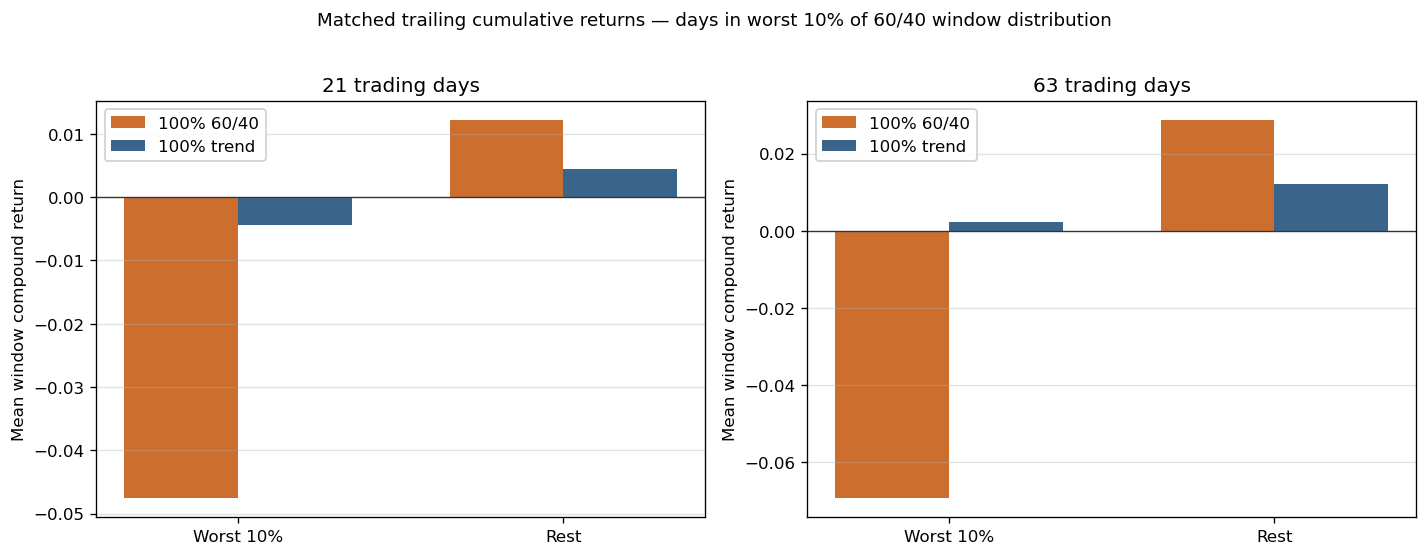

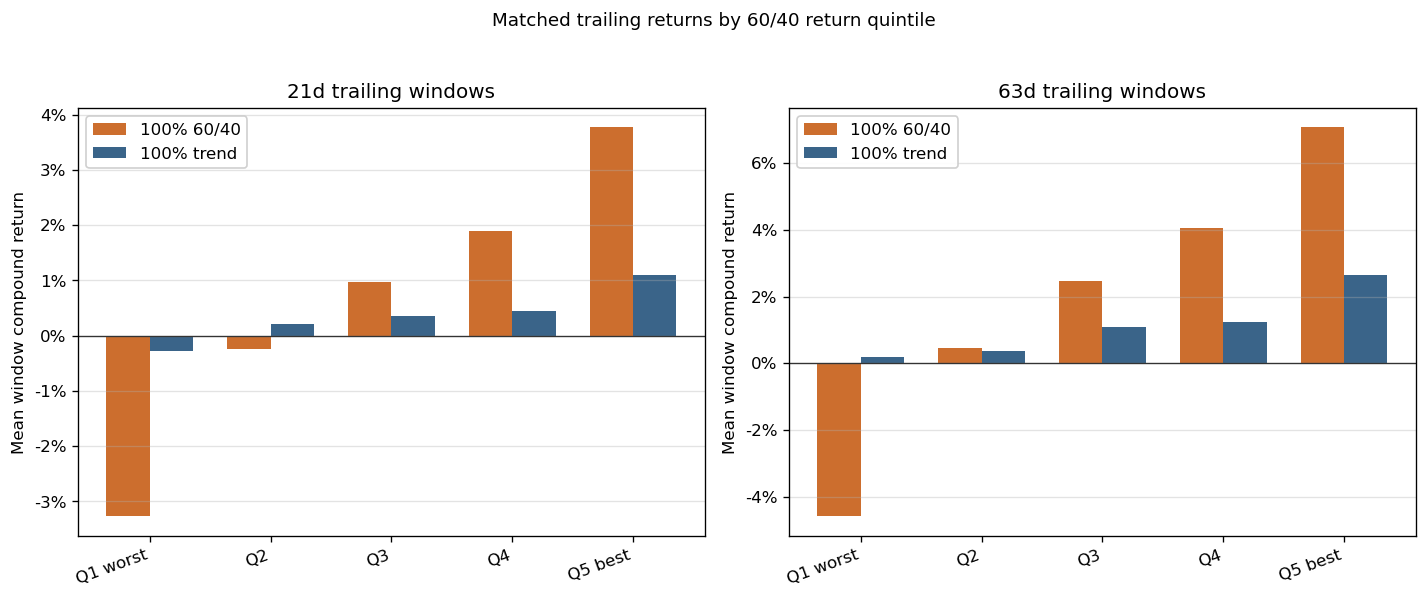

In [19]:
# Part 4.3 — Matched trailing windows (stress tests)
# Same calendar dates: 60/40 and trend each use trailing compounded return over 21 or 63 trading days.
# Worst 10% / 20% buckets are defined on the *60/40* trailing distribution; trend is evaluated on
# that same end-of-day window (cumulative-to-cumulative — not benchmark window vs trend daily mean).


def rolling_compound_return(r: pd.Series, win: int, min_periods: int | None = None) -> pd.Series:
    mp = min_periods if min_periods is not None else win
    return (1.0 + r).rolling(win, min_periods=mp).apply(np.prod, raw=True) - 1.0


def matched_trailing_window_stats(
    bench_roll: pd.Series, trend_roll: pd.Series, q: float, label: str
) -> list[dict]:
    """bench_roll / trend_roll: same-index trailing compound returns for 60/40 and trend."""
    df = pd.concat([bench_roll.rename("bench_window"), trend_roll.rename("trend_window")], axis=1).dropna()
    if df.empty:
        return []
    thr = float(df["bench_window"].quantile(q))
    worst = df["bench_window"] <= thr
    rest = df["bench_window"] > thr
    rows: list[dict] = []

    def one(mask: pd.Series, name: str) -> dict:
        sub = df.loc[mask]
        if len(sub) == 0:
            return {
                "horizon": label,
                "bucket": name,
                "quantile_cutoff_q": q,
                "n_windows": 0,
                "bench_window_threshold": thr,
                "bench_window_mean": np.nan,
                "bench_window_median": np.nan,
                "trend_window_mean": np.nan,
                "trend_window_median": np.nan,
                "excess_window_mean_t_minus_b": np.nan,
                "trend_window_hit_rate_pos": np.nan,
            }
        b_w = sub["bench_window"]
        t_w = sub["trend_window"]
        return {
            "horizon": label,
            "bucket": name,
            "quantile_cutoff_q": q,
            "n_windows": int(len(sub)),
            "bench_window_threshold": thr,
            "bench_window_mean": float(b_w.mean()),
            "bench_window_median": float(b_w.median()),
            "trend_window_mean": float(t_w.mean()),
            "trend_window_median": float(t_w.median()),
            "excess_window_mean_t_minus_b": float((t_w - b_w).mean()),
            "trend_window_hit_rate_pos": float((t_w > 0.0).mean()),
        }

    rows.append(one(worst, f"worst {q:.0%}"))
    rows.append(one(rest, "rest"))
    return rows


rb = r_bench.dropna()
rt = r_trend.reindex(rb.index).dropna()
aligned = pd.concat([rb.rename("B"), rt.rename("T")], axis=1, join="inner")

roll21_b = rolling_compound_return(aligned["B"], 21).reindex(aligned.index)
roll21_t = rolling_compound_return(aligned["T"], 21).reindex(aligned.index)
roll63_b = rolling_compound_return(aligned["B"], 63).reindex(aligned.index)
roll63_t = rolling_compound_return(aligned["T"], 63).reindex(aligned.index)

rows_q: list[dict] = []
for q in (0.10, 0.20):
    rows_q.extend(matched_trailing_window_stats(roll21_b, roll21_t, q, "21d_trailing"))
    rows_q.extend(matched_trailing_window_stats(roll63_b, roll63_t, q, "63d_trailing"))

# Monthly — matched calendar-month compound returns for 60/40 and trend
mb = aligned["B"].resample("ME").apply(lambda x: (1.0 + x).prod() - 1.0)
mt = aligned["T"].resample("ME").apply(lambda x: (1.0 + x).prod() - 1.0)
mo = pd.concat([mb.rename("bench_window"), mt.rename("trend_window")], axis=1).dropna()

for q in (0.10, 0.20):
    thr_m = float(mo["bench_window"].quantile(q))
    worst_m = mo["bench_window"] <= thr_m
    rest_m = mo["bench_window"] > thr_m
    for name, mask in ((f"worst {q:.0%}", worst_m), ("rest", rest_m)):
        sub = mo.loc[mask]
        n_w = int(len(sub))
        b_w = sub["bench_window"]
        t_w = sub["trend_window"]
        vol_m = float(t_w.std() * np.sqrt(12)) if n_w > 1 else np.nan
        mu_t = float(t_w.mean()) if n_w else np.nan
        sh_m = (mu_t * 12) / vol_m if vol_m and vol_m > 0 else np.nan
        xs = float((t_w - b_w).mean()) if n_w else np.nan
        rows_q.append(
            {
                "horizon": "calendar_month",
                "bucket": name,
                "quantile_cutoff_q": q,
                "n_windows": n_w,
                "bench_window_threshold": thr_m,
                "bench_window_mean": float(b_w.mean()) if n_w else np.nan,
                "bench_window_median": float(b_w.median()) if n_w else np.nan,
                "trend_window_mean": mu_t,
                "trend_window_median": float(t_w.median()) if n_w else np.nan,
                "excess_window_mean_t_minus_b": xs,
                "trend_window_hit_rate_pos": float((t_w > 0.0).mean()) if n_w else np.nan,
                "trend_ann_vol_monthly": vol_m,
                "trend_sharpe_rf0_monthly": float(sh_m),
            }
        )

quant_tbl = pd.DataFrame(rows_q)
qpath = OUTPUT_DIR / "part4_quantile_window_returns.csv"
quant_tbl.to_csv(qpath, index=False)
print("Saved", qpath)
display(quant_tbl)

# Worst 10% vs rest — mean *matched* window cumulative return: 60/40 vs trend


def plot_stress_matched_panels(tbl: pd.DataFrame, q_use: float = 0.10) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.patch.set_facecolor("white")
    fig.suptitle(
        f"Matched trailing cumulative returns — days in worst {q_use:.0%} of 60/40 window distribution",
        fontsize=11,
        y=1.02,
    )
    w = 0.35
    for ax, horizon, ttl in zip(
        axes,
        ("21d_trailing", "63d_trailing"),
        ("21 trading days", "63 trading days"),
    ):
        sub = tbl[(tbl["horizon"] == horizon) & (tbl["quantile_cutoff_q"] == q_use)].copy()
        if sub.empty:
            continue
        sub = sub.set_index("bucket").reindex([f"worst {q_use:.0%}", "rest"])
        x = np.arange(2)
        ax.bar(
            x - w / 2,
            sub["bench_window_mean"].values,
            w,
            label=S_6040,
            color=PART3_COLORS["BENCH"],
            alpha=0.88,
        )
        ax.bar(
            x + w / 2,
            sub["trend_window_mean"].values,
            w,
            label=S_TREND,
            color=PART3_COLORS["TREND"],
            alpha=0.88,
        )
        ax.set_xticks(x)
        ax.set_xticklabels([f"Worst {q_use:.0%}", "Rest"])
        ax.axhline(0.0, color="#333333", linewidth=0.8)
        ax.set_ylabel("Mean window compound return")
        ax.set_title(ttl)
        ax.grid(True, axis="y", alpha=0.35)
        ax.legend(loc="best", framealpha=0.92)
    plt.tight_layout()
    plt.show()


plot_stress_matched_panels(quant_tbl, 0.10)

# Quintiles — mean *matched* trailing cumulative 60/40 and trend by 60/40 window quintile


def quintile_means_matched_both(bench_roll: pd.Series, trend_roll: pd.Series) -> pd.DataFrame:
    df = pd.concat([bench_roll.rename("B"), trend_roll.rename("T")], axis=1).dropna()
    rk = df["B"].rank(method="first")
    df["q5"] = pd.qcut(rk, 5, labels=["Q1 worst", "Q2", "Q3", "Q4", "Q5 best"])
    return df.groupby("q5", observed=True)[["B", "T"]].mean()


q21_both = quintile_means_matched_both(roll21_b, roll21_t)
q63_both = quintile_means_matched_both(roll63_b, roll63_t)


def plot_quintile_matched_bars(ax, q_tbl: pd.DataFrame, title: str) -> None:
    x = np.arange(len(q_tbl))
    width = 0.36
    ax.bar(
        x - width / 2,
        q_tbl["B"].values,
        width,
        label=S_6040,
        color=PART3_COLORS["BENCH"],
        alpha=0.88,
    )
    ax.bar(
        x + width / 2,
        q_tbl["T"].values,
        width,
        label=S_TREND,
        color=PART3_COLORS["TREND"],
        alpha=0.88,
    )
    ax.axhline(0.0, color="#333333", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(q_tbl.index.astype(str).tolist(), rotation=20, ha="right")
    ax.set_ylabel("Mean window compound return")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.35)
    ax.legend(loc="best", framealpha=0.92)


fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(12, 4.8))
fig.patch.set_facecolor("white")
plot_quintile_matched_bars(ax_a, q21_both, "21d trailing windows")
plot_quintile_matched_bars(ax_b, q63_both, "63d trailing windows")
fig.suptitle("Matched trailing returns by 60/40 return quintile", fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


Saved /Users/jimmyzheng0516/Desktop/Project Labs/LTCM_sp_2026/Notebooks/output/part4_dd_depth_buckets.csv


,bucket,n_days,bench_dd_range_mid_approx,trend_ann_mean_from_daily,trend_ann_vol,trend_sharpe_rf0,trend_hit_rate_pos,bench_mean_daily
0,<= -20%,146,-0.228594,-0.119811,0.094091,-1.273349,0.390411,-0.001545
1,"(-20%, -10%]",566,-0.130047,0.050646,0.080656,0.627926,0.439929,-0.000022
2,"(-10%, -5%]",769,-0.070525,0.021652,0.082405,0.262748,0.470741,-0.000463
3,"(-5%, 0]",4858,-0.006331,0.051601,0.066711,0.773499,0.454096,0.000523
4,> 0 (noise),0,NaN,NaN,NaN,NaN,NaN,NaN


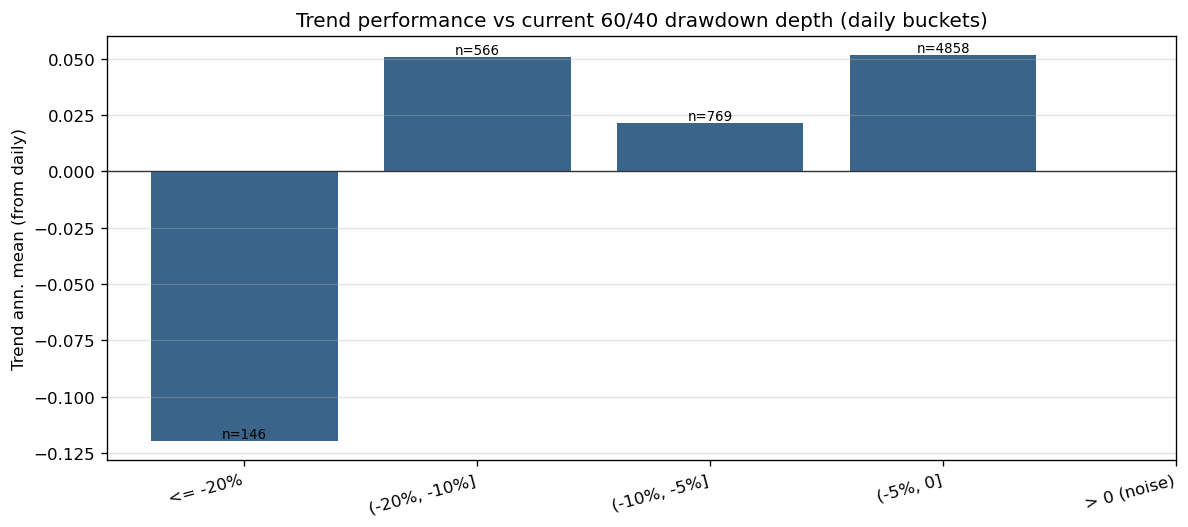

In [20]:
# Part 4.4 — Drawdown-depth buckets (current 60/40 underwater level)

nav_b_aligned = daily_to_nav(aligned["B"])
dd_b_daily = drawdown_series(nav_b_aligned)

bins = [-np.inf, -0.20, -0.10, -0.05, 0.0, np.inf]
bucket_labels = ["<= -20%", "(-20%, -10%]", "(-10%, -5%]", "(-5%, 0]", "> 0 (noise)"]
bucket_cat = pd.cut(dd_b_daily.astype(float), bins=bins, labels=bucket_labels, include_lowest=True)

dbd = pd.DataFrame({"dd_bench": dd_b_daily, "trend_r": aligned["T"], "bucket": bucket_cat}).dropna(subset=["trend_r"])

rows_bucket = []
for lab in bucket_labels:
    sel = dbd.loc[dbd["bucket"] == lab, "trend_r"]
    bench_sel = dbd.loc[dbd["bucket"] == lab, "dd_bench"]
    n = int(sel.shape[0])
    if n == 0:
        rows_bucket.append(
            {
                "bucket": lab,
                "n_days": 0,
                "bench_dd_range_mid_approx": np.nan,
                "trend_ann_mean_from_daily": np.nan,
                "trend_ann_vol": np.nan,
                "trend_sharpe_rf0": np.nan,
                "trend_hit_rate_pos": np.nan,
                "bench_mean_daily": np.nan,
            }
        )
        continue
    mu_d = float(sel.mean())
    vol = float(sel.std() * np.sqrt(TRADING_DAYS))
    sh = (mu_d * TRADING_DAYS) / vol if vol > 0 else float("nan")
    rows_bucket.append(
        {
            "bucket": lab,
            "n_days": n,
            "bench_dd_range_mid_approx": float(bench_sel.median()),
            "trend_ann_mean_from_daily": mu_d * TRADING_DAYS,
            "trend_ann_vol": vol,
            "trend_sharpe_rf0": float(sh),
            "trend_hit_rate_pos": float((sel > 0.0).mean()),
            "bench_mean_daily": float(aligned["B"].reindex(sel.index).mean()),
        }
    )

bucket_tbl = pd.DataFrame(rows_bucket)
bpath = OUTPUT_DIR / "part4_dd_depth_buckets.csv"
bucket_tbl.to_csv(bpath, index=False)
print("Saved", bpath)
display(bucket_tbl)

fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor("white")
x = np.arange(len(bucket_tbl))
bars = ax.bar(x, bucket_tbl["trend_ann_mean_from_daily"].values, color=PART3_COLORS["TREND"], alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels(bucket_tbl["bucket"].tolist(), rotation=15, ha="right")
ax.axhline(0.0, color="#333333", linewidth=0.8)
ax.set_ylabel("Trend ann. mean (from daily)")
ax.set_title("Trend performance vs current 60/40 drawdown depth (daily buckets)")
for i, (_, row) in enumerate(bucket_tbl.iterrows()):
    ax.annotate(f"n={int(row['n_days'])}", xy=(i, row["trend_ann_mean_from_daily"]), ha="center", va="bottom", fontsize=8)
ax.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()


In [21]:
from IPython.display import Markdown, display

# Part 4.5 — Asymmetric capture, dual-beta (HC1 SE), worst 5% tail + takeaway

# `aligned` is built in §4.3; reconstruct here if that cell was skipped (still needs r_bench, r_trend).
if "aligned" not in globals():
    _rb = r_bench.dropna()
    _rt = r_trend.reindex(_rb.index).dropna()
    aligned = pd.concat([_rb.rename("B"), _rt.rename("T")], axis=1, join="inner")

pair = aligned.copy()

if "episodes_tbl" not in globals():
    raise RuntimeError(
        "Missing episodes_tbl — run Part 4 §4.1 (episode catalogue) first, or use Restart Kernel → Run All."
    )

rb_d = pair.loc[pair["B"] < 0, "B"]
rt_d = pair.loc[pair["B"] < 0, "T"]
rb_u = pair.loc[pair["B"] > 0, "B"]
rt_u = pair.loc[pair["B"] > 0, "T"]

mean_b_d = float(rb_d.mean())
mean_b_u = float(rb_u.mean())
mean_t_d = float(rt_d.mean())
mean_t_u = float(rt_u.mean())

down_capture = mean_t_d / mean_b_d if mean_b_d != 0 else float("nan")
up_capture = mean_t_u / mean_b_u if mean_b_u != 0 else float("nan")

print(f"Down-day capture E[r_T|r_B<0] / E[r_B|r_B<0]: {down_capture:.4f}")
print(f"Up-day capture   E[r_T|r_B>0] / E[r_B|r_B>0]: {up_capture:.4f}")

# Worst 5% daily benchmark returns
thr_tail = float(pair["B"].quantile(0.05))
tail_mask = pair["B"] <= thr_tail
print("\nWorst 5% bench days (by daily return):")
print(f"  threshold: bench daily return <= {thr_tail:.6f}")
print(
    f"  n={int(tail_mask.sum())}, trend mean daily={float(pair.loc[tail_mask, 'T'].mean()):.6f}, "
    f"bench mean daily={float(pair.loc[tail_mask, 'B'].mean()):.6f}"
)

# Dual-beta OLS: r_T = α + β+·r_B·1{r_B>0} + β-·r_B·1{r_B<0}
y = pair["T"].to_numpy(dtype=float)
b = pair["B"].to_numpy(dtype=float)
pos = (b > 0).astype(float)
neg = (b < 0).astype(float)
X = np.column_stack([np.ones_like(b), b * pos, b * neg])
beta_hat, *_ = np.linalg.lstsq(X, y, rcond=None)
n_obs, k = X.shape
resid = y - X @ beta_hat
XtX = X.T @ X
try:
    XX_inv = np.linalg.inv(XtX)
except np.linalg.LinAlgError:
    XX_inv = np.linalg.pinv(XtX)
meat = np.zeros((k, k))
for i in range(n_obs):
    xi = X[i]
    meat += (resid[i] ** 2) * np.outer(xi, xi)
V = XX_inv @ meat @ XX_inv * (n_obs / (n_obs - k))
se = np.sqrt(np.clip(np.diag(V), 0.0, np.inf))

print("\nDual-beta OLS with HC1 robust SE:")
print(f"  α  = {beta_hat[0]:.6f}  (SE {se[0]:.6f})")
print(f"  β+ = {beta_hat[1]:.6f}  (SE {se[1]:.6f})")
print(f"  β- = {beta_hat[2]:.6f}  (SE {se[2]:.6f})")

# Episode stats for ≥10% depth
ep10 = episodes_tbl[episodes_tbl["large_ge_10pct"]]
n_ep10 = int(len(ep10))
mean_pt10 = float(ep10["trend_ret_peak_to_trough"].mean()) if n_ep10 else float("nan")
med_pt10 = float(ep10["trend_ret_peak_to_trough"].median()) if n_ep10 else float("nan")
frac_pos10 = float((ep10["trend_ret_peak_to_trough"] > 0).mean()) if n_ep10 else float("nan")

if down_capture < 0.35 and beta_hat[2] < beta_hat[1] - 0.05:
    qual = "more hedge-like than co-moving on benchmark down days"
elif down_capture > 0.9:
    qual = "still largely co-moves with benchmark stress days"
else:
    qual = "partial diversifier — damped but not inverted vs benchmark selloffs"

takeaway_md = (
    f"**Part 4 summary.** {n_ep10} completed or ongoing 60/40 drawdown episodes have depth ≥ 10%. "
    f"Trend's peak-to-trough cumulative return inside those episodes averages {mean_pt10:.2%} "
    f"(median {med_pt10:.2%}) and is positive in {frac_pos10:.0%} of them. "
    f"Across all aligned trading days, trend captures about {down_capture:.2f}x of the benchmark's "
    f"average down-day move vs {up_capture:.2f}x on up-days. "
    f"Dual-beta regression: \u03b2\u207b \u2248 {beta_hat[2]:.3f} when r_B < 0, "
    f"\u03b2\u207a \u2248 {beta_hat[1]:.3f} when r_B > 0 (HC1 SE in stdout). {qual.capitalize()}. "
    f"CSVs: `part4_60_40_drawdown_episodes.csv`, `part4_quantile_window_returns.csv`, `part4_dd_depth_buckets.csv`."
)

display(Markdown(takeaway_md))


Down-day capture E[r_T|r_B<0] / E[r_B|r_B<0]: 0.1150
Up-day capture   E[r_T|r_B>0] / E[r_B|r_B>0]: 0.1717

Worst 5% bench days (by daily return):
  threshold: bench daily return <= -0.010144
  n=317, trend mean daily=-0.001859, bench mean daily=-0.016296

Dual-beta OLS with HC1 robust SE:
  α  = 0.000281  (SE 0.000076)
  β+ = 0.073186  (SE 0.017382)
  β- = 0.135635  (SE 0.019452)


**Part 4 takeaway.** There are **6** completed or ongoing 60/40 drawdown episodes with depth **≥10%**. In each episode’s **peak→trough** window, trend’s cumulative return averages **0.26%** (median **-0.06%**), and is **positive in 50%** of those episodes. Across all aligned trading days, trend captures about **0.11×** of the benchmark’s average **down-day** move vs **0.17×** on **up-days** (ratio of conditional means). A piecewise linear benchmark regression gives **β⁻ ≈ 0.136** when **r_B < 0** vs **β⁺ ≈ 0.073** when **r_B > 0** (HC1 SE in stdout). Qualitatively: **a partial diversifier: damped but not inverted vs benchmark selloffs**. Supporting CSVs: `part4_60_40_drawdown_episodes.csv`, `part4_quantile_window_returns.csv`, `part4_dd_depth_buckets.csv`.

## Part 5 — Trend outperformance vs equity and bond sleeves

How often Method 1 trend beats the equity side and the bond side, outright and risk-adjusted, over month, quarter, and year horizons. Four lenses:

1. Hit rate — frequency of trend outperforming each sleeve.
2. Payoff asymmetry — average win, average loss, payoff ratio.
3. Risk-adjusted quality — same-window realized Sharpe.
4. Regime context — outperformance when equity, bonds, or both are negative.

Reporting uses non-overlapping calendar months, quarters, and years. Active return is trend's compounded return over the calendar period minus the comparator's over the same period. One-month realized Sharpe is noisy; quarterly and yearly Sharpe carry more signal.

In [22]:
# Part 5.1 — Build horizon panels and outperformance statistics

# Use the same aligned calendar as Parts 1–4, dropping the leading seed row if present.
part5 = merged[["method1_strategy_return", "spxt_return", "luattruu_return", "benchmark_strategy_return"]].copy()
part5 = part5.rename(
    columns={
        "method1_strategy_return": "trend",
        "spxt_return": "equity",
        "luattruu_return": "bond",
        "benchmark_strategy_return": "bench60_40",
    }
).dropna(subset=["trend", "equity", "bond"])

if len(part5) > 0 and part5.iloc[0][["trend", "equity", "bond"]].abs().sum() == 0:
    part5 = part5.iloc[1:].copy()

comparators = {"equity": "equity", "bond": "bond"}


def compound_return(x: pd.Series) -> float:
    return float((1.0 + x.dropna()).prod() - 1.0)


def window_sharpe(x: pd.Series) -> float:
    s = x.dropna()
    if len(s) < 2:
        return float("nan")
    vol = float(s.std() * np.sqrt(TRADING_DAYS))
    return float((s.mean() * TRADING_DAYS) / vol) if vol > 0 else float("nan")


def summarize_outperformance(window_df: pd.DataFrame, horizon: str, comparator: str, overlapping: bool) -> dict:
    df = window_df.dropna(subset=["trend_return", "comp_return"]).copy()
    n = int(len(df))
    if n == 0:
        return {
            "horizon": horizon,
            "comparator": comparator,
            "overlapping_windows": overlapping,
            "n_windows": 0,
            "risk_adjusted_n_windows": 0,
            "outright_win_rate": np.nan,
            "risk_adjusted_win_rate": np.nan,
            "median_active_return": np.nan,
            "average_active_return": np.nan,
            "average_win": np.nan,
            "average_loss": np.nan,
            "payoff_ratio_avg_win_abs_loss": np.nan,
            "median_sharpe_spread": np.nan,
            "average_sharpe_spread": np.nan,
        }

    active = df["trend_return"] - df["comp_return"]
    wins = active[active > 0]
    losses = active[active < 0]
    sharpe_spread = (df["trend_sharpe"] - df["comp_sharpe"]).dropna()
    avg_loss = float(losses.mean()) if len(losses) else np.nan

    return {
        "horizon": horizon,
        "comparator": comparator,
        "overlapping_windows": overlapping,
        "n_windows": n,
        "risk_adjusted_n_windows": int(len(sharpe_spread)),
        "outright_win_rate": float((active > 0).mean()),
        "risk_adjusted_win_rate": float((sharpe_spread > 0).mean()) if len(sharpe_spread) else np.nan,
        "median_active_return": float(active.median()),
        "average_active_return": float(active.mean()),
        "average_win": float(wins.mean()) if len(wins) else np.nan,
        "average_loss": avg_loss,
        "payoff_ratio_avg_win_abs_loss": float(wins.mean() / abs(avg_loss)) if len(wins) and pd.notna(avg_loss) and avg_loss != 0 else np.nan,
        "median_sharpe_spread": float(sharpe_spread.median()) if len(sharpe_spread) else np.nan,
        "average_sharpe_spread": float(sharpe_spread.mean()) if len(sharpe_spread) else np.nan,
    }


def calendar_window_panel(data: pd.DataFrame, freq: str, period_freq: str, label: str) -> pd.DataFrame:
    rows = []
    last_period = data.index.max().to_period(period_freq)
    for period_end, g in data.resample(freq):
        if g.empty:
            continue
        group_period = g.index.max().to_period(period_freq)
        is_complete = bool(
            (group_period < last_period)
            or (group_period == last_period and g.index.max().normalize() == pd.Timestamp(period_end).normalize())
        )
        row = {
            "horizon": label,
            "period_end": pd.Timestamp(period_end),
            "start_date": g.index.min(),
            "end_date": g.index.max(),
            "n_days": int(len(g)),
            "is_complete_period": is_complete,
            "trend_return": compound_return(g["trend"]),
            "trend_sharpe": window_sharpe(g["trend"]),
        }
        for comp in comparators:
            row[f"{comp}_return"] = compound_return(g[comp])
            row[f"{comp}_sharpe"] = window_sharpe(g[comp])
        rows.append(row)
    return pd.DataFrame(rows)


calendar_specs = [("ME", "M", "month"), ("QE", "Q", "quarter"), ("YE", "Y", "year")]
calendar_windows = pd.concat(
    [calendar_window_panel(part5, freq, period_freq, label) for freq, period_freq, label in calendar_specs],
    ignore_index=True,
)
calendar_complete = calendar_windows[calendar_windows["is_complete_period"]].copy()

calendar_rows = []
for horizon in ["month", "quarter", "year"]:
    base = calendar_complete[calendar_complete["horizon"] == horizon]
    for comp in comparators:
        wdf = base[
            [
                "period_end", "start_date", "end_date", "n_days", "trend_return", "trend_sharpe",
                f"{comp}_return", f"{comp}_sharpe",
            ]
        ].rename(columns={f"{comp}_return": "comp_return", f"{comp}_sharpe": "comp_sharpe"})
        calendar_rows.append(summarize_outperformance(wdf, horizon, comp, overlapping=False))

part5_calendar_summary = pd.DataFrame(calendar_rows)

# Long detail panel for charts and conditional analysis.
calendar_detail_rows = []
for _, row in calendar_complete.iterrows():
    for comp in comparators:
        calendar_detail_rows.append(
            {
                "horizon": row["horizon"],
                "period_end": row["period_end"],
                "start_date": row["start_date"],
                "end_date": row["end_date"],
                "n_days": row["n_days"],
                "comparator": comp,
                "trend_return": row["trend_return"],
                "comp_return": row[f"{comp}_return"],
                "active_return": row["trend_return"] - row[f"{comp}_return"],
                "trend_sharpe": row["trend_sharpe"],
                "comp_sharpe": row[f"{comp}_sharpe"],
                "sharpe_spread": row["trend_sharpe"] - row[f"{comp}_sharpe"],
                "equity_return": row["equity_return"],
                "bond_return": row["bond_return"],
            }
        )
part5_calendar_detail = pd.DataFrame(calendar_detail_rows)

conditional_rows = []
conditions = {
    "equity_return < 0": lambda df: df["equity_return"] < 0,
    "bond_return < 0": lambda df: df["bond_return"] < 0,
    "equity_return < 0 and bond_return < 0": lambda df: (df["equity_return"] < 0) & (df["bond_return"] < 0),
}

for horizon in ["month", "quarter", "year"]:
    hdf = part5_calendar_detail[part5_calendar_detail["horizon"] == horizon]
    for comp in comparators:
        cdf = hdf[hdf["comparator"] == comp]
        for condition_label, condition_fn in conditions.items():
            sub = cdf[condition_fn(cdf)].copy()
            n = int(len(sub))
            ra = sub["sharpe_spread"].dropna()
            conditional_rows.append(
                {
                    "horizon": horizon,
                    "comparator": comp,
                    "condition": condition_label,
                    "n_windows": n,
                    "risk_adjusted_n_windows": int(len(ra)),
                    "outright_win_rate": float((sub["active_return"] > 0).mean()) if n else np.nan,
                    "risk_adjusted_win_rate": float((ra > 0).mean()) if len(ra) else np.nan,
                    "median_active_return": float(sub["active_return"].median()) if n else np.nan,
                    "average_active_return": float(sub["active_return"].mean()) if n else np.nan,
                }
            )

part5_conditional_summary = pd.DataFrame(conditional_rows)

calendar_path = OUTPUT_DIR / "part5_calendar_horizon_outperformance.csv"
conditional_path = OUTPUT_DIR / "part5_conditional_outperformance.csv"

part5_calendar_summary.to_csv(calendar_path, index=False)
part5_conditional_summary.to_csv(conditional_path, index=False)

print("Part 5 input rows:", len(part5), "|", part5.index.min().strftime("%Y-%m-%d"), "→", part5.index.max().strftime("%Y-%m-%d"))
print("Calendar windows used:", len(calendar_complete), "complete periods; dropped", len(calendar_windows) - len(calendar_complete), "partial trailing periods")
print("Saved", calendar_path)
print("Saved", conditional_path)


Part 5 input rows: 6339 | 2002-01-02 → 2026-04-20
Calendar windows used: 412 complete periods; dropped 3 partial trailing periods
Saved /Users/jimmyzheng0516/Desktop/Project Labs/LTCM_sp_2026/Notebooks/output/part5_calendar_horizon_outperformance.csv
Saved /Users/jimmyzheng0516/Desktop/Project Labs/LTCM_sp_2026/Notebooks/output/part5_conditional_outperformance.csv


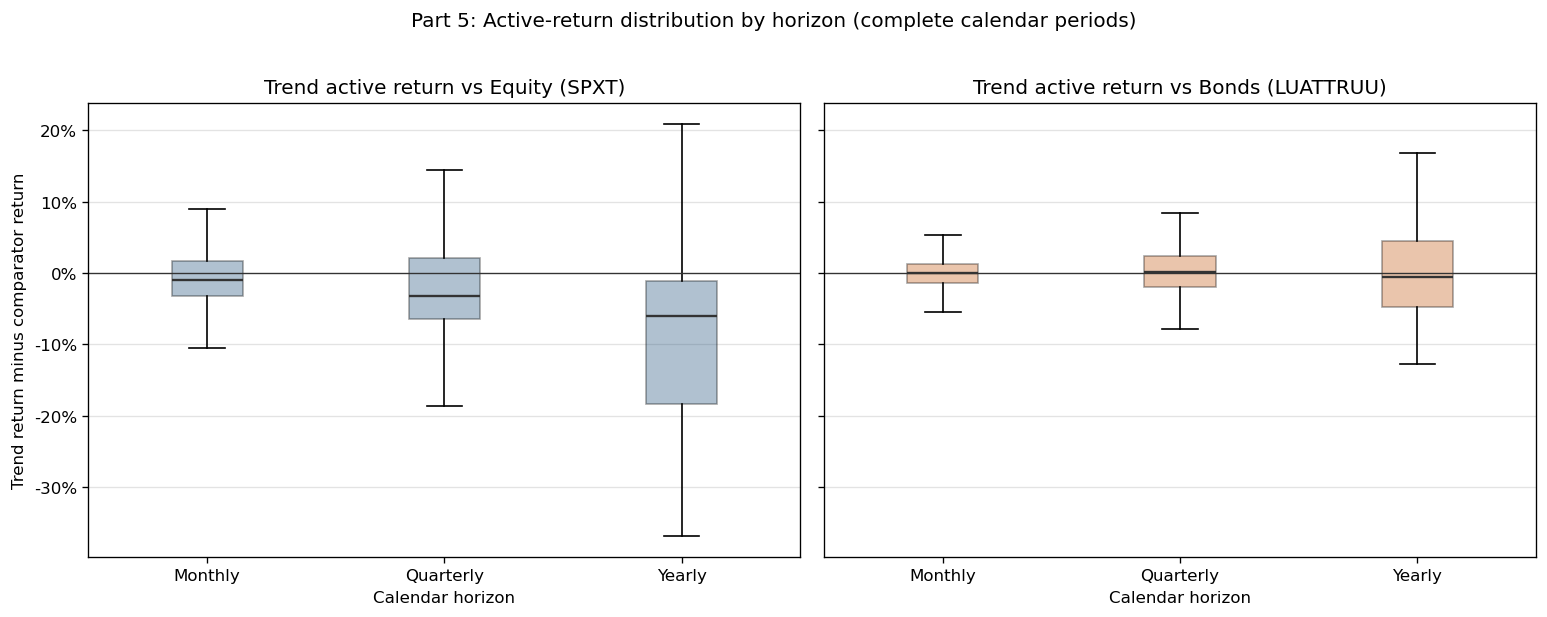

**Part 5 PM takeaway.** Trend should be evaluated as a diversifying sleeve, not as a permanent replacement for equity or duration beta. Against **equity**, trend's outright win rate is **38% / 34% / 21%** over month / quarter / year windows, with a **46%** risk-adjusted yearly win rate and median yearly active return of **-6.0%**. Against **bonds**, the same outright win rates are **51% / 52% / 46%**, with a **29%** risk-adjusted yearly win rate and median yearly active return of **-0.6%**. The conditional lens is the portfolio-management lens: trend's strongest equity-side hit rate occurs in **quarter** periods when equity is negative (**92%**, n=26, requiring at least five observations); its strongest bond-side hit rate occurs in **month** periods when bonds are negative (**73%**, n=129). When both sleeves are negative, trend beats equity most often at the **quarter** horizon (**82%**, n=11, also subject to the five-observation filter). Read the monthly Sharpe comparison as directional only; quarterly and yearly windows carry more PM signal. Supporting CSVs: `part5_calendar_horizon_outperformance.csv`, `part5_conditional_outperformance.csv`.

In [23]:
# Part 5.2 — PM-readable tables, active-return distributions, and takeaway
from IPython.display import Markdown, display

HORIZON_LABELS = {"month": "Monthly", "quarter": "Quarterly", "year": "Yearly"}
COMPARATOR_LABELS = {"equity": "vs Equity (SPXT)", "bond": "vs Bonds (LUATTRUU)"}
CONDITION_LABELS = {
    "equity_return < 0": "Equity negative",
    "bond_return < 0": "Bonds negative",
    "equity_return < 0 and bond_return < 0": "Both negative",
}

PRESENTATION_COLS = [
    "Outright win rate",
    "Risk-adjusted win rate",
    "Median active return",
    "Average active return",
    "Average win",
    "Average loss",
    "Payoff ratio",
    "Sharpe spread, median",
    "Periods",
    "RA periods",
]
PCT_DISPLAY_COLS = [
    "Outright win rate",
    "Risk-adjusted win rate",
    "Median active return",
    "Average active return",
    "Average win",
    "Average loss",
]
NUM_DISPLAY_COLS = ["Payoff ratio", "Sharpe spread, median"]
COUNT_DISPLAY_COLS = ["Periods", "RA periods"]


def presentation_summary_table(summary: pd.DataFrame) -> pd.DataFrame:
    out = summary.rename(
        columns={
            "n_windows": "Periods",
            "risk_adjusted_n_windows": "RA periods",
            "outright_win_rate": "Outright win rate",
            "risk_adjusted_win_rate": "Risk-adjusted win rate",
            "median_active_return": "Median active return",
            "average_active_return": "Average active return",
            "average_win": "Average win",
            "average_loss": "Average loss",
            "payoff_ratio_avg_win_abs_loss": "Payoff ratio",
            "median_sharpe_spread": "Sharpe spread, median",
        }
    ).copy()
    out["Horizon"] = out["horizon"].map(HORIZON_LABELS)
    out["Comparator"] = out["comparator"].map(COMPARATOR_LABELS)
    out["Horizon"] = pd.Categorical(out["Horizon"], ["Monthly", "Quarterly", "Yearly"], ordered=True)
    return out.sort_values(["Horizon", "Comparator"]).set_index(["Horizon", "Comparator"])[PRESENTATION_COLS]


def style_presentation_table(df: pd.DataFrame, caption: str):
    pct_cols = [c for c in PCT_DISPLAY_COLS if c in df.columns]
    num_cols = [c for c in NUM_DISPLAY_COLS if c in df.columns]
    count_cols = [c for c in COUNT_DISPLAY_COLS if c in df.columns]
    win_cols = [c for c in ["Outright win rate", "Risk-adjusted win rate", "Outright win", "Risk-adjusted win"] if c in df.columns]
    active_cols = [c for c in ["Median active return", "Average active return", "Median active"] if c in df.columns]

    fmt = {c: "{:.1%}" for c in pct_cols + ["Outright win", "Risk-adjusted win", "Median active"] if c in df.columns}
    fmt.update({c: "{:.2f}" for c in num_cols})
    fmt.update({c: "{:,.0f}" for c in count_cols})

    styler = (
        df.style
        .format(fmt, na_rep="—")
        .set_caption(caption)
        .set_table_styles(
            [
                {"selector": "caption", "props": "caption-side: top; text-align: left; font-size: 16px; font-weight: 700; color: #1F4E79; padding-bottom: 8px;"},
                {"selector": "th", "props": "background-color: #F2F4F7; color: #1F2937; font-weight: 700; border-bottom: 1px solid #CBD5E1;"},
                {"selector": "td", "props": "border-bottom: 1px solid #E5E7EB; padding: 6px 8px;"},
            ]
        )
    )
    if win_cols:
        styler = styler.background_gradient(subset=win_cols, cmap="Blues")
    if active_cols:
        styler = styler.background_gradient(subset=active_cols, cmap="RdYlGn")
    return styler


headline = presentation_summary_table(part5_calendar_summary)

summary_cards = headline.reset_index()[["Horizon", "Comparator", "Outright win rate", "Risk-adjusted win rate", "Median active return", "Payoff ratio"]]
summary_cards = summary_cards.rename(
    columns={
        "Outright win rate": "Outright win",
        "Risk-adjusted win rate": "Risk-adjusted win",
        "Median active return": "Median active",
    }
)

display(
    style_presentation_table(
        summary_cards.set_index(["Horizon", "Comparator"]),
        "Part 5 headline: trend batting average and payoff by calendar horizon",
    )
)

display(
    style_presentation_table(
        headline,
        "Part 5 detail: non-overlapping calendar periods only",
    )
)

conditional_view = part5_conditional_summary.rename(
    columns={
        "n_windows": "Periods",
        "risk_adjusted_n_windows": "RA periods",
        "outright_win_rate": "Outright win rate",
        "risk_adjusted_win_rate": "Risk-adjusted win rate",
        "median_active_return": "Median active return",
        "average_active_return": "Average active return",
    }
).copy()
conditional_view["Horizon"] = conditional_view["horizon"].map(HORIZON_LABELS)
conditional_view["Comparator"] = conditional_view["comparator"].map(COMPARATOR_LABELS)
conditional_view["Stress condition"] = conditional_view["condition"].map(CONDITION_LABELS)
conditional_view["Horizon"] = pd.Categorical(conditional_view["Horizon"], ["Monthly", "Quarterly", "Yearly"], ordered=True)
conditional_view = conditional_view.sort_values(["Horizon", "Comparator", "Stress condition"]).set_index(
    ["Horizon", "Comparator", "Stress condition"]
)[
    [
        "Periods",
        "RA periods",
        "Outright win rate",
        "Risk-adjusted win rate",
        "Median active return",
        "Average active return",
    ]
]

display(
    style_presentation_table(
        conditional_view,
        "Part 5 stress lens: trend win rate when equity and/or bonds are negative",
    )
)

# Active-return distribution chart by horizon and comparator.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.patch.set_facecolor("white")
horizon_order = ["month", "quarter", "year"]
colors = {"equity": PART3_COLORS["TREND"], "bond": PART3_COLORS["BENCH"]}

for ax, comp in zip(axes, ["equity", "bond"]):
    plot_data = [
        part5_calendar_detail.loc[
            (part5_calendar_detail["horizon"] == h) & (part5_calendar_detail["comparator"] == comp),
            "active_return",
        ].dropna().values
        for h in horizon_order
    ]
    bp = ax.boxplot(plot_data, tick_labels=[HORIZON_LABELS[h] for h in horizon_order], patch_artist=True, showfliers=False)
    for patch in bp["boxes"]:
        patch.set_facecolor(colors[comp])
        patch.set_alpha(0.35)
    for median in bp["medians"]:
        median.set_color("#333333")
        median.set_linewidth(1.4)
    ax.axhline(0.0, color="#333333", linewidth=0.8)
    ax.set_title(f"Trend active return {COMPARATOR_LABELS[comp]}")
    ax.set_xlabel("Calendar horizon")
    ax.grid(True, axis="y", alpha=0.35)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

axes[0].set_ylabel("Trend return minus comparator return")
plt.suptitle("Part 5: Active-return distribution by horizon (complete calendar periods)", y=1.02)
plt.tight_layout()
plt.show()


def _get_stat(summary: pd.DataFrame, horizon: str, comparator: str, col: str) -> float:
    row = summary[(summary["horizon"] == horizon) & (summary["comparator"] == comparator)]
    return float(row.iloc[0][col]) if len(row) else float("nan")


def _fmt_pct(x: float) -> str:
    return "—" if pd.isna(x) else f"{x:.0%}"


def _fmt_bp(x: float) -> str:
    return "—" if pd.isna(x) else f"{x:.1%}"


def _best_conditional(condition: str, comparator: str, min_windows: int = 5) -> tuple[str, float, int]:
    sub = part5_conditional_summary[
        (part5_conditional_summary["condition"] == condition)
        & (part5_conditional_summary["comparator"] == comparator)
    ].copy()
    sub = sub[sub["n_windows"] >= min_windows]
    if sub.empty:
        return "—", np.nan, 0
    idx = sub["outright_win_rate"].idxmax()
    row = sub.loc[idx]
    return str(row["horizon"]), float(row["outright_win_rate"]), int(row["n_windows"])


m_eq = _get_stat(part5_calendar_summary, "month", "equity", "outright_win_rate")
q_eq = _get_stat(part5_calendar_summary, "quarter", "equity", "outright_win_rate")
y_eq = _get_stat(part5_calendar_summary, "year", "equity", "outright_win_rate")
y_eq_ra = _get_stat(part5_calendar_summary, "year", "equity", "risk_adjusted_win_rate")
y_eq_med = _get_stat(part5_calendar_summary, "year", "equity", "median_active_return")

m_bd = _get_stat(part5_calendar_summary, "month", "bond", "outright_win_rate")
q_bd = _get_stat(part5_calendar_summary, "quarter", "bond", "outright_win_rate")
y_bd = _get_stat(part5_calendar_summary, "year", "bond", "outright_win_rate")
y_bd_ra = _get_stat(part5_calendar_summary, "year", "bond", "risk_adjusted_win_rate")
y_bd_med = _get_stat(part5_calendar_summary, "year", "bond", "median_active_return")

best_eq_h, best_eq_wr, best_eq_n = _best_conditional("equity_return < 0", "equity")
best_bd_h, best_bd_wr, best_bd_n = _best_conditional("bond_return < 0", "bond")
best_dual_h, best_dual_wr, best_dual_n = _best_conditional("equity_return < 0 and bond_return < 0", "equity")

pm_takeaway = (
    f"**Part 5 summary.** Outright win rate vs equity over month / quarter / year: "
    f"{_fmt_pct(m_eq)} / {_fmt_pct(q_eq)} / {_fmt_pct(y_eq)}. "
    f"Yearly risk-adjusted win rate {_fmt_pct(y_eq_ra)}, median yearly active return {_fmt_bp(y_eq_med)}. "
    f"Vs bonds: {_fmt_pct(m_bd)} / {_fmt_pct(q_bd)} / {_fmt_pct(y_bd)}; "
    f"yearly risk-adjusted {_fmt_pct(y_bd_ra)}, median yearly active {_fmt_bp(y_bd_med)}. "
    f"Conditional hit rates (min 5 obs): strongest vs equity at the {best_eq_h} horizon in equity-down periods "
    f"({_fmt_pct(best_eq_wr)}, n={best_eq_n}); strongest vs bonds at the {best_bd_h} horizon in bond-down periods "
    f"({_fmt_pct(best_bd_wr)}, n={best_bd_n}); strongest vs equity when both are negative at the {best_dual_h} horizon "
    f"({_fmt_pct(best_dual_wr)}, n={best_dual_n}). Monthly Sharpe is noisy; read quarterly and yearly first. "
    "CSVs: `part5_calendar_horizon_outperformance.csv`, `part5_conditional_outperformance.csv`."
)

display(Markdown(pm_takeaway))


## Part 6 — Trend vs 60/40 when stocks and bonds are positively correlated

When equities and bonds move together, does Method 1 improve the outcome versus 60/40? The comparison is 100% trend vs 100% 60/40, using stock and bond returns only to define the regime. Metrics are compounded return, realized Sharpe, and max drawdown over complete calendar months, quarters, and years. Positive stock-bond correlation is not by itself a stress regime; it matters most when the usual diversification benefit is impaired and 60/40 is flat or losing money.

In [24]:
# Part 6.1 — Build stock-bond correlation regimes and trend-vs-60/40 metrics

part6 = merged[["method1_strategy_return", "benchmark_strategy_return", "spxt_return", "luattruu_return"]].copy()
part6 = part6.rename(
    columns={
        "method1_strategy_return": "trend",
        "benchmark_strategy_return": "bench60_40",
        "spxt_return": "equity",
        "luattruu_return": "bond",
    }
).dropna(subset=["trend", "bench60_40", "equity", "bond"])

# Drop the leading seed row used to align NAV series, consistent with Parts 3-5.
if len(part6) > 0 and part6.iloc[0][["trend", "bench60_40", "equity", "bond"]].abs().sum() == 0:
    part6 = part6.iloc[1:].copy()

ROLL_QTR = 63
ROLL_YEAR = 252
part6["eq_bond_corr_63d"] = part6["equity"].rolling(ROLL_QTR, min_periods=ROLL_QTR // 2).corr(part6["bond"])
part6["eq_bond_corr_252d"] = part6["equity"].rolling(ROLL_YEAR, min_periods=ROLL_YEAR // 2).corr(part6["bond"])


def window_max_drawdown(x: pd.Series) -> float:
    s = x.dropna()
    if s.empty:
        return float("nan")
    nav = (1.0 + s).cumprod()
    dd = nav / nav.cummax() - 1.0
    return float(dd.min())


def window_vol(x: pd.Series) -> float:
    s = x.dropna()
    if len(s) < 2:
        return float("nan")
    return float(s.std() * np.sqrt(TRADING_DAYS))


def part6_calendar_window_panel(data: pd.DataFrame, freq: str, period_freq: str, label: str) -> pd.DataFrame:
    rows = []
    last_period = data.index.max().to_period(period_freq)
    for period_end, g in data.resample(freq):
        if g.empty:
            continue
        group_period = g.index.max().to_period(period_freq)
        is_complete = bool(group_period < last_period)
        eq_bond_corr = float(g["equity"].corr(g["bond"])) if len(g) >= 2 else float("nan")
        trend_return = compound_return(g["trend"])
        bench_return = compound_return(g["bench60_40"])
        trend_sharpe = window_sharpe(g["trend"])
        bench_sharpe = window_sharpe(g["bench60_40"])
        trend_max_dd = window_max_drawdown(g["trend"])
        bench_max_dd = window_max_drawdown(g["bench60_40"])
        rows.append(
            {
                "horizon": label,
                "period_end": period_end,
                "start_date": g.index.min(),
                "end_date": g.index.max(),
                "n_days": int(len(g)),
                "is_complete_period": is_complete,
                "eq_bond_corr": eq_bond_corr,
                "positive_stock_bond_corr": bool(eq_bond_corr > 0) if pd.notna(eq_bond_corr) else False,
                "trend_return": trend_return,
                "bench60_40_return": bench_return,
                "active_return_t_minus_6040": trend_return - bench_return,
                "trend_vol": window_vol(g["trend"]),
                "bench60_40_vol": window_vol(g["bench60_40"]),
                "trend_sharpe": trend_sharpe,
                "bench60_40_sharpe": bench_sharpe,
                "sharpe_spread_t_minus_6040": trend_sharpe - bench_sharpe if pd.notna(trend_sharpe) and pd.notna(bench_sharpe) else float("nan"),
                "trend_max_dd": trend_max_dd,
                "bench60_40_max_dd": bench_max_dd,
                "drawdown_advantage_t_minus_6040": trend_max_dd - bench_max_dd if pd.notna(trend_max_dd) and pd.notna(bench_max_dd) else float("nan"),
                "equity_return": compound_return(g["equity"]),
                "bond_return": compound_return(g["bond"]),
            }
        )
    return pd.DataFrame(rows)


part6_calendar_specs = [("ME", "M", "month"), ("QE", "Q", "quarter"), ("YE", "Y", "year")]
part6_windows = pd.concat(
    [part6_calendar_window_panel(part6, freq, period_freq, label) for freq, period_freq, label in part6_calendar_specs],
    ignore_index=True,
)
part6_complete = part6_windows[part6_windows["is_complete_period"]].copy()
part6_complete["corr_regime"] = np.where(
    part6_complete["positive_stock_bond_corr"],
    "Positive stock-bond corr",
    "Non-positive stock-bond corr",
)


def _safe_mean(x: pd.Series) -> float:
    s = x.dropna()
    return float(s.mean()) if len(s) else float("nan")


def _safe_median(x: pd.Series) -> float:
    s = x.dropna()
    return float(s.median()) if len(s) else float("nan")


def _safe_min(x: pd.Series) -> float:
    s = x.dropna()
    return float(s.min()) if len(s) else float("nan")


def summarize_part6_regime(df: pd.DataFrame, horizon: str, regime_label: str, condition_label: str) -> dict:
    n = int(len(df))
    return {
        "horizon": horizon,
        "regime": regime_label,
        "condition": condition_label,
        "n_windows": n,
        "avg_eq_bond_corr": _safe_mean(df["eq_bond_corr"]),
        "median_eq_bond_corr": _safe_median(df["eq_bond_corr"]),
        "avg_equity_return": _safe_mean(df["equity_return"]),
        "avg_bond_return": _safe_mean(df["bond_return"]),
        "avg_trend_return": _safe_mean(df["trend_return"]),
        "avg_60_40_return": _safe_mean(df["bench60_40_return"]),
        "median_trend_return": _safe_median(df["trend_return"]),
        "median_60_40_return": _safe_median(df["bench60_40_return"]),
        "trend_win_rate_vs_60_40": float((df["active_return_t_minus_6040"] > 0).mean()) if n else float("nan"),
        "avg_active_return_t_minus_6040": _safe_mean(df["active_return_t_minus_6040"]),
        "median_active_return_t_minus_6040": _safe_median(df["active_return_t_minus_6040"]),
        "avg_trend_vol": _safe_mean(df["trend_vol"]),
        "avg_60_40_vol": _safe_mean(df["bench60_40_vol"]),
        "avg_trend_sharpe": _safe_mean(df["trend_sharpe"]),
        "avg_60_40_sharpe": _safe_mean(df["bench60_40_sharpe"]),
        "avg_sharpe_spread_t_minus_6040": _safe_mean(df["sharpe_spread_t_minus_6040"]),
        "avg_trend_max_dd": _safe_mean(df["trend_max_dd"]),
        "avg_60_40_max_dd": _safe_mean(df["bench60_40_max_dd"]),
        "worst_trend_max_dd": _safe_min(df["trend_max_dd"]),
        "worst_60_40_max_dd": _safe_min(df["bench60_40_max_dd"]),
        "avg_drawdown_advantage_t_minus_6040": _safe_mean(df["drawdown_advantage_t_minus_6040"]),
        "worst_drawdown_advantage_t_minus_6040": _safe_min(df["drawdown_advantage_t_minus_6040"]),
    }


regime_count_rows = []
conditional_rows = []
stress_rows = []

stress_conditions = {
    "positive corr and 60/40_return < 0": lambda x: x["positive_stock_bond_corr"] & (x["bench60_40_return"] < 0),
    "positive corr and equity_return < 0": lambda x: x["positive_stock_bond_corr"] & (x["equity_return"] < 0),
    "positive corr and bond_return < 0": lambda x: x["positive_stock_bond_corr"] & (x["bond_return"] < 0),
    "positive corr and equity_return < 0 and bond_return < 0": lambda x: x["positive_stock_bond_corr"] & (x["equity_return"] < 0) & (x["bond_return"] < 0),
}

for horizon in ["month", "quarter", "year"]:
    hdf = part6_complete[part6_complete["horizon"] == horizon].copy()
    n_total = int(len(hdf))
    n_pos = int(hdf["positive_stock_bond_corr"].sum())
    regime_count_rows.append(
        {
            "horizon": horizon,
            "n_windows": n_total,
            "positive_corr_windows": n_pos,
            "positive_corr_share": n_pos / n_total if n_total else float("nan"),
            "avg_eq_bond_corr_all": _safe_mean(hdf["eq_bond_corr"]),
            "avg_eq_bond_corr_positive": _safe_mean(hdf.loc[hdf["positive_stock_bond_corr"], "eq_bond_corr"]),
            "avg_eq_bond_corr_non_positive": _safe_mean(hdf.loc[~hdf["positive_stock_bond_corr"], "eq_bond_corr"]),
            "avg_equity_return_positive_corr": _safe_mean(hdf.loc[hdf["positive_stock_bond_corr"], "equity_return"]),
            "avg_bond_return_positive_corr": _safe_mean(hdf.loc[hdf["positive_stock_bond_corr"], "bond_return"]),
        }
    )

    for is_pos, label in [(True, "Positive stock-bond corr"), (False, "Non-positive stock-bond corr")]:
        sub = hdf[hdf["positive_stock_bond_corr"] == is_pos]
        conditional_rows.append(summarize_part6_regime(sub, horizon, label, "eq_bond_corr > 0" if is_pos else "eq_bond_corr <= 0"))

    for condition_label, condition_func in stress_conditions.items():
        sub = hdf[condition_func(hdf)]
        stress_rows.append(summarize_part6_regime(sub, horizon, "Positive stock-bond corr stress", condition_label))

part6_regime_counts = pd.DataFrame(regime_count_rows)
part6_conditional_performance = pd.DataFrame(conditional_rows)
part6_stress_lens = pd.DataFrame(stress_rows)

part6_counts_path = OUTPUT_DIR / "part6_stock_bond_corr_horizon_summary.csv"
part6_conditional_path = OUTPUT_DIR / "part6_positive_corr_conditional_performance.csv"
part6_stress_path = OUTPUT_DIR / "part6_positive_corr_stress_lens.csv"

part6_regime_counts.to_csv(part6_counts_path, index=False)
part6_conditional_performance.to_csv(part6_conditional_path, index=False)
part6_stress_lens.to_csv(part6_stress_path, index=False)

print("Part 6 input rows:", len(part6), "|", part6.index.min().strftime("%Y-%m-%d"), "→", part6.index.max().strftime("%Y-%m-%d"))
print("Calendar windows used:", len(part6_complete), "complete periods; dropped", len(part6_windows) - len(part6_complete), "partial trailing periods")
print("Saved", part6_counts_path)
print("Saved", part6_conditional_path)
print("Saved", part6_stress_path)

Part 6 input rows: 6339 | 2002-01-02 → 2026-04-20
Calendar windows used: 412 complete periods; dropped 3 partial trailing periods
Saved /Users/jimmyzheng0516/Desktop/Project Labs/LTCM_sp_2026/Notebooks/output/part6_stock_bond_corr_horizon_summary.csv
Saved /Users/jimmyzheng0516/Desktop/Project Labs/LTCM_sp_2026/Notebooks/output/part6_positive_corr_conditional_performance.csv
Saved /Users/jimmyzheng0516/Desktop/Project Labs/LTCM_sp_2026/Notebooks/output/part6_positive_corr_stress_lens.csv


,Periods,Positive-corr periods,Positive-corr share,"Avg corr, all","Avg corr, positive","Avg corr, non-positive","Avg equity return, positive corr","Avg bond return, positive corr"
Horizon,,,,,,,,
Monthly,291,72,24.7%,-0.25,0.26,-0.42,1.1%,-0.2%
Quarterly,97,20,20.6%,-0.26,0.18,-0.37,2.5%,-0.5%
Yearly,24,4,16.7%,-0.27,0.09,-0.34,12.2%,-1.2%


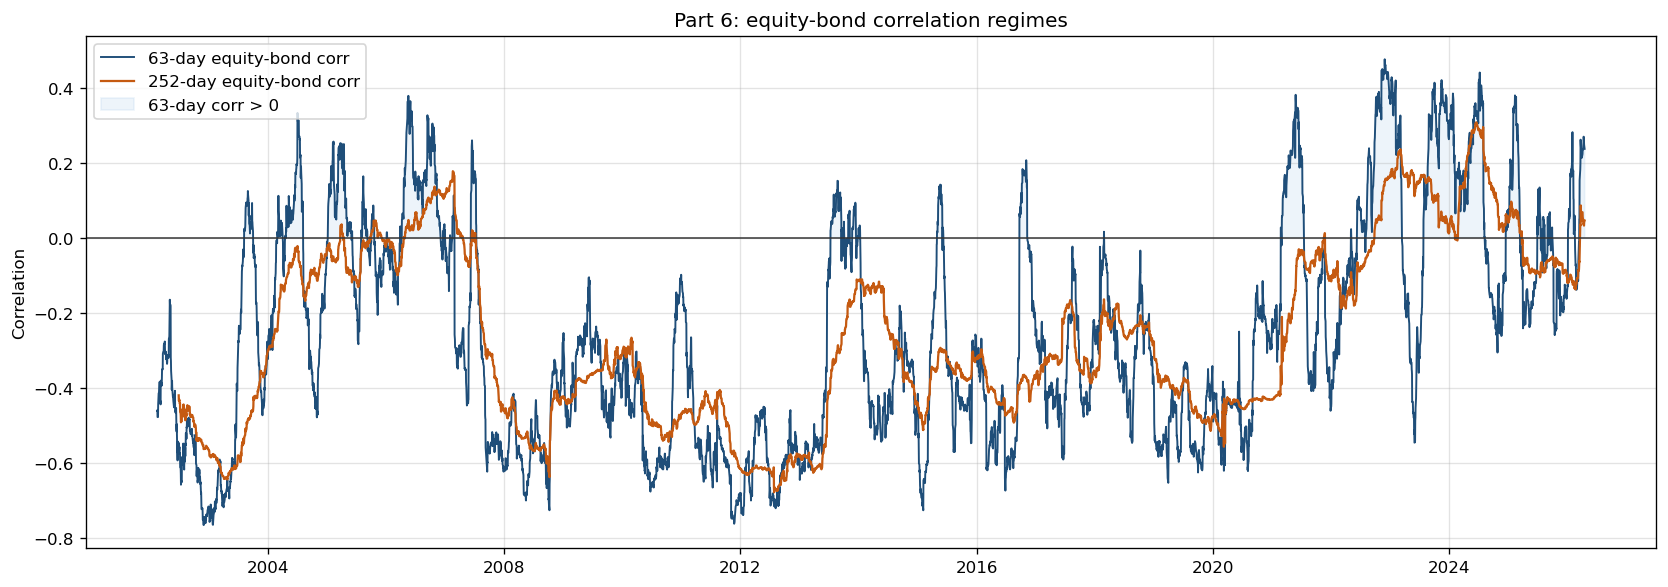

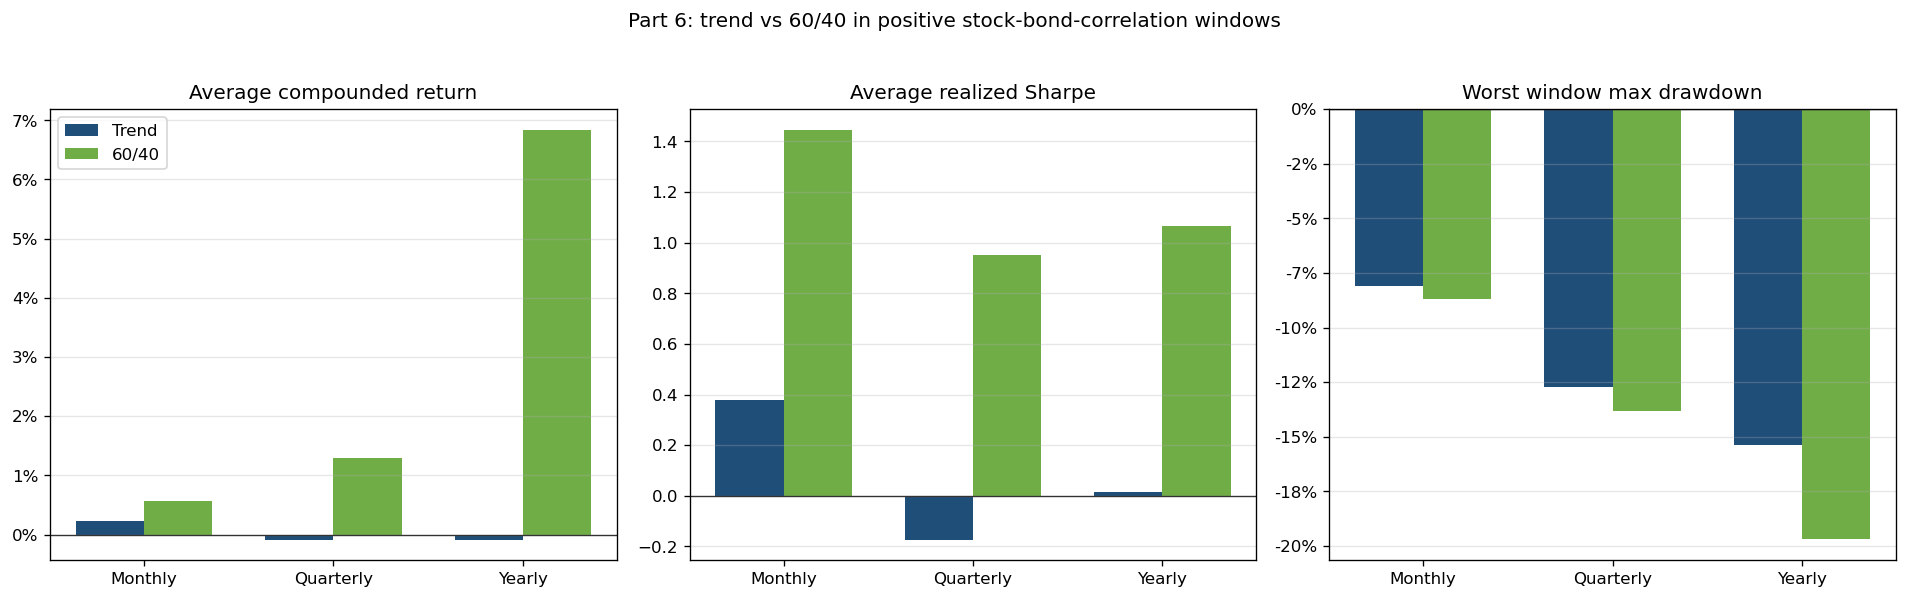

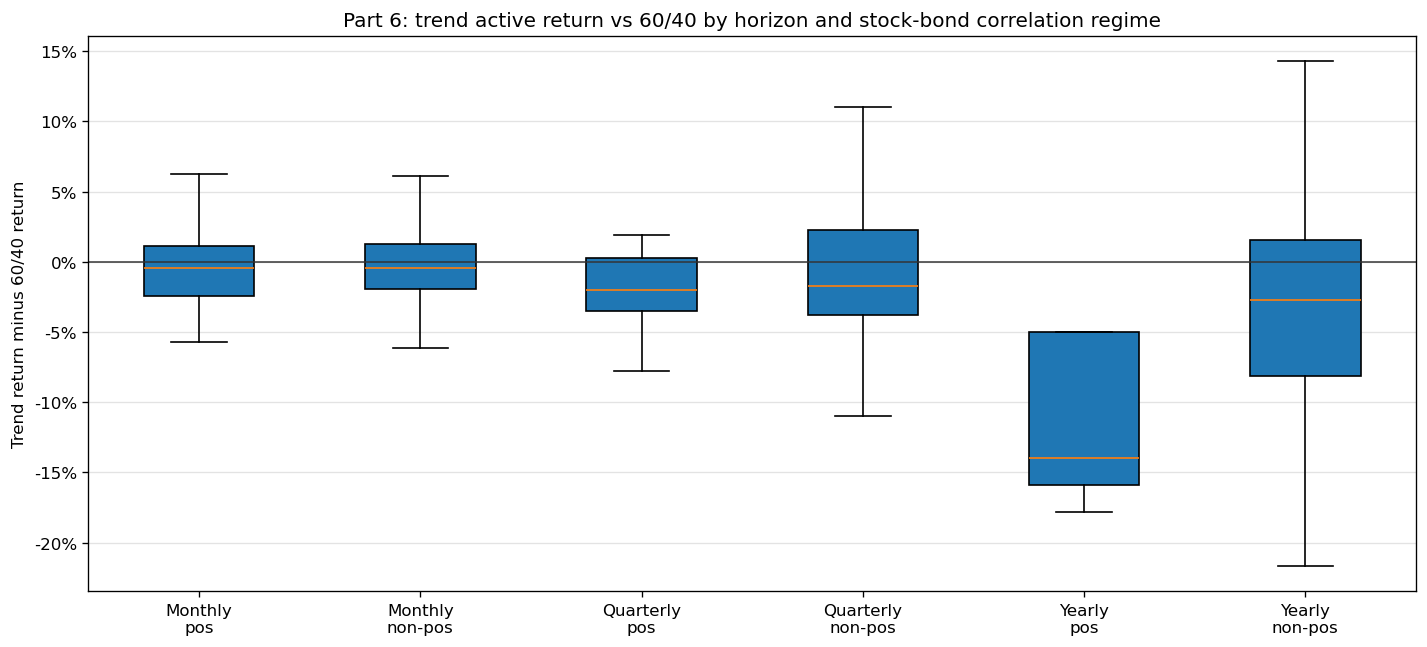

**Part 6 PM takeaway.** When stock-bond correlation is positive, the clean comparison is not whether trend beats equities or bonds individually, but whether it improves the outcome versus the combined **60/40** portfolio. At the **quarterly** horizon, positive-correlation windows total **20** periods; trend averages **-0.1%** versus **1.3%** for 60/40, with an average Sharpe spread of **-1.12** and an average max-DD advantage of **0.3%**. At the **yearly** horizon, positive-correlation windows total **4** periods; trend averages **-0.1%** versus **6.8%** for 60/40, with worst yearly max drawdowns of **-15.4%** for trend versus **-19.7%** for 60/40. The more important stress lens is positive correlation **and** a losing 60/40 period: in those quarterly windows, trend's average active return is **2.0%** with a **71%** win rate versus 60/40 (n=7); in yearly stress windows, average active return is **18.1%** (n=1). Read the monthly statistics as noisy because one-month correlations are unstable; the quarter and year rows carry the stronger PM signal. Supporting CSVs: `part6_stock_bond_corr_horizon_summary.csv`, `part6_positive_corr_conditional_performance.csv`, `part6_positive_corr_stress_lens.csv`.

In [25]:
# Part 6.2 — PM-readable tables, charts, and takeaway

from IPython.display import Markdown, display

HORIZON_LABELS_P6 = {"month": "Monthly", "quarter": "Quarterly", "year": "Yearly"}
REGIME_ORDER_P6 = ["Positive stock-bond corr", "Non-positive stock-bond corr"]


def _fmt_pct_p6(x, digits: int = 1) -> str:
    return "—" if pd.isna(x) else f"{x:.{digits}%}"


def _fmt_num_p6(x, digits: int = 2) -> str:
    return "—" if pd.isna(x) else f"{x:.{digits}f}"


def style_part6_table(df: pd.DataFrame, caption: str, pct_cols: list[str] | None = None, num_cols: list[str] | None = None, count_cols: list[str] | None = None):
    pct_cols = [c for c in (pct_cols or []) if c in df.columns]
    num_cols = [c for c in (num_cols or []) if c in df.columns]
    count_cols = [c for c in (count_cols or []) if c in df.columns]
    fmt = {c: "{:.1%}" for c in pct_cols}
    fmt.update({c: "{:.2f}" for c in num_cols})
    fmt.update({c: "{:,.0f}" for c in count_cols})
    return (
        df.style
        .format(fmt, na_rep="—")
        .set_caption(caption)
        .set_table_styles(
            [
                {"selector": "caption", "props": "caption-side: top; text-align: left; font-size: 16px; font-weight: 700; color: #1F4E79; padding-bottom: 8px;"},
                {"selector": "th", "props": "background-color: #D9EAF7; color: #1F1F1F; font-weight: 700;"},
                {"selector": "td", "props": "padding: 6px 8px;"},
            ]
        )
    )


counts_view = part6_regime_counts.rename(
    columns={
        "horizon": "Horizon",
        "n_windows": "Periods",
        "positive_corr_windows": "Positive-corr periods",
        "positive_corr_share": "Positive-corr share",
        "avg_eq_bond_corr_all": "Avg corr, all",
        "avg_eq_bond_corr_positive": "Avg corr, positive",
        "avg_eq_bond_corr_non_positive": "Avg corr, non-positive",
        "avg_equity_return_positive_corr": "Avg equity return, positive corr",
        "avg_bond_return_positive_corr": "Avg bond return, positive corr",
    }
).copy()
counts_view["Horizon"] = counts_view["Horizon"].map(HORIZON_LABELS_P6)
counts_view = counts_view.set_index("Horizon")

display(
    style_part6_table(
        counts_view,
        "Part 6 regime map: how often stocks and bonds are positively correlated",
        pct_cols=["Positive-corr share", "Avg equity return, positive corr", "Avg bond return, positive corr"],
        num_cols=["Avg corr, all", "Avg corr, positive", "Avg corr, non-positive"],
        count_cols=["Periods", "Positive-corr periods"],
    )
)

core_cols = [
    "horizon", "regime", "n_windows", "avg_eq_bond_corr",
    "avg_trend_return", "avg_60_40_return", "trend_win_rate_vs_60_40",
    "avg_active_return_t_minus_6040", "avg_trend_sharpe", "avg_60_40_sharpe",
    "avg_sharpe_spread_t_minus_6040", "avg_trend_max_dd", "avg_60_40_max_dd",
    "worst_trend_max_dd", "worst_60_40_max_dd", "avg_drawdown_advantage_t_minus_6040",
]

conditional_view = part6_conditional_performance[core_cols].rename(
    columns={
        "horizon": "Horizon",
        "regime": "Regime",
        "n_windows": "Periods",
        "avg_eq_bond_corr": "Avg corr",
        "avg_trend_return": "Avg trend return",
        "avg_60_40_return": "Avg 60/40 return",
        "trend_win_rate_vs_60_40": "Trend win rate vs 60/40",
        "avg_active_return_t_minus_6040": "Avg active return",
        "avg_trend_sharpe": "Avg trend Sharpe",
        "avg_60_40_sharpe": "Avg 60/40 Sharpe",
        "avg_sharpe_spread_t_minus_6040": "Avg Sharpe spread",
        "avg_trend_max_dd": "Avg trend max DD",
        "avg_60_40_max_dd": "Avg 60/40 max DD",
        "worst_trend_max_dd": "Worst trend max DD",
        "worst_60_40_max_dd": "Worst 60/40 max DD",
        "avg_drawdown_advantage_t_minus_6040": "Avg DD advantage",
    }
).copy()
conditional_view["Horizon"] = conditional_view["Horizon"].map(HORIZON_LABELS_P6)
conditional_view["Horizon"] = pd.Categorical(conditional_view["Horizon"], ["Monthly", "Quarterly", "Yearly"], ordered=True)
conditional_view["Regime"] = pd.Categorical(conditional_view["Regime"], REGIME_ORDER_P6, ordered=True)
conditional_view = conditional_view.sort_values(["Horizon", "Regime"]).set_index(["Horizon", "Regime"])

display(
    style_part6_table(
        conditional_view,
        "Part 6 core comparison: trend vs 60/40 by stock-bond correlation regime",
        pct_cols=[
            "Avg trend return", "Avg 60/40 return", "Trend win rate vs 60/40",
            "Avg active return", "Avg trend max DD", "Avg 60/40 max DD", "Worst trend max DD",
            "Worst 60/40 max DD", "Avg DD advantage",
        ],
        num_cols=["Avg corr", "Avg trend Sharpe", "Avg 60/40 Sharpe", "Avg Sharpe spread"],
        count_cols=["Periods"],
    )
)

stress_view = part6_stress_lens[core_cols + ["condition"]].rename(
    columns={
        "horizon": "Horizon",
        "condition": "Condition",
        "n_windows": "Periods",
        "avg_eq_bond_corr": "Avg corr",
        "avg_trend_return": "Avg trend return",
        "avg_60_40_return": "Avg 60/40 return",
        "trend_win_rate_vs_60_40": "Trend win rate vs 60/40",
        "avg_active_return_t_minus_6040": "Avg active return",
        "avg_trend_sharpe": "Avg trend Sharpe",
        "avg_60_40_sharpe": "Avg 60/40 Sharpe",
        "avg_sharpe_spread_t_minus_6040": "Avg Sharpe spread",
        "avg_trend_max_dd": "Avg trend max DD",
        "avg_60_40_max_dd": "Avg 60/40 max DD",
        "worst_trend_max_dd": "Worst trend max DD",
        "worst_60_40_max_dd": "Worst 60/40 max DD",
        "avg_drawdown_advantage_t_minus_6040": "Avg DD advantage",
    }
).copy()
stress_view["Horizon"] = stress_view["Horizon"].map(HORIZON_LABELS_P6)
stress_view["Horizon"] = pd.Categorical(stress_view["Horizon"], ["Monthly", "Quarterly", "Yearly"], ordered=True)
stress_view = stress_view.sort_values(["Horizon", "Condition"]).set_index(["Horizon", "Condition"])

display(
    style_part6_table(
        stress_view,
        "Part 6 stress lens: positive stock-bond correlation plus weak 60/40 or weak sleeves",
        pct_cols=[
            "Avg trend return", "Avg 60/40 return", "Trend win rate vs 60/40",
            "Avg active return", "Avg trend max DD", "Avg 60/40 max DD", "Worst trend max DD",
            "Worst 60/40 max DD", "Avg DD advantage",
        ],
        num_cols=["Avg corr", "Avg trend Sharpe", "Avg 60/40 Sharpe", "Avg Sharpe spread"],
        count_cols=["Periods"],
    )
)

# Rolling correlation chart: when the stock-bond diversification assumption was impaired.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(part6.index, part6["eq_bond_corr_63d"], color="#1F4E79", linewidth=1.15, label="63-day equity-bond corr")
ax.plot(part6.index, part6["eq_bond_corr_252d"], color="#C55A11", linewidth=1.35, label="252-day equity-bond corr")
ax.fill_between(
    part6.index,
    0,
    part6["eq_bond_corr_63d"].fillna(0),
    where=part6["eq_bond_corr_63d"].fillna(0) > 0,
    color="#9DC3E6",
    alpha=0.18,
    label="63-day corr > 0",
)
ax.axhline(0, color="#333333", linewidth=0.9)
ax.set_title("Part 6: equity-bond correlation regimes")
ax.set_ylabel("Correlation")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# Positive-correlation windows: compare trend vs 60/40 on the three requested PM metrics.
pos_perf = part6_conditional_performance[part6_conditional_performance["regime"] == "Positive stock-bond corr"].copy()
pos_perf["horizon_label"] = pos_perf["horizon"].map(HORIZON_LABELS_P6)
pos_perf["horizon_label"] = pd.Categorical(pos_perf["horizon_label"], ["Monthly", "Quarterly", "Yearly"], ordered=True)
pos_perf = pos_perf.sort_values("horizon_label")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
x = np.arange(len(pos_perf))
width = 0.36

axes[0].bar(x - width / 2, pos_perf["avg_trend_return"], width, label="Trend", color="#1F4E79")
axes[0].bar(x + width / 2, pos_perf["avg_60_40_return"], width, label="60/40", color="#70AD47")
axes[0].set_title("Average compounded return")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

axes[1].bar(x - width / 2, pos_perf["avg_trend_sharpe"], width, label="Trend", color="#1F4E79")
axes[1].bar(x + width / 2, pos_perf["avg_60_40_sharpe"], width, label="60/40", color="#70AD47")
axes[1].set_title("Average realized Sharpe")

axes[2].bar(x - width / 2, pos_perf["worst_trend_max_dd"], width, label="Trend", color="#1F4E79")
axes[2].bar(x + width / 2, pos_perf["worst_60_40_max_dd"], width, label="60/40", color="#70AD47")
axes[2].set_title("Worst window max drawdown")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(pos_perf["horizon_label"])
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.grid(True, axis="y", alpha=0.3)
axes[0].legend(loc="best")
plt.suptitle("Part 6: trend vs 60/40 in positive stock-bond-correlation windows", y=1.03)
plt.tight_layout()
plt.show()

# Active-return distribution by horizon and correlation regime.
fig, ax = plt.subplots(figsize=(12, 5.5))
box_data = []
box_labels = []
for horizon in ["month", "quarter", "year"]:
    for regime in REGIME_ORDER_P6:
        vals = part6_complete.loc[
            (part6_complete["horizon"] == horizon) & (part6_complete["corr_regime"] == regime),
            "active_return_t_minus_6040",
        ].dropna().values
        box_data.append(vals)
        box_labels.append(f"{HORIZON_LABELS_P6[horizon]}\n{'pos' if regime.startswith('Positive') else 'non-pos'}")
ax.boxplot(box_data, tick_labels=box_labels, showfliers=False, patch_artist=True)
ax.axhline(0, color="#333333", linewidth=0.9)
ax.set_title("Part 6: trend active return vs 60/40 by horizon and stock-bond correlation regime")
ax.set_ylabel("Trend return minus 60/40 return")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()


def _p6_row(df: pd.DataFrame, horizon: str, regime: str | None = None, condition: str | None = None) -> pd.Series:
    sub = df[df["horizon"] == horizon].copy()
    if regime is not None:
        sub = sub[sub["regime"] == regime]
    if condition is not None:
        sub = sub[sub["condition"] == condition]
    return sub.iloc[0] if len(sub) else pd.Series(dtype=float)


q_pos = _p6_row(part6_conditional_performance, "quarter", regime="Positive stock-bond corr")
y_pos = _p6_row(part6_conditional_performance, "year", regime="Positive stock-bond corr")
q_stress = _p6_row(part6_stress_lens, "quarter", condition="positive corr and 60/40_return < 0")
y_stress = _p6_row(part6_stress_lens, "year", condition="positive corr and 60/40_return < 0")

pm_takeaway_p6 = (
    f"**Part 6 summary.** Quarterly positive-correlation windows: {int(q_pos.get('n_windows', 0))} periods, "
    f"trend {_fmt_pct_p6(q_pos.get('avg_trend_return'))} vs 60/40 {_fmt_pct_p6(q_pos.get('avg_60_40_return'))}, "
    f"avg Sharpe spread {_fmt_num_p6(q_pos.get('avg_sharpe_spread_t_minus_6040'))}, "
    f"avg max-DD advantage {_fmt_pct_p6(q_pos.get('avg_drawdown_advantage_t_minus_6040'))}. "
    f"Yearly: {int(y_pos.get('n_windows', 0))} periods, trend {_fmt_pct_p6(y_pos.get('avg_trend_return'))} vs "
    f"60/40 {_fmt_pct_p6(y_pos.get('avg_60_40_return'))}, worst yearly max DD "
    f"{_fmt_pct_p6(y_pos.get('worst_trend_max_dd'))} (trend) vs {_fmt_pct_p6(y_pos.get('worst_60_40_max_dd'))} (60/40). "
    f"Positive corr AND 60/40-down: quarterly avg active "
    f"{_fmt_pct_p6(q_stress.get('avg_active_return_t_minus_6040'))} with win rate "
    f"{_fmt_pct_p6(q_stress.get('trend_win_rate_vs_60_40'), 0)} (n={int(q_stress.get('n_windows', 0))}); "
    f"yearly avg active {_fmt_pct_p6(y_stress.get('avg_active_return_t_minus_6040'))} "
    f"(n={int(y_stress.get('n_windows', 0))}). Monthly correlations are noisy; quarterly and yearly carry more signal. "
    "CSVs: `part6_stock_bond_corr_horizon_summary.csv`, `part6_positive_corr_conditional_performance.csv`, `part6_positive_corr_stress_lens.csv`."
)

display(Markdown(pm_takeaway_p6))